In [8]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns  
import glob

from collections import Counter

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG
from utils import label_mapping_utils as lmu
from utils import nebula_with_factors as deg_nebula

from statsmodels.stats.multitest import multipletests
import gseapy as gp
from gseapy import dotplot, barplot, gseaplot2
import shutil

import decoupler as dc

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline


TISSUE = "Striatum" # Striatum, DFC, SN
TYPE_DEG = "PCA_nebula" #PCA_nebula, baseline_nebula. cNMF_nebula gradient_score_nebula
RESULTS_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# How to define significant genes
ALPHA_MULTIPLE_TEST = 0.05
METHOD_MULTIPLE_TEST = "fdr_bh" # fdr_bh, bonferroni, holm, etc. see statsmodels.stats.multitest.multipletests
LOGFC_THR=0.5 #1e-30#0.5 #set your logFC threshold at or above the median SE
PVAL_THR=0.05
PVAL_COL=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
SE_COL=f"se_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL="gene"
COL_P_ADJ = f"adj_{PVAL_COL}"
N_TOP = 20

REMOVE_RIBO_GENES_FROM_GSEA = True  
REMOVE_GENE_TOO_HIGH_INTERCEPT = True # filter out genes with extreme negative intercept logFC, which are likely very lowly expressed in controls and their logFC is unreliable.

# GSEA parameters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Map: cell types that have zone analysis → their zone variable
# each cell type has  a better zonation level
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}
# adata stays untouched here — no more global mutation


# Read grad genes

In [3]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad["combined_p"] <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene", "combined_p"]].rename(columns={"combined_p": "p-value_gradient"})
df_grad

1241
1241


,mean_spearman,is_gradient_gene,p-value_gradient
gene,,,
A1BG,-0.002360,False,5.349057e-07
A1BG-AS1,-0.007881,False,3.198023e-08
A1CF,0.007398,False,2.969691e-02
A2M,-0.002144,False,8.049117e-15
A2M-AS1,-0.000389,False,7.443913e-03
...,...,...,...
ENSG00000277836,NaN,False,NaN
ENSG00000278633,NaN,False,NaN
ENSG00000276017,-0.008289,False,2.949804e-01


# Read Handsaker genes

In [4]:
phase_d = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_d_genes.csv")
phase_c_plus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_plus_genes.csv")
phase_c_minus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_minus_genes.csv")
phase_d
phase_c_minus

,Gene,Phase C p-value,Phase C effect,Phase C fold-change,Phase D p-value,Phase D effect,Pct cells,Phase,Highly expressed C+,Highly expressed C-,De-repressed phase D,Case-control p-value,Case-control fold-change
0,ABAT,2.010000e-13,-0.001111,0.846,1.510000e-01,0.070240,99.90,C-,N,Y,N,1.860000e-02,0.912
1,AC008591.1,8.580000e-12,-0.001579,0.789,2.400000e-02,-0.168123,98.08,C-,N,Y,N,1.200000e-08,0.478
2,AC069437.1,4.680000e-12,-0.001738,0.770,5.780000e-03,-0.221585,95.94,C-,N,Y,N,3.040000e-08,0.398
3,AC079385.1,2.180000e-16,-0.002295,0.709,3.980000e-03,-0.260246,97.20,C-,N,Y,N,2.300000e-06,0.738
4,AC090124.1,1.170000e-29,-0.005723,0.424,9.110000e-02,-0.258410,71.56,C-,N,N,N,1.010000e-09,0.561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,YPEL1,2.960000e-52,-0.002457,0.692,2.250000e-06,-0.239871,99.53,C-,N,Y,N,6.460000e-05,1.263
216,ZMAT4,1.890000e-19,-0.001203,0.835,2.020000e-10,-0.276307,99.96,C-,N,Y,N,9.860000e-01,1.028
217,ZNF83,3.040000e-37,-0.003241,0.615,9.290000e-01,-0.007202,98.47,C-,N,Y,N,4.520000e-02,1.141
218,ZNRF3,5.460000e-12,-0.001219,0.833,3.000000e-02,-0.124679,99.51,C-,N,Y,N,1.650000e-03,0.906


# Create list fof **Folders** to analyse

In [5]:
# Build list of all result folders: (folder_path, label)
# Covers both regular cell types and all zone CTs
_all_results = []

# 1. Regular cell types
for ct in sorted(os.listdir(RESULTS_FOLDER)):

    if ct == "summary":          # ← skip our own output folder
        continue

    d = os.path.join(RESULTS_FOLDER, ct)
    if not os.path.isdir(d) or "_by_" in ct:
        continue
    _all_results.append((d, ct))

# 2. Zone cell types (Striatum only)
if TISSUE == "Striatum":
    for zone_ct, zone_variable in ZONE_CT_MAP.items():
        zone_base = os.path.join(RESULTS_FOLDER, f"{zone_ct}_by_{zone_variable}")
        if not os.path.isdir(zone_base):
            continue
        for zone in sorted(os.listdir(zone_base)):
            d = os.path.join(zone_base, zone)
            if os.path.isdir(d):
                _all_results.append((d, f"{zone_ct}_by_{zone_variable}/{zone}"))

print(f"Found {len(_all_results)} result folders to process")
for d, lbl in _all_results:
    print(f"  {lbl}")

Found 51 result folders to process
  Astrocyte
  COP
  Endothelial_BBB
  Ependymal
  Fibroblasts
  Lymphocyte
  Macrophages
  Matrix
  Matrix_D1
  Matrix_D2
  Microglia
  Monocytes
  OPC
  Oligodendrocyte
  Patch
  Patch_D1
  Patch_D2
  Pericytes
  SmoothMuscleCells
  _summary
  eMSN_D1D2
  eMSN_NUDAP
  eMSN_StrioMat
  Matrix_D1_by_zone/1
  Matrix_D1_by_zone/2
  Matrix_D1_by_zone/3
  Matrix_D1_by_zone/4
  Matrix_D1_by_zone/5
  Matrix_D1_by_zone/6
  Matrix_D2_by_zone/1
  Matrix_D2_by_zone/2
  Matrix_D2_by_zone/3
  Matrix_D2_by_zone/4
  Matrix_D2_by_zone/5
  Matrix_D2_by_zone/6
  Patch_D1_by_zone_4/1
  Patch_D1_by_zone_4/2
  Patch_D1_by_zone_4/3
  Patch_D1_by_zone_4/4
  Patch_D2_by_zone_4/1
  Patch_D2_by_zone_4/2
  Patch_D2_by_zone_4/3
  Patch_D2_by_zone_4/4
  eMSN_D1D2_by_zone_4/1
  eMSN_D1D2_by_zone_4/2
  eMSN_D1D2_by_zone_4/3
  eMSN_D1D2_by_zone_4/4
  Astrocyte_by_zone_4/1
  Astrocyte_by_zone_4/2
  Astrocyte_by_zone_4/3
  Astrocyte_by_zone_4/4


In [6]:
_all_results = [ 
  ('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix', 'Matrix'),
  ('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch', 'Patch'),
  ]

# _all_results = [ 
#   ('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Matrix', 'Matrix'),
#   ('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Patch', 'Patch'),
#   ]

# Plot Vulcano plots

In [55]:
df_nebula

,logFC_(Intercept),logFC_conditionXDP,logFC_age_of_death,logFC_sexM,logFC_pct_counts_mt,logFC_frac_intronic,logFC_cohortCohort_2,logFC_cohortCohort_3,se_(Intercept),se_conditionXDP,...,p_conditionXDP,p_age_of_death,p_sexM,p_pct_counts_mt,p_frac_intronic,p_cohortCohort_2,p_cohortCohort_3,gene_id,gene,z_score
0,-13.282952,0.247957,-0.003595,-0.175334,-0.376185,1.672820,-0.323499,0.148111,0.059814,0.129921,...,0.185872,0.353547,0.253167,6.242140e-02,1.414124e-01,0.036233,3.043389e-01,1,ENSG00000238009,1.322889
1,-12.650756,-0.009774,-0.001892,-0.007691,-0.105069,0.976884,-0.015461,0.178657,0.037174,0.082537,...,0.934581,0.424906,0.933117,3.160268e-01,2.227250e-01,0.879152,7.127393e-02,2,ENSG00000241860,-0.082083
2,-13.133416,-0.037579,0.000363,0.041149,-0.192552,1.684737,0.057351,0.215506,0.048849,0.106821,...,0.807350,0.905170,0.731884,1.787424e-01,1.080900e-01,0.663761,9.381308e-02,3,ENSG00000290385,-0.243846
3,-11.217902,-0.025582,0.003038,-0.014982,0.095459,0.911510,-0.042191,0.122660,0.032378,0.074936,...,0.812945,0.190556,0.872887,1.617796e-02,3.249326e-02,0.607563,1.286679e-01,4,ENSG00000291215,-0.236629
4,-10.207559,0.202829,0.004772,-0.089599,0.228292,-0.133613,0.296741,0.323988,0.032880,0.074851,...,0.060345,0.042674,0.344726,1.070820e-18,7.075110e-01,0.000206,5.587271e-05,5,LINC01409,1.878268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16819,-11.914927,-0.148585,-0.006574,0.030441,-0.130420,0.863395,-0.314045,-0.000585,0.061441,0.143654,...,0.473409,0.162423,0.866409,1.048098e-01,1.392142e-01,0.033769,9.968293e-01,416,ENSG00000276256,-0.716943
16820,-11.557303,0.139220,-0.001430,-0.166372,0.062919,3.437772,-0.066506,-0.140343,0.091809,0.212563,...,0.649841,0.841579,0.524982,2.810052e-01,1.186671e-09,0.760266,5.150018e-01,417,ENSG00000278384,0.453983
16821,-9.656024,0.180174,0.006141,-0.269578,0.138069,1.710263,0.294939,0.320688,0.075509,0.167577,...,0.456119,0.253758,0.199543,1.016759e-07,1.748388e-08,0.101141,6.910583e-02,418,ENSG00000273748,0.745253
16822,-12.146874,0.082444,-0.002855,-0.078391,0.010133,0.972962,0.429493,0.549963,0.042165,0.095996,...,0.551647,0.321346,0.498858,8.817019e-01,1.379768e-01,0.000118,5.324237e-07,419,LOC124905564,0.595294



######################
 Matrix 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/deg_results.csv
  Removing 0 genes with extreme intercept logFC


2026-05-27 12:29:03 | [WARNING] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/home/gdallagl/myworkdir/XDP/utils/DEG.py:943: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


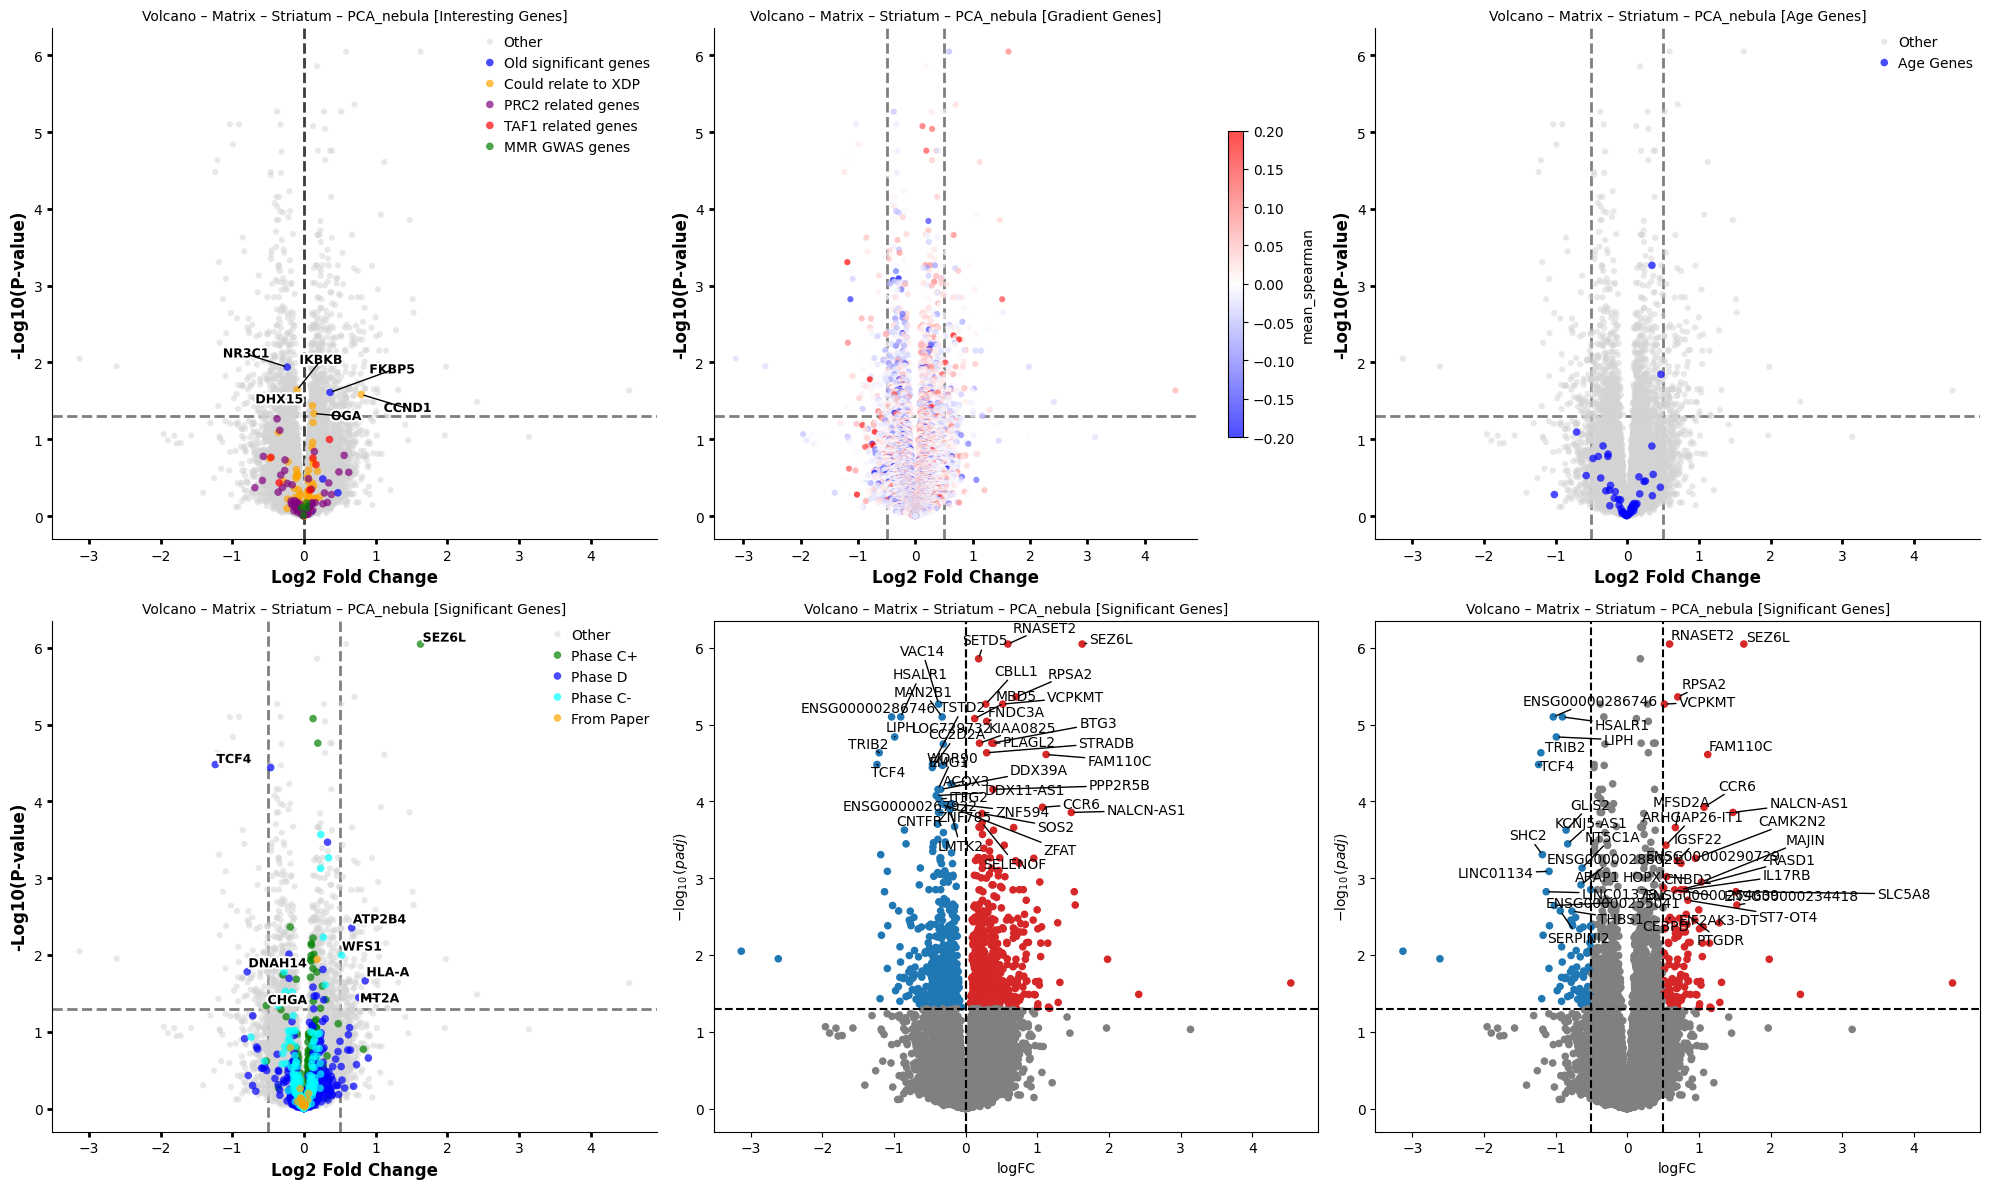

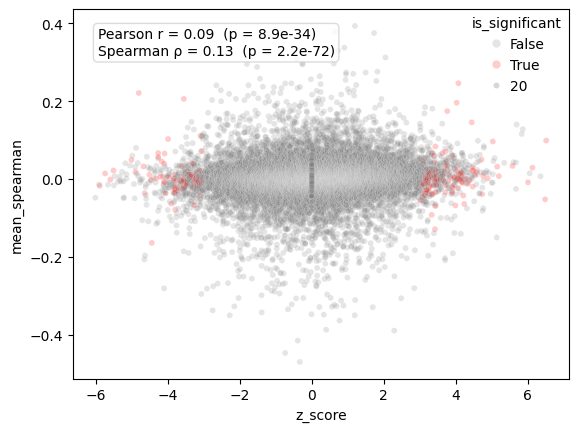

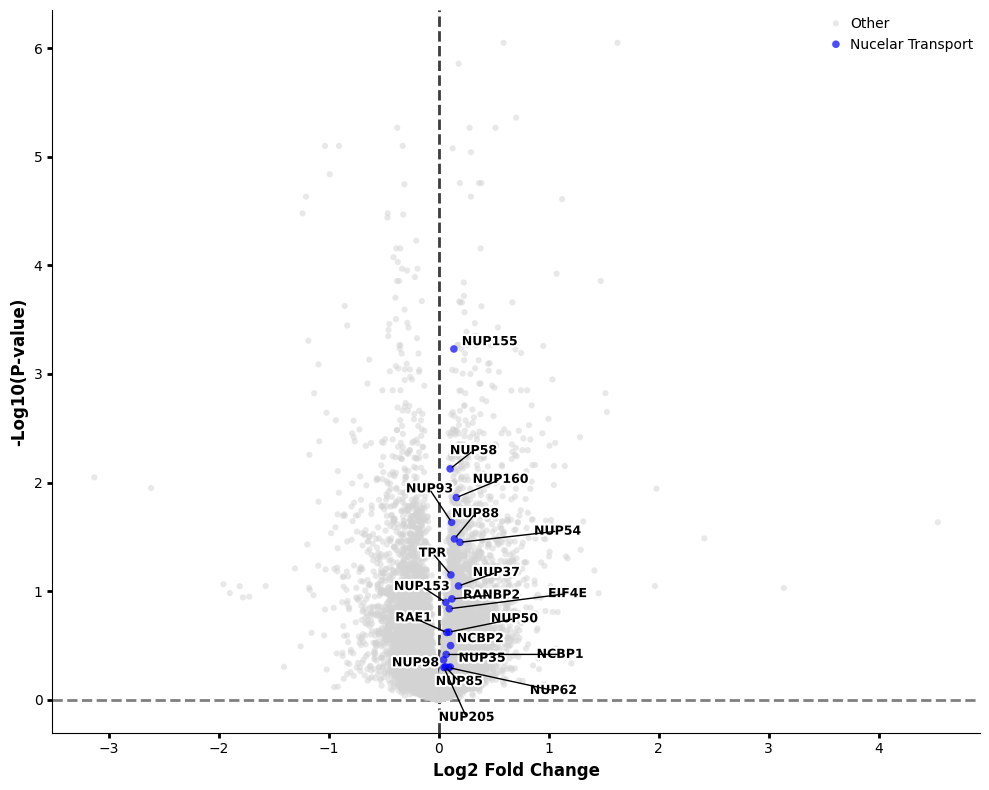


######################
 Patch 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch/deg_results.csv
  Removing 0 genes with extreme intercept logFC


/home/gdallagl/myworkdir/XDP/utils/DEG.py:943: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


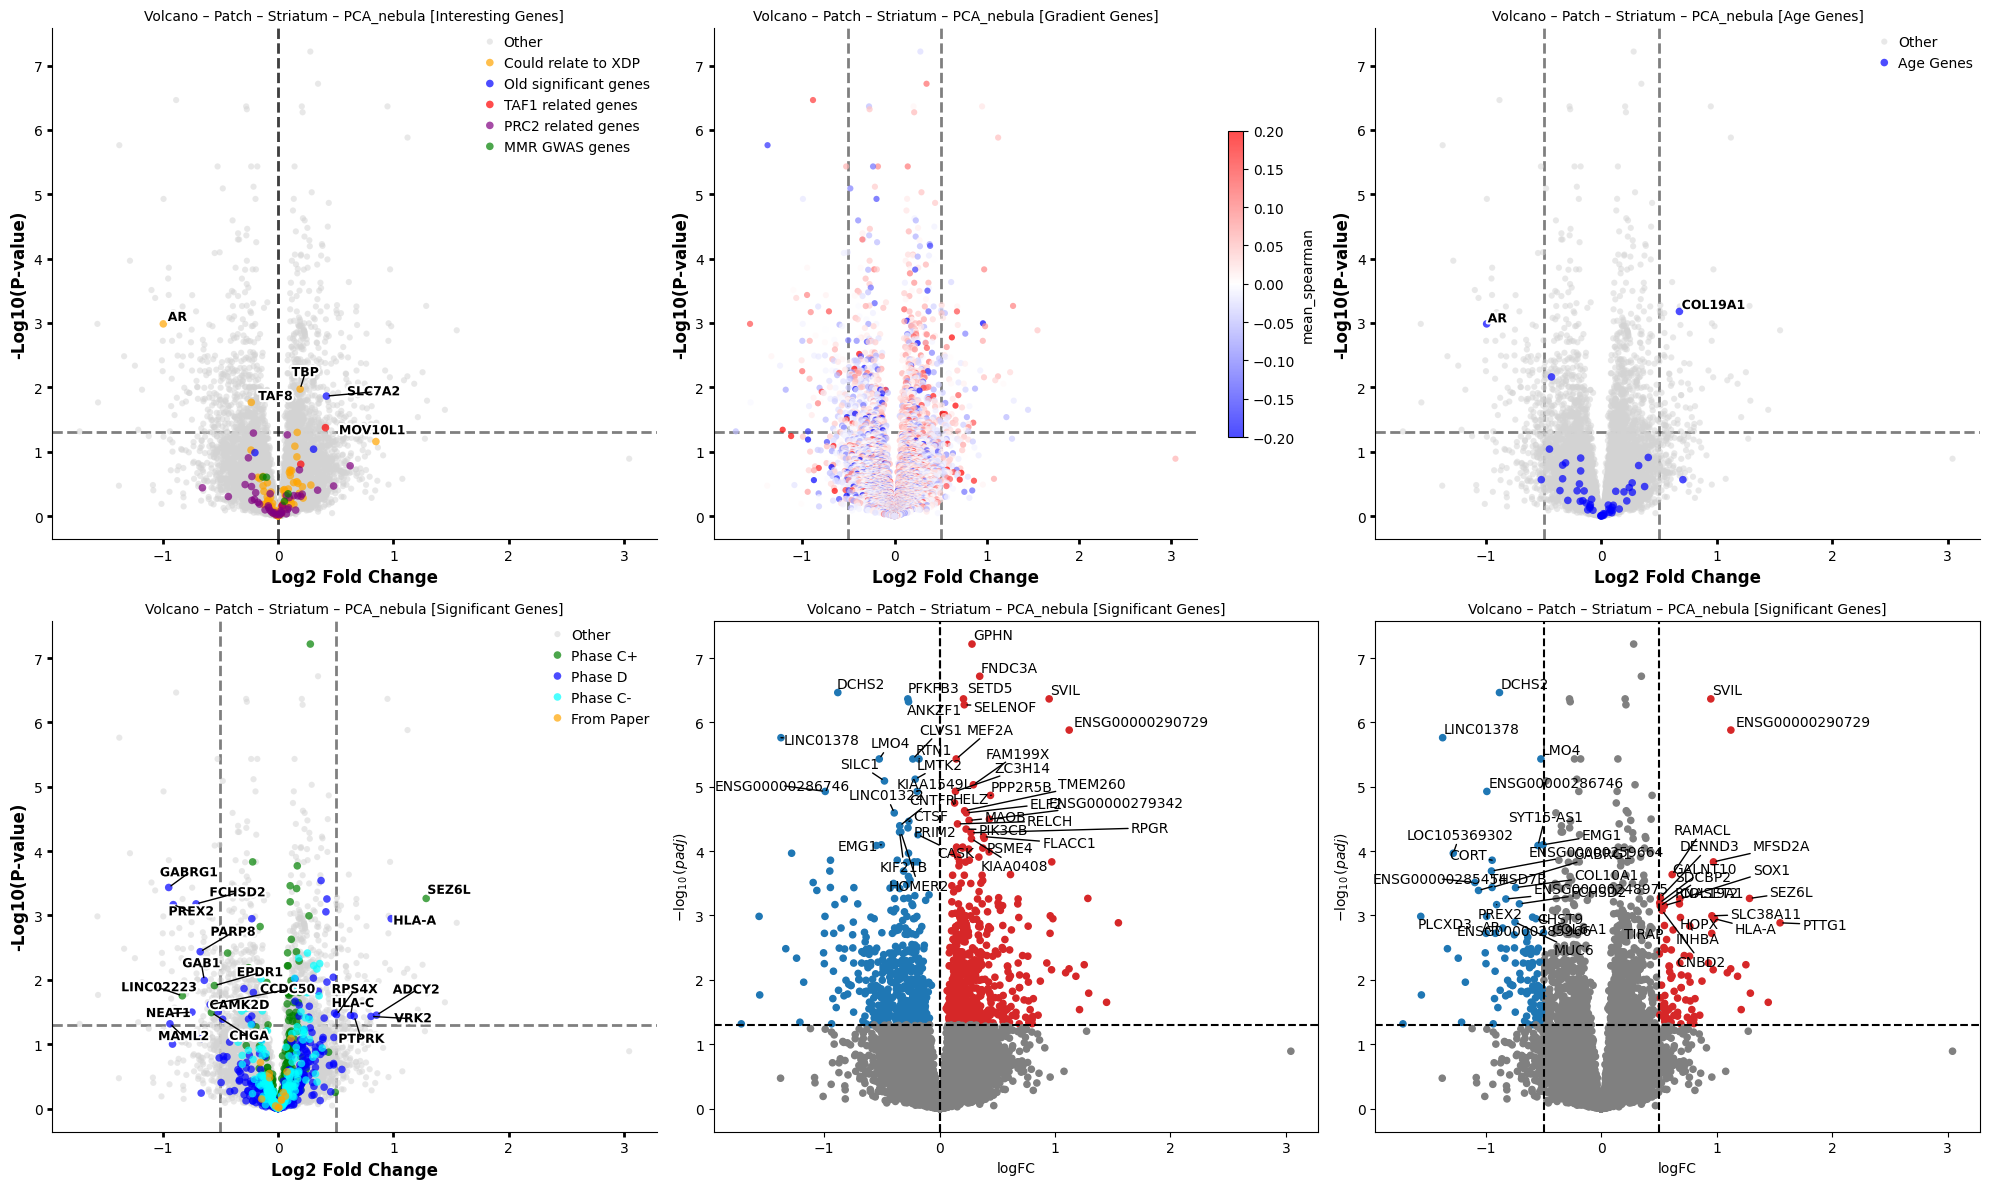

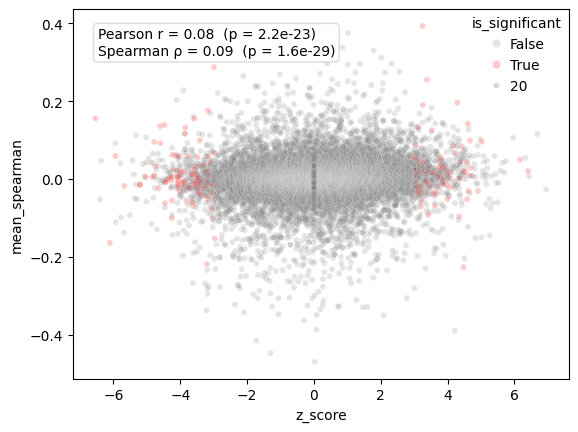

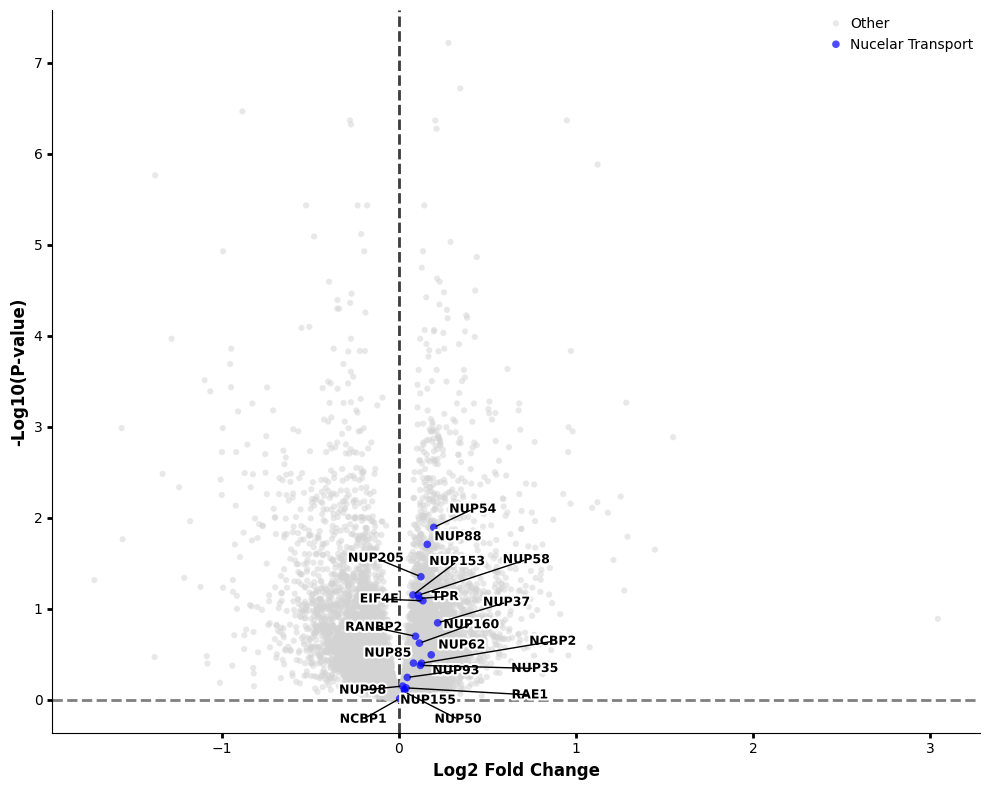

In [7]:
import shutil


for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

    #ct="Matrix"
    print("\n######################\n",ct, "\n######################\n")


    # fodle of results
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka
    print(save_csv_path)

    # Saved files
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "images")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
    os.makedirs(img_dir, exist_ok=True)
    
    formatted_save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results_formatted.csv"
    vulcano_plot_path = f"{img_dir}/volcano_plot.png"
    vulcano_plot_only_sig_path = f"{img_dir}/volcano_plot_only_sig.png"
    vulcano_plot_only_interesting_path = f"{img_dir}/volcano_plot_only_interesting.png"

    if not os.path.exists(save_csv_path):
        print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
        continue

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)

    #ATTENTION: beofre chage logfc
    df_nebula["z_score"] = df_nebula[LOGFC_COL] / df_nebula[SE_COL]  # Wald z

    # Add adj pvalue
    # attention: use all genes
    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)  # ln → log2
    df_nebula[COL_P_ADJ] = multipletests(df_nebula[PVAL_COL],method=METHOD_MULTIPLE_TEST)[1]

    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        #extreme negative intercept are likely very lowly expressed in controls and their logFC is unreliable. 
        extreme_intercept = df_nebula["logFC_(Intercept)"] < -20
        print(f"  Removing {extreme_intercept.sum()} genes with extreme intercept logFC")
        df_nebula = df_nebula[~extreme_intercept]

    # Add gradient info
    df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
    df_nebula = df_nebula.rename(columns={"is_gradient_gene": "is_grad_gene"})
    df_nebula = df_nebula.sort_values(COL_P_ADJ)

    # Selec signficant genes
    sig_genes = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[COL_P_ADJ] <= PVAL_THR)][GENE_COL].tolist()
    df_sig = df_nebula[df_nebula[GENE_COL].isin(sig_genes)].copy()
    df_sig = df_sig[[GENE_COL, LOGFC_COL, COL_P_ADJ, "is_grad_gene", "mean_spearman"]]
    #print(df_sig[GENE_COL].to_list())
    #display(df_sig)
    #print(df_sig["is_grad_gene"].sum())

    # Create formatted results 
    df_nebula_formatted = df_nebula[[GENE_COL, LOGFC_COL, PVAL_COL, "logFC_(Intercept)", "is_grad_gene", "mean_spearman"]].copy() # sleect spefici columns
    df_nebula_formatted["is_significant"] = df_nebula_formatted[GENE_COL].isin(sig_genes) # add column for signficant genes
    df_nebula_formatted.to_csv(formatted_save_csv_path, index=False)
    #display(df_nebula_formatted)

    #########
    ### VULCANO PLOT
    ##########
    categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green"),}
    categories_age = {"Age Genes": (["HCN1", "VWC2", "OPRM1", "BACH2", "PCED1B", "MME", "EBF1", "SPON1", "SEMA3E", "SERPINE2", "LINGO2", "GRM8", "KCNK2", "SINHCAF", "DDIT4L", "PTPN7", "PRKD1", "PEX5L", "OPCML", "SHC3", "PDE4B", "SLC24A2", "CCDC39", "FAT2", "CNTN5", "FIGN", "PTPRT", "MGAT4C", "IGF2BP2", "AR", "ETV1", "CDH10", "CORO1C", "SPRED2", "GJD2-DT", "ST3GAL6", "EPHA3", "UBASH3B", "PLEKHA7", "PLD5", "SH3RF3", "DOK5", "DOCK10", "SEMA3D", "KITLG", "SCN11A", "COL19A1", "ZNF732", "UNC13C", "SATB1"], "blue"),}
    categories_handsaker_phases = {
        "Phase D": (phase_d.Gene.to_list(), "blue"),
        "Phase C+": (phase_c_plus.Gene.to_list(), "green"),
        "Phase C-": (phase_c_minus.Gene.to_list(), "cyan"),
        "From Paper": (["PDE10A", "PPP2R2B", "PPP3CA", "PHACTR1", "RYR3", "KCNA4", "KCNAB1", "KCND2", "KCNH1","KCNK1", "KCNQ5", "KCTD1", "HOXA", "HOXB", "HOXC", "HOXD", "HOTAIR", "HOTTIP", "HOTAIRM1", "FOXD1", "LHX9", "ONECUT1", "POU4F2", "SHOX2", "SIX1", "TBX5", "TLX2", "ZIC4", "SLC17A6", "SLC17A7", "SLC6A5", "SLC1A2", "CALB2", "KCNC2", "CDKN2A", "CDKN2B"], "orange")
    }
    categories_general = {
        "TAF1 related genes": (["TAF1", "TIA1", "ZNF772", "SMG7", "ZNF93", "MOV10L1", "EXO1", "SSH", "GLIA1", "OGT", "GLI3"], "red"),
        "MMR GWAS genes": (["FAN1", "MLH1", "MSH3", "PMS1", "PMS2", "LIG1"], "green"),
        "Old significant genes": (["SLC7A2", "FKBP5", "ZBTB16", "HIF3A", "NR3C1"], "blue"),
        "PRC2 related genes":([
                                'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
                                'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
                                'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', '4933436C20RIK', 'LECT1', 'ALDH1A7',
                                'PYGL', 'DMRT3', 'TFAP2C', 'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1',
                                'AMN', 'TMEM30B', 'IRX3', 'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3',
                                'SIX6', 'COX6B2', 'TBX2', 'CD44', 'ASB4', 'PTPLAD2', 'SCARF2', 'VGLL2',
                                'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10', 'HOXA9', 'HOXC10', 'SLC6A5',
                                'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9', 'HOXB7', 'HOXB8', 'MNX1',
                                'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2', 'LUM', 'GATA2', 'PMAIP1',
                                'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1', 'FOXL2OS', 'HMX1', 'TBX3',
                                'FOXA1', 'EBF3', 'SIM1', '1500016L03RIK', 'HOXB13', 'EN1', 'SERPINA3N',
                                'RGNEF', 'HOXD13', 'LHX5', 'HOXA7', 'BC061194', 'HOXC5', 'NEUROD1', 'TFAP2A',
                                'HOXB5', 'SHOX2', 'TFAP2B', 'NEUROD2', '2610027K06RIK', 'TLX1', 'TNNT2',
                                'SULT1A1', 'VAX2', '1500011B03RIK', 'RPRD2', 'HOXD11', 'CDKN1A', 'NEUROG2',
                                'EOMES', 'PLIN4', 'TPBG', '4930447C04RIK', 'SSTR3', 'DLK1', 'PRDM8',
                                'E030030I06RIK', 'CES1D', 'HOXA4', 'NRN1', 'VSX2', 'AI448005', 'GFI1',
                                'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2', 'MATN2', 'HOXB3', 'KRT1',
                                'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2', 'HEYL', 'GSTA3', 'NKX2-5',
                                'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4', 'C130021I20RIK', 'SIX1', 'GRP',
                                'COL23A1', 'CIRBP', 'A030001D16RIK', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
                                'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'UGT1A1', 'UGT1A10', 'UGT1A2', 'UGT1A5',
                                'UGT1A6A', 'UGT1A6B', 'UGT1A7C', 'UTG1A9', 'ISLR', 'ASB5', 'MYCL1',
                                'TRP53I11', 'SDC1', '9530018H14RIK', 'GATA4', 'BEND5', 'GM15453', 'RBM3',
                                'FXYD7', 'FOXL2', '1700109F18RIK', 'GM8350', 'ZFP644', '4933439C10RIK',
                                'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25', 'CLDN3', 'SLC6A7', 'SERPINB1B',
                                'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD', 'GALNTL1', 'GNA13', 'ALX1',
                                'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1', 'CPA6', 'DMRT2',
                                'CPNE6', '9330171B17RIK', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
                                'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2'
                            ], "purple"),
        "Could relate to XDP": (
                            [
                            # Primary disease locus genes (Xq13.1)
                            "TAF1", "OGT", "OGA", "ACRC", "CXCR3", "NONO", "ING2", "NLGN3", "GJB1", "ZNF261", "ITGB1BP2",
                            
                            # Direct TAF1 protein interactors (TFIID complex)
                            "TBP", "TAF2", "TAF3", "TAF4", "TAF5", "TAF6", "TAF7", "TAF8", "TAF9", "TAF10", "TAF11", "TAF12", "TAF13",
                            
                            # TAF1 kinase/ubiquitin substrates and binding partners
                            "TP53", "MDM2", "RB1", "AR", "JUN", "CCND1", "CCNA2",
                            
                            # General Transcription Factors (PIC assembly)
                            "GTF2B", "GTF2A1", "GTF2A2", "GTF2E1", "GTF2E2", "GTF2F1", "GTF2F2", "GTF2H1", "GTF2H2", "GTF2H3", "GTF2H4", "GTF2H5", "TCEA1", "ERCC2", "ERCC3",
                            
                            # TAF1 in MLL1 complex
                            "KMT2A", "ASH2L", "HCFC1", "WDR5", "RBBP5",
                            
                            # Striatal signaling breakdown (dysregulated in XDP brain)
                            "DRD2", "DRD1", "PDE10A", "GNAL",
                            
                            # DSC3-affected downstream genes (vesicular transport, dopamine, synapse)
                            "SYP", "SNAP25", "RAB26", "RAB27B", "RAB8B", "DDC", "GCH1", "SLC18A2", "SYT7", "DLG4", "SNAP91", "DBH", "SYTL2", "SLC5A3", "EFNB1",
                            
                            # NFkB pathway and inflammatory targets (altered in XDP fibroblasts)
                            "RELA", "NFKB1", "NFKB2", "IKBKB", "IKBKG", "TNFAIP6", "IL8",
                            
                            # Repeat instability modifiers (shared with HD)
                            "MSH3", "PMS2",
                            
                            # Spliceosome and RNA metabolism (altered in XDP MSNs)
                            "SRSF2", "DHX15", "DHX9", "FUS", "GEMIN5", "HRNPU", "NOVA1", "PAPOLA", "PRPF6", "SART3", "SRSF5", "RALY", "U2AF1L5",
                            
                            # Translational machinery (compensatory upregulation in XDP MSNs)
                            "BMS1", "TRMT5",
                            
                            # SVA retrotransposon repression machinery (KRAB-ZNF / TRIM28 axis)
                            "ZNF91", "TRIM28", "ZNF93", "SETDB1", "DNMT3A", "DNMT3B",
                            
                            # LINE-1 mobilization machinery (SVA is L1-dependent)
                            "L1RE1",
                            
                            # NMD pathway (degrades TAF1-32i intron retention isoform)
                            "UPF1", "UPF2", "UPF3B",
                            
                            # Chromatin immunomodulatory (SVA heterochromatin)
                            "KMT5C", "CIITA",
                            
                            # TAF1 paralog
                            "TAF1L"
                            ], 
                            "orange"),
    }

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=0, # FROCE TO SEE ALL
        to_label=0, 
        categories=categories_general,
        max_y=None,
        ax=ax1,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        #categories=categories_spatial,
        color_by="mean_spearman", cmap="bwr", vmin=-0.2, vmax=0.2,
        max_y=None,
        ax=ax2,
        print_labels=False,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_age,
        max_y=None,
        ax=ax3,
        print_labels=True,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_handsaker_phases,
        max_y=None,
        ax=ax4,
        print_labels=True,
    )

    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=1e-20, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax5, 
    )

    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=LOGFC_THR, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax6, 
    )

    title = f"Volcano – {ct} – {TISSUE} – {TYPE_DEG}"
    for ax, lbl in zip(
        [ax1, ax2, ax3, ax4, ax5, ax6],
        ["Interesting Genes", "Gradient Genes", "Age Genes", "Significant Genes", "Significant Genes", "Significant Genes"] 
    ):        
        ax.set_title(f"{title} [{lbl}]", fontsize=10)

    # fig.canvas.draw()
    # saved_figs[ct] = fig
    
    plt.tight_layout() 


    plt.savefig(vulcano_plot_path, dpi=150, bbox_inches="tight")

    extent = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_interesting_path, bbox_inches=extent, dpi=150)
    extent = ax6.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_sig_path, bbox_inches=extent, dpi=150)
    plt.show()


    ####à
    # scatterpot correlstion
    df_nebula["is_significant"] = df_nebula[GENE_COL].isin(sig_genes)
    from scipy.stats import pearsonr, spearmanr
    ax_scat = sns.scatterplot(data=df_nebula, x="z_score", y="mean_spearman", hue="is_significant", palette={True: "red", False: "grey"}, alpha=0.2, size=20)
    # correlation + p-value
    d = df_nebula[["mean_spearman", "z_score"]].dropna()
    r_p, p_p = pearsonr(d["mean_spearman"], d["z_score"])
    r_s, p_s = spearmanr(d["mean_spearman"], d["z_score"])
    ax_scat.text(
        0.05, 0.95,
        f"Pearson r = {r_p:.2f}  (p = {p_p:.2g})\nSpearman ρ = {r_s:.2f}  (p = {p_s:.2g})",
        transform=ax_scat.transAxes, va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgrey", alpha=0.8),
    )
    plt.show()

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=1, 
        logfc_thresh=0,
        to_label=0, 
        categories=
            {"Nucelar Transport": (["NUP155","NUP58","NUP160","NUP93","NUP88","NUP54","TPR","NUP37","RANBP2","NUP153","EIF4E","NUP50","RAE1","NCBP2","NCBP1","NUP98","NUP85","NUP35","NUP205","NUP62"], "blue")},
        max_y=None,
        print_labels=True,
    ); plt.show()

    #break

   

# Make summary csv

Saves to `.../DEG/{TISSUE}/{METHOD}/summary/`:

| File | Content |
|------|---------|
| `all_cell_types.csv` | all regular cell types |
| `by_zone.csv` | CTs split by zone (Striatum only) |
| `by_zone_4.csv` | CTs split by zone_4 (Striatum only) |

Columns: `cell_type` · `gene` · `logFC` · `adj_pvalue` (fdr_bh) · `raw_pvalue`


To copy sumamri on bcuker

```bash
for tissue in Striatum DFC SN; do
  for method in cNMF_nebula baseline_nebula PCA_nebula; do
    gsutil -m cp -r \
      /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/${tissue}/${method}/_summary \
      gs://macosko_data/gdallagl/NucSeq/DEG_results/${tissue}/${method}/
  done
done

```

In [7]:
BASE   = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"
OUT    = os.path.join(BASE, "_summary")
if os.path.exists(OUT):
    shutil.rmtree(OUT)
os.makedirs(OUT, exist_ok=True)

def read_ct(csv_path, cell_type_label):
    df = pd.read_csv(csv_path).dropna(subset=[PVAL_COL, LOGFC_COL])

    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)  # ln → log2

    df["adj_pvalue"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1] 

    df = pd.DataFrame({
        "cell_type": cell_type_label,
        "gene":      df["gene"],
        "log2FC":     df[LOGFC_COL],
        "raw_pvalue":df[PVAL_COL],
        "adj_pvalue":df["adj_pvalue"],
        "signed_neg_log10_p_xdp": -np.log10(df["adj_pvalue"]) * np.sign(df[LOGFC_COL]),
        "logFC_intercept": df["logFC_(Intercept)"],
    })
    df = df.merge(df_grad[["mean_spearman", "p-value_gradient", "is_gradient_gene"]], how="left", left_on="gene", right_index=True)

    return df

regular, by_zone, by_zone_4 = [], [], []

for ct_dir in sorted(os.listdir(BASE)):
    ct_path = os.path.join(BASE, ct_dir)
    if (not os.path.isdir(ct_path)) or ct_dir.startswith("_summary"):
        continue

    if "_by_zone_4" in ct_dir:
        target = by_zone_4
    elif "_by_zone" in ct_dir:
        target = by_zone
    else:
        target = regular

    if target is regular:
        csv = os.path.join(ct_path, "deg_results.csv")
        if os.path.isfile(csv):
            regular.append(read_ct(csv, ct_dir))
    else:
        for zone_num in sorted(os.listdir(ct_path)):
            csv = os.path.join(ct_path, zone_num, "deg_results.csv")
            if os.path.isfile(csv):
                target.append(read_ct(csv, f"{ct_dir}/{zone_num}"))

for name, dfs in [("all_cell_types", regular), ("by_zone", by_zone), ("by_zone_4", by_zone_4)]:
    if dfs:
        out_path = os.path.join(OUT, f"{name}.csv")
        pd.concat(dfs, ignore_index=True).to_csv(out_path, index=False)
        print(f"Saved {name}.csv  ({len(dfs)} cell-type blocks) → {out_path}")


# Most frequent genes
df_all = pd.read_csv(f"{OUT}/all_cell_types.csv")
sig = df_all[(df_all["adj_pvalue"] <= PVAL_THR) & (df_all["log2FC"].abs() >= LOGFC_THR)]
gene_ct_count = sig.groupby("gene")["cell_type"].nunique().sort_values(ascending=False)
print(gene_ct_count.head(30))  # genes significant in most cell types



Saved all_cell_types.csv  (14 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/_summary/all_cell_types.csv
Saved by_zone.csv  (10 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/_summary/by_zone.csv
Saved by_zone_4.csv  (16 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/_summary/by_zone_4.csv
gene
HLA-A              8
HCP5               7
SVIL               7
NPNT               6
BTN3A3             6
RNASET2            6
ENSG00000259678    6
LINC01378          6
RASD1              5
HOPX               5
MFSD2A             5
HLA-B              5
ENSG00000286746    5
LOC105376654       5
SEZ6L              5
ENSG00000286536    5
CPNE7              5
KCNJ5-AS1          5
FAM110C            5
FKBP5              5
IGSF22             5
RPSA2              5
CNBD2              5
PRDX4              4
KCNJ1              4
SHC2               4
SLC38A11           4
UMODL1     

# GSEA on DEGs genes

In [33]:
genes_in_db = set().union(*gs_dict.values())

overlap = set(ranked_series.index) & genes_in_db

print("ranked genes:", len(ranked_series))
print("db genes:", len(genes_in_db))
print("overlap:", len(overlap))
print("overlap pct:", len(overlap)/len(ranked_series))

ranked genes: 16468
db genes: 3264
overlap: 1764
overlap pct: 0.10711683264512994


In [34]:
ranked_series

gene
SEMA3D             12.217978
ENSG00000285987    11.366983
ADGRB1              9.149809
PRKX                9.122819
FMO2                8.950457
                     ...    
ENSG00000287972    -5.845133
CNKSR3             -6.266270
LINC02930          -6.932372
USH1C              -7.818277
KCNH8             -10.342023
Name: rank_metric, Length: 16468, dtype: float64

In [6]:
# chekc which libraires
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

In [8]:
# Homemade genesets

#Gradient genes (split by direction)
custom_gene_sets = {
    "Gradient_DorsalVentral": grad_genes,   # all gradient genes
    "Gradient_Dorsal":  df_grad[(df_grad.mean_spearman < 0) & (df_grad.is_gradient_gene)].index.tolist(),  # positive spearman
    "Gradient_Ventral": df_grad[(df_grad.mean_spearman > 0) & (df_grad.is_gradient_gene)].index.tolist(),  # negative spearman
    "PhaseD_genes":     phase_d["Gene"].dropna().tolist(),
    "PhaseC+_genes":   phase_c_plus["Gene"].dropna().tolist(),
    "PhaseC-_genes":   phase_c_minus["Gene"].dropna().tolist(),
    "polycomb": lmu.prc2_genes,
    "mix_handsaker": lmu.handsaker_genes,
    "xdp_related": lmu.xdp_genes,
}
print({k: len(v) for k, v in custom_gene_sets.items()})  # check sizes


{'Gradient_DorsalVentral': 1241, 'Gradient_Dorsal': 691, 'Gradient_Ventral': 550, 'PhaseD_genes': 719, 'PhaseC+_genes': 327, 'PhaseC-_genes': 220, 'polycomb': 140, 'mix_handsaker': 37, 'xdp_related': 115}


In [9]:
collections_gsea = [
    ("custom",                               custom_gene_sets,                                    custom_gene_sets,                   1,    5000),
    ("MSigDB_Hallmark_2020",                 ["MSigDB_Hallmark_2020"],                              gp.get_library("MSigDB_Hallmark_2020"),              15,  250),
    ("SynGO_2024",                           ["SynGO_2024"],                                        gp.get_library("SynGO_2024"),              15,  250),
    ("Reactome_Pathways_2024",               ["Reactome_Pathways_2024"],                          gp.get_library("Reactome_Pathways_2024"),             15,  250),
    ("GO_Biological_Process_2025",           ["GO_Biological_Process_2025"],                      gp.get_library("GO_Biological_Process_2025"),         15,  250),
    ("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X", ["ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"], gp.get_library("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"), 15, 250),
    ("TRRUST_Transcription_Factors_2019",    ["TRRUST_Transcription_Factors_2019"],               gp.get_library("TRRUST_Transcription_Factors_2019"),  15,  250),
]


2026-05-27 13:29:46 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-27 13:29:46 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file
2026-05-27 13:29:46 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-27 13:29:46 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.SynGO_2024.gmt, use local file
2026-05-27 13:29:46 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-27 13:29:46 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-05-27 13:29:46 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-05-27 13:29:47 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-27 13:29:47 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local fi

In [10]:
def filter_noisy_genes(ranked_series, verbose=True):

    return ranked_series

    import re

    n_before = len(ranked_series)

    # ── Regex approach ─────────────────────────────────────────────────
    # Covers the most common non-informative gene classes in snRNA-seq
    _pattern = re.compile(r"""^(
        RPL   | RPS   | MRPL  | MRPS  |  # ribosomal proteins (cytoplasmic + mitochondrial)
        MT-                            |  # mitochondrial protein-coding genes
        LINC                           |  # long intergenic non-coding RNA
        SNHG  | SNORA | SNORD          |  # small nucleolar RNA host genes / snoRNAs
        MIR[0-9]                       |  # microRNAs (MIR followed by number)
        RNU                            |  # small nuclear RNAs
        ENSG                              # unmapped Ensembl IDs
    )""", re.IGNORECASE | re.VERBOSE)

    noisy = [g for g in ranked_series.index if _pattern.match(g)]
    ranked_series = ranked_series.drop(index=noisy)

    n_removed = n_before - len(ranked_series)
    if verbose:
        print(f"  filter_noisy_genes: removed {n_removed} genes  "
              f"({n_before} → {len(ranked_series)} remaining)")

    return ranked_series

def from_deg_df_to_df_rank(df, GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col=None, REMOVE_GENE_TOO_HIGH_INTERCEPT=True, REMOVE_RIBO_GENES_FROM_GSEA=True, intercept_logfc_col="logFC_(Intercept)"):

    df_rank = df.copy()
    
    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        # extreme negative intercept → very lowly expressed in controls, logFC unreliable
        extreme_intercept = df_rank[intercept_logfc_col] < -20
        print(f"  [filter] Removed {extreme_intercept.sum()} genes with extreme intercept logFC (< -20)")
        df_rank = df_rank[~extreme_intercept]

    # if score is not porviced we msut claculted it
    if score_col is None:
        if PVAL_COL is None or LOGFC_COL is None:
            raise ValueError("Must provide either score_col or both PVAL_COL and LOGFC_COL")
        
        df_rank = df_rank.dropna(subset=[PVAL_COL, LOGFC_COL])

        # DEFINE RANK METRIC
        # Options:
        #   sign(logFC) * -log10(p_raw)   ← direction from sign only
        #   logFC * -log10(p_raw)         ← direction + magnitude from logFC (current)
        #   logFC / SE                    ← t-statistic style
        # ATTENTION: use     p-values — GSEA does its own permutation-based multiple testing
        df_rank["rank_metric"] = (
            np.sign(df_rank[LOGFC_COL]) *
            -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
        )
    else:
        if score_col not in df_rank.columns:
            raise ValueError(f"score_col '{score_col}' not found in DataFrame")
        df_rank["rank_metric"] = df_rank[score_col]

    sns.histplot(df_rank["rank_metric"], bins=100); plt.show()

    # Sort descending so most-upregulated genes are at the top
    df_rank = df_rank.sort_values("rank_metric", ascending=False)

    # ── Build the Series for GSEA (gene name as index, rank_metric as values) ──
    ranked_series = df_rank.set_index(GENE_COL)["rank_metric"]

    # Remove non coding genes
    if REMOVE_RIBO_GENES_FROM_GSEA:

        ranked_series = filter_noisy_genes(ranked_series,verbose=True)
        
        # Keep df_rank in sync: only retain genes that survived the filter
        surviving_genes = ranked_series.index
        df_rank = df_rank[df_rank[GENE_COL].isin(surviving_genes)]

    # ranked_series → input to gp.prerank (Series, gene as index)
    # df_rank       → full DataFrame for ORA background, leading-edge logFC lookup, adj p-val computation
    return ranked_series, df_rank


  CELL TYPE: Matrix


,logFC_(Intercept),logFC_conditionXDP,logFC_age_of_death,logFC_sexM,logFC_pct_counts_mt,logFC_frac_intronic,logFC_cohortCohort_2,logFC_cohortCohort_3,logFC_PC_1,logFC_PC_2,...,p_PC_3,p_PC_4,p_PC_5,p_PC_6,p_PC_7,p_PC_8,p_PC_9,gene_id,gene,z_score
0,-13.353526,0.124880,-0.004279,-0.132517,0.058423,-1.300231,-0.306669,0.303539,-0.006183,-0.003462,...,3.148026e-03,8.123482e-02,5.406777e-02,7.887764e-01,5.335106e-02,8.606675e-01,5.046503e-02,1,ENSG00000238009,0.806399
1,-12.699041,-0.076004,-0.000444,0.053153,0.030146,1.708623,0.012612,0.167589,-0.008415,-0.010643,...,9.034507e-03,2.123533e-02,6.729887e-01,1.649131e-02,4.153807e-02,7.928683e-04,1.476108e-01,2,ENSG00000241860,-0.818161
2,-13.193511,0.067605,-0.002436,0.010325,-0.040806,1.683810,0.293768,0.393410,-0.007397,-0.005740,...,3.097660e-02,6.982522e-01,1.226134e-02,3.566818e-03,8.111226e-01,5.948371e-03,2.262069e-01,3,ENSG00000290385,0.696024
3,-11.232847,-0.084119,0.001731,0.042205,-0.089394,-1.867073,0.002340,0.111962,-0.015193,-0.004070,...,3.704786e-10,9.550845e-01,1.558075e-02,6.698841e-01,5.073183e-01,3.094712e-10,5.115737e-03,4,ENSG00000291215,-0.870601
4,-10.290495,0.170345,-0.001739,-0.047009,0.160695,-1.763172,0.024138,0.198567,-0.011113,0.007227,...,2.839040e-27,9.082979e-01,1.197056e-04,3.180267e-17,1.349415e-01,9.204533e-25,1.354436e-14,5,LINC01409,1.506951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20789,-12.079421,-0.148384,-0.004074,-0.038220,-0.116204,0.284011,-0.308001,0.093937,-0.003363,0.006254,...,3.034855e-04,3.265102e-04,1.302698e-03,1.991007e-01,7.884401e-01,2.487553e-04,2.499215e-08,515,ENSG00000276256,-0.790038
20790,-11.564317,0.082909,-0.003874,-0.094672,0.039058,1.525391,-0.147394,-0.119086,-0.009925,0.004965,...,9.207418e-01,5.026361e-01,2.717433e-01,6.663892e-02,1.326178e-01,2.459832e-08,3.981944e-01,516,ENSG00000278384,0.272724
20791,-9.546142,0.012220,-0.003463,-0.102783,-0.034221,-0.470247,0.195162,0.133900,-0.030719,-0.005288,...,8.853625e-22,2.419750e-24,6.662671e-49,8.192997e-01,1.718958e-12,4.175481e-37,1.821015e-05,517,ENSG00000273748,0.051504
20792,-12.165589,-0.120560,-0.003144,0.185823,-0.069742,0.590260,0.545082,0.699103,-0.010568,-0.011993,...,4.648873e-03,9.076673e-01,2.060536e-01,1.123790e-03,2.854349e-01,2.220004e-03,6.323648e-02,518,LOC124905564,-1.076951


<Axes: xlabel='p_conditionXDP', ylabel='Count'>

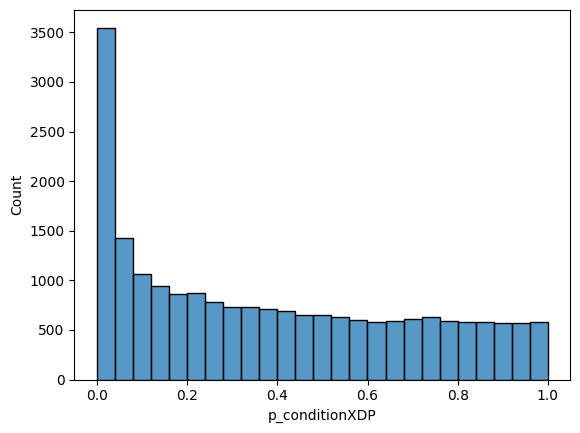

  [filter] Removed 0 genes with extreme intercept logFC (< -20)


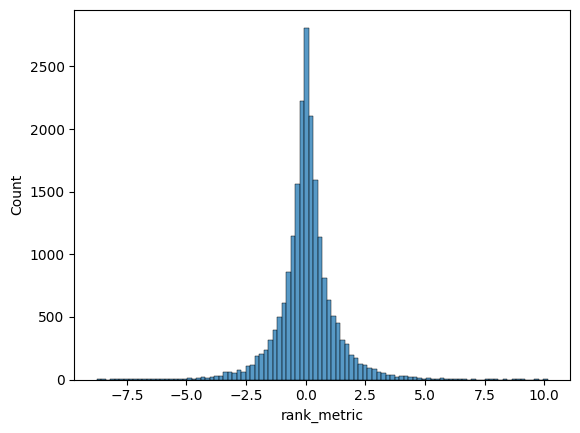

  [rank]   20794 genes in final ranked list (top: SEZ6L +10.15, bottom: VAC14 -8.75)


gene
SEZ6L              10.152351
RNASET2            10.064668
SETD5               9.697072
RPSA2               9.075209
CBLL1               8.865571
                     ...    
LIPH               -8.042106
HSALR1             -8.417327
ENSG00000286746    -8.424840
MAN2B1             -8.484159
VAC14              -8.754006
Name: rank_metric, Length: 20794, dtype: float64


  ──────────────────────────────────────────────────
  GSEA  ▶  custom
  ──────────────────────────────────────────────────
  [result] 9 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,PhaseC+_genes,1.845732,0.0,SEZ6L;MBD5;KIAA0825;ARID4B;KMT2C;NUP58;INPP4B;PCNX1;MCF2L2;LSM14A;VEZT;GPHN;JPX;PGAP1;PUS7L;MICU3;ARHGAP26;LINC00632;DMTF1;MEF2C-AS1;GLS;NDFIP1;NDFIP2;NSD3;UBQLN1;STRN3;UBE2E2;TRIP12;PPP1R12B;CNTNAP2;AAK1;LCLAT1;ARIH1;MATR3;CCSER1;NALCN;XIST;CAPN7;BRAF;ERC1;REV3L;CADPS;PIAS1;UPP2;UBR2;TIA1;MON2;SRPK2;HNRNPD;PSPC1;ATP9B;CUL1;CNOT4;MYCBP2;GSTA4;UTY;ZCCHC17;SYBU;ZFAND3;HMGN1;KIDINS220;CHM;ARFGEF3;MAP7;GABRA2;MIR137HG;ARHGEF12;POLR2A;UBR3;APTX;CSMD3;TNRC6C;SUPT3H;KMT2E;UBXN4;UBR5;TP53BP1;FBXO21;INTS6;SPIN1;KDM5A;PSIP1;PPA2;CADM2;FXR1;PAPOLA;NEK10;REPS1;NRXN3;WDFY2;AEBP2;ZNF609;DNM1L;KIFAP3;NIPAL2;DYRK1A;USP47;CCDC192;LINC00886;STXBP5;DDX5;NIPBL;RTN3;INTU;DLEU2;USP24;LINC01473;GPATCH2;TIAM2;MICU1;DCDC2C;LINC01376;ARHGEF26-AS1;MPPED2;FBXW7;UBN2;BICD1;ANKIB1;TRA2A;ANK2;SNHG14


/tmp/ipykernel_2794424/3272072167.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0


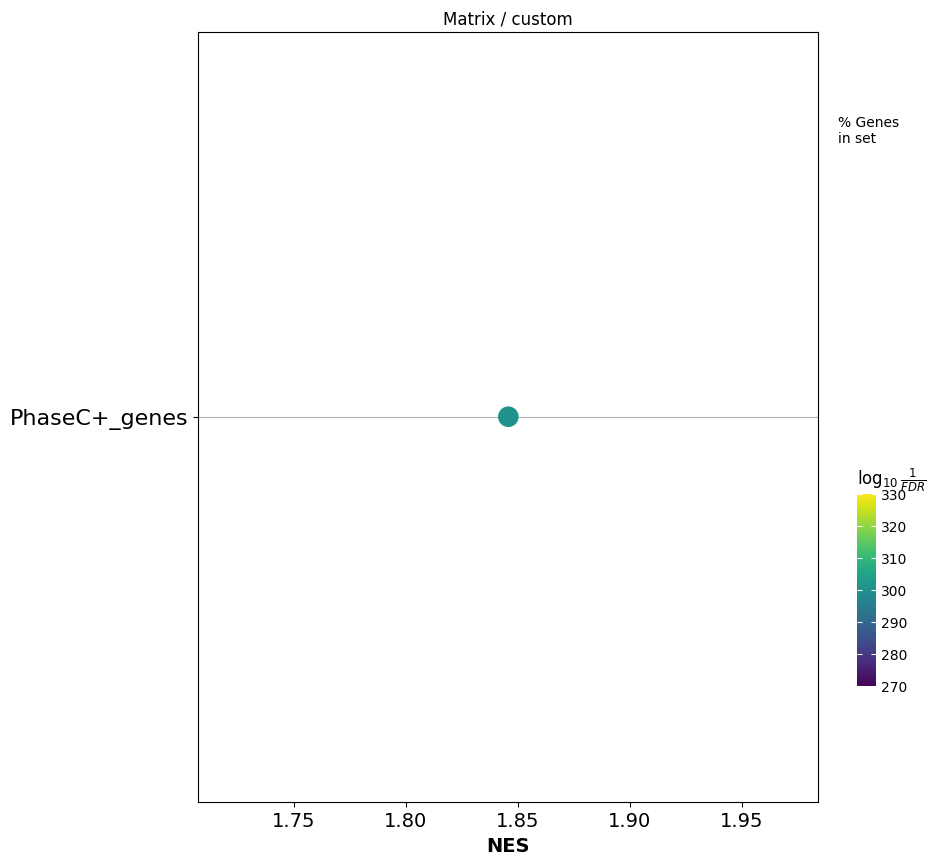


  [leading edge]  custom
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  MSigDB_Hallmark_2020
  ──────────────────────────────────────────────────
  [result] 50 pathways tested  →  2 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,MSigDB_Hallmark_2020__Unfolded Protein Response,1.956922,0.0,ERO1A;DKC1;IARS1;WFS1;EIF2S1;SSR1;XBP1;SERP1;DCP2;DNAJB9;EIF2AK3;POP4;HYOU1;HERPUD1;EIF4A2;EIF4E;PAIP1;NPM1;PDIA6;DDIT4;TSPYL2;SEC31A;ALDH18A1;CNOT4;IMP3;ATF6;HSPA9;PREB;XPOT;BANF1;DCP1A;FKBP14;TUBB2A;ASNS;SLC1A4;SRPRA;MTREX;LSM1;DNAJA4;EIF4G1;SPCS3;CKS1B;HSP90B1;PARN;SLC7A5
1,MSigDB_Hallmark_2020__Myc Targets V1,1.804135,0.003206,PRDX4;IARS1;CNBP;EEF1B2;PSMA2;EIF2S1;YWHAQ;DHX15;HNRNPC;PSMB2;PSMD7;ACP1;CBX3;VBP1;TOMM70;SRPK1;EPRS1;DUT;EIF4E;SMARCC1;NPM1;KPNB1;ABCE1;RPS2;PPIA;CCT3;HNRNPU;SNRPB2;HNRNPD;XPO1;CUL1;SRM;CLNS1A;PGK1;HDAC2;YWHAE;CANX;RPL18;XPOT;HPRT1;NAP1L1;PABPC1;HNRNPR;NCBP2;RAN;RPS6;ODC1;PSMA7;NCBP1;SNRPD1;MCM4;PCNA;AP3S1;ILF2;UBA2;POLE3;SNRPG;RPS3;APEX1;MAD2L1;PSMD14;HDDC2;CDK4;CCT7;EIF1AX;PTGES3;PA2G4;TRA2B;EXOSC7;GSPT1;CCNA2;USP1


/tmp/ipykernel_2794424/3272072167.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0


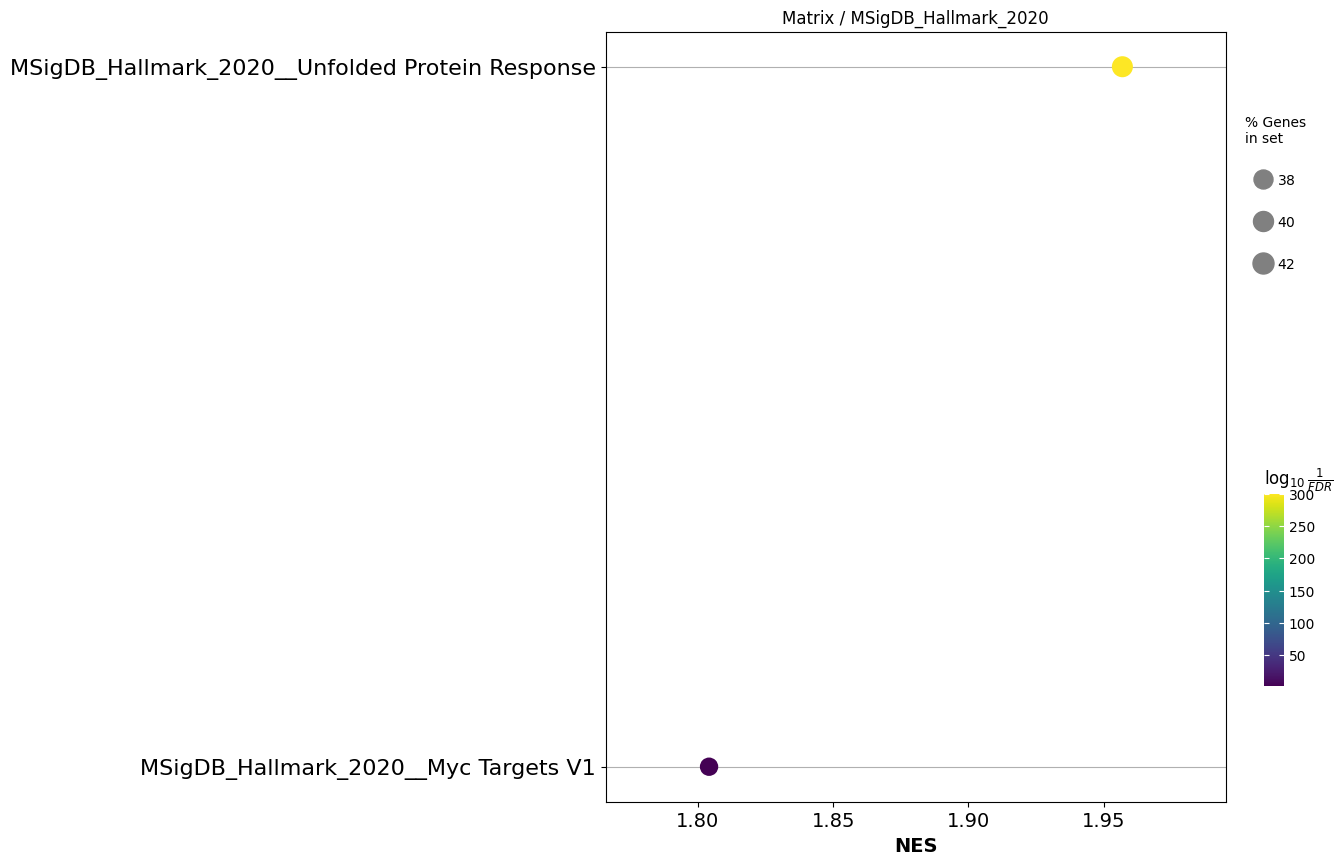


  [leading edge]  MSigDB_Hallmark_2020
  [leading edge]  genes in ≥2 pathways: 5


,gene,n_pathways
0,IARS1,2
1,EIF2S1,2
2,EIF4E,2
3,NPM1,2
4,XPOT,2


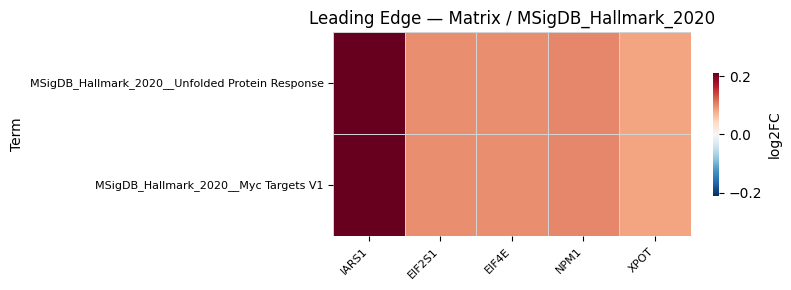

  [collapsed]  2 pathways → 2 clusters


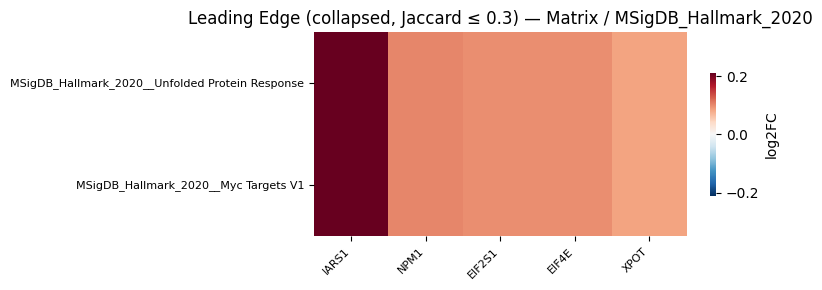


  ──────────────────────────────────────────────────
  GSEA  ▶  SynGO_2024
  ──────────────────────────────────────────────────
  [result] 56 pathways tested  →  4 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
1,SynGO_2024__Presynaptic Ribosome CC,1.764241,0.023211,RPL15;MRPS12;RPS15A;RPL35A;RPL18;RPL4;RPL37;RPS28;RPS6;RPL9;RPL7;RPL5;RPL26;RPL10A;RPL29;RPS27;RPL32;RPL8;RPL23;RPS16;RPL24;RPL6;RPL38;UBA52;RPL17;RPL22;RPL34;RPS24
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.745429,0.02397,RPL15;MRPS12;RPS15A;RPL35A;RPL18;RPL4;RPL37;RPS28;RPL9;RPL7;RPL5;RPL26;RPL10A;RPL29;RPS27;RPL32;RPL8;RPL23;RPS16;RPL24;RPL6;RPL38;UBA52;RPL17;RPL22;RPL34;RPS24
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,1.711835,0.025259,RPL15;MRPS12;RPS15A;RPL35A;RPL18;RPL4;RPL37;RPS28;RPL9;RPL7;RPL5;RPL26;RPL10A;RPL29;RPS27;RPL32;RPL8;RPL23;RPS16;RPL24;RPL6;RPL38;UBA52;RPL17;RPL22;RPL34;RPS24
0,SynGO_2024__Postsynaptic Ribosome CC,1.792759,0.035499,RPL15;MRPS12;RPS2;RPS15A;RPL35A;RPL18;RPS17;RPL4;RPL37;RPS28;RPS6;RPL9;RPL7;RPL5;RPL26;RPS3;RPS3A;RPL10A;RPL29;RPS27;RPS7;RPL32;RPL8;RPL21;RPL23;RPS16;RPL31;RPL24;RPS8;RPL6;RPL38;UBA52;RPL17;RPL22;RPL34;RPLP1;RPS24


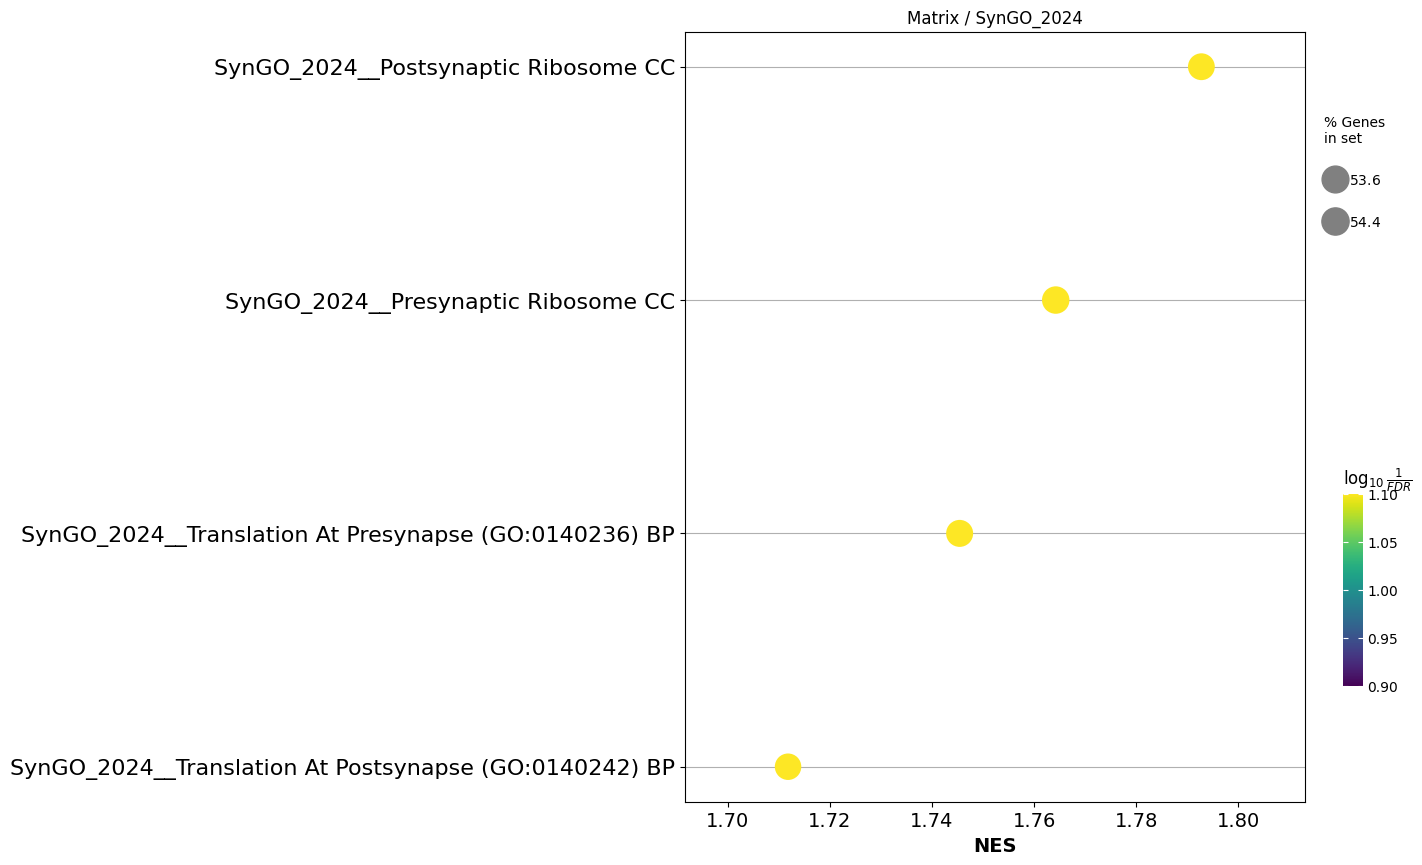


  [leading edge]  SynGO_2024
  [leading edge]  genes in ≥2 pathways: 28


,gene,n_pathways
0,RPL15,4
1,MRPS12,4
2,RPS15A,4
3,RPL35A,4
4,RPL18,4
5,RPL4,4
6,RPL37,4
7,RPS28,4
8,RPL9,4
9,RPL7,4


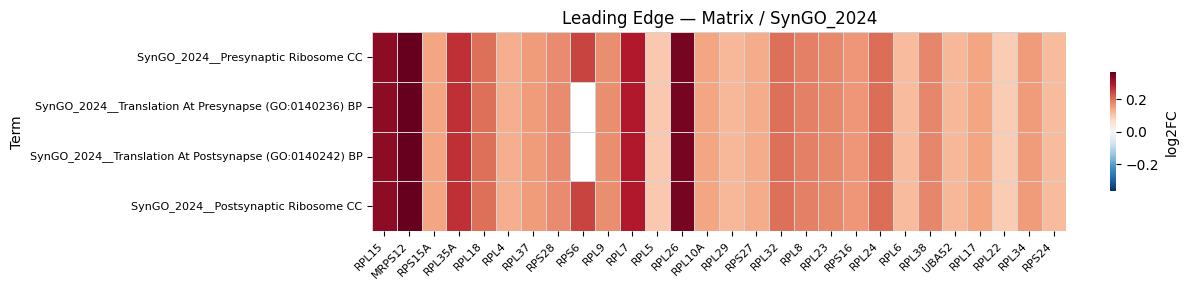

  [collapsed]  4 pathways → 1 clusters
  [collapsed]  No recurring genes after collapsing — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  Reactome_Pathways_2024
  ──────────────────────────────────────────────────
  [result] 1155 pathways tested  →  23 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,Reactome_Pathways_2024__Defective B3GALTL Causes PpS,-2.134384,0.000842,ADAMTSL2;THBS1;THSD7B;ADAMTS10;ADAMTS3;ADAMTSL1;THSD7A;THSD1;THSD4;ADAMTS13;ADAMTSL3
1,Reactome_Pathways_2024__O-glycosylation of TSR Domain-Containing Proteins,-2.110016,0.001264,ADAMTSL2;THBS1;THSD7B;ADAMTS10;ADAMTS3;ADAMTSL1;THSD7A;THSD1;THSD4;ADAMTS13;ADAMTSL3
10,Reactome_Pathways_2024__SUMOylation of RNA Binding Proteins,1.883282,0.019301,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;HNRNPC;TPR;NUP37;RANBP2;RNF2;NUP153;NOP58;CBX4;NUP50;RAE1
11,Reactome_Pathways_2024__SLC Transporter Disorders,1.873889,0.020078,NUP155;SLC9A9;NUP58;NUP160;GCK;NUP93;SLC3A1;NUP88;NUP54;SLC20A2;SLC33A1;TPR;NUP37;RANBP2;NUP153;SLCO2A1;NUP50;RAE1;BSG
9,Reactome_Pathways_2024__Transport of the SLBP Independent Mature mRNA,1.886759,0.020304,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;EIF4E;NUP50;RAE1;NCBP2;NCBP1;NUP98;NUP85;NUP35;NUP205;NUP62
13,Reactome_Pathways_2024__Vpr-mediated Nuclear Import of PICs,1.862823,0.020492,NUP155;NUP58;NUP160;NUP93;KPNA1;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;NUP50;RAE1;BANF1;PSIP1;NUP98;NUP85;NUP35;NUP205;NUP62
7,Reactome_Pathways_2024__Defective TPR May Confer Susceptibility Towards Thyroid Papillary Carcinoma (TPC),1.891237,0.020787,NUP155;NUP58;NUP160;GCK;NUP93;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;NUP50;RAE1
8,Reactome_Pathways_2024__Regulation of Glucokinase by Glucokinase Regulatory Protein,1.891237,0.020787,NUP155;NUP58;NUP160;GCK;NUP93;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;NUP50;RAE1
14,Reactome_Pathways_2024__NEP NS2 Interacts With the Cellular Export Machinery,1.856621,0.020911,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;XPO1;NUP50;RAE1;RAN;NUP98;NUP85;NUP35;NUP205;NUP62
6,Reactome_Pathways_2024__Transport of the SLBP Dependant Mature mRNA,1.903895,0.021883,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;TPR;NUP37;RANBP2;NUP153;EIF4E;SLBP;NUP50;RAE1;NCBP2;NCBP1;NUP98;NUP85;NUP35;NUP205;NUP62


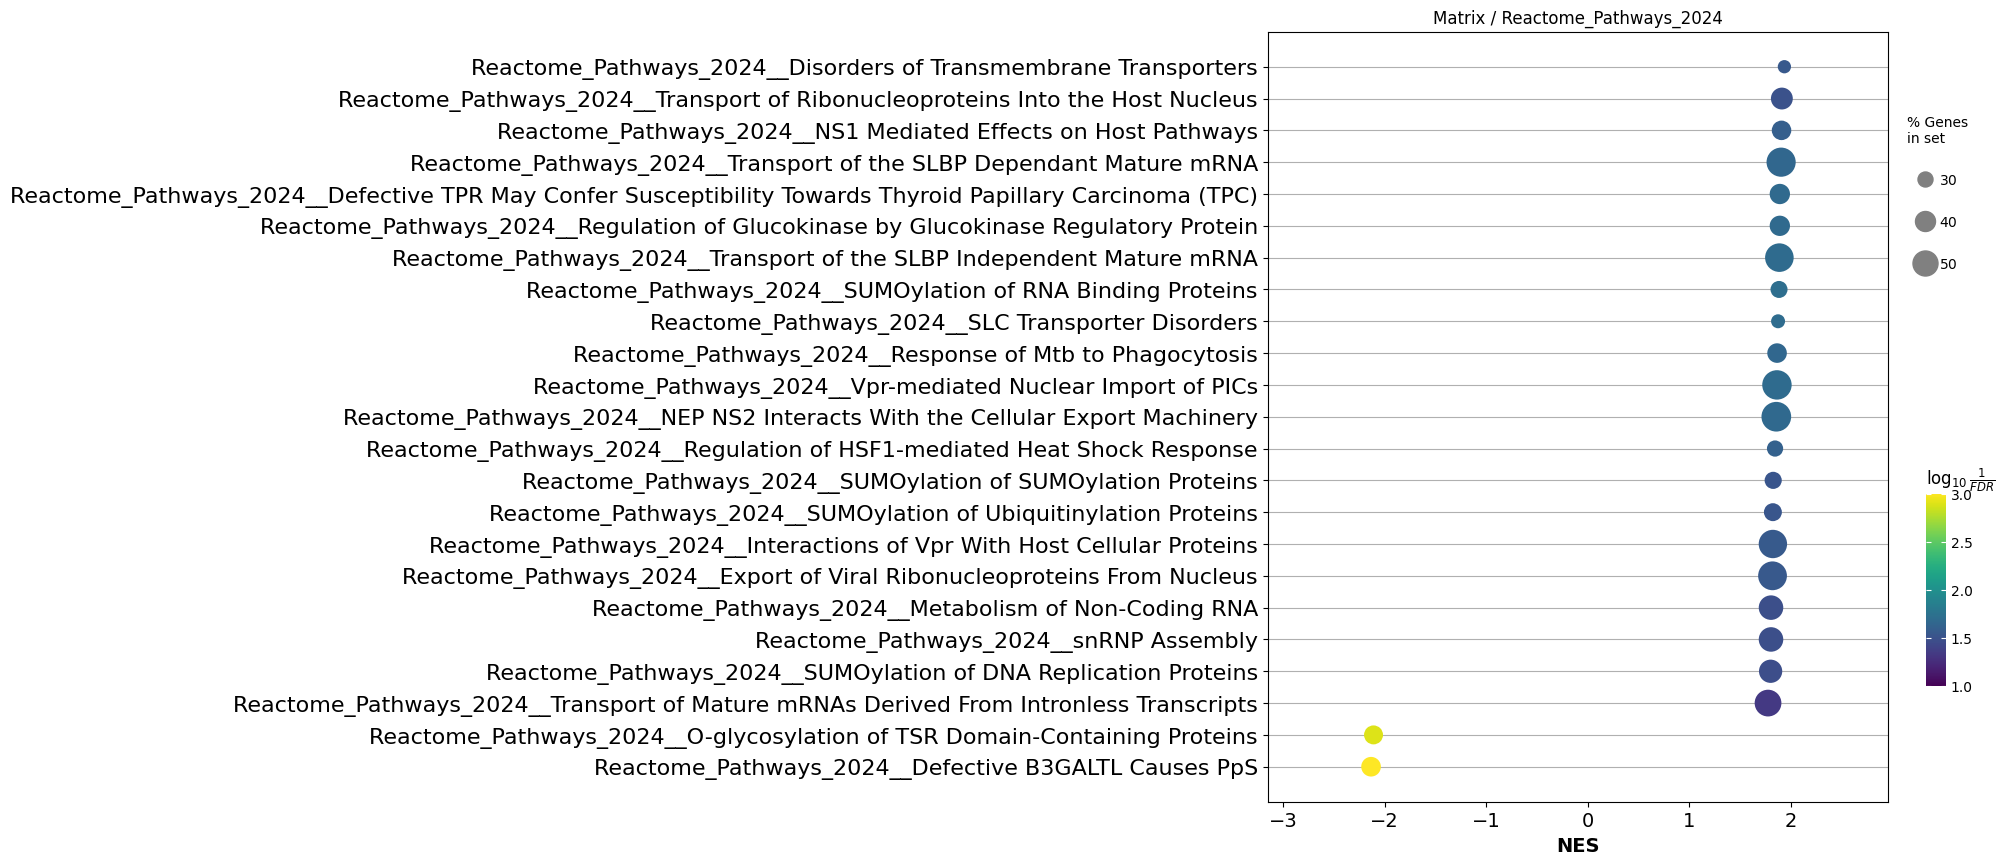


  [leading edge]  Reactome_Pathways_2024
  [leading edge]  genes in ≥2 pathways: 54


,gene,n_pathways
0,NUP155,20
1,NUP58,20
2,NUP160,20
3,NUP93,20
4,NUP88,20
5,NUP54,20
6,TPR,20
7,NUP37,20
8,RANBP2,20
9,NUP153,20


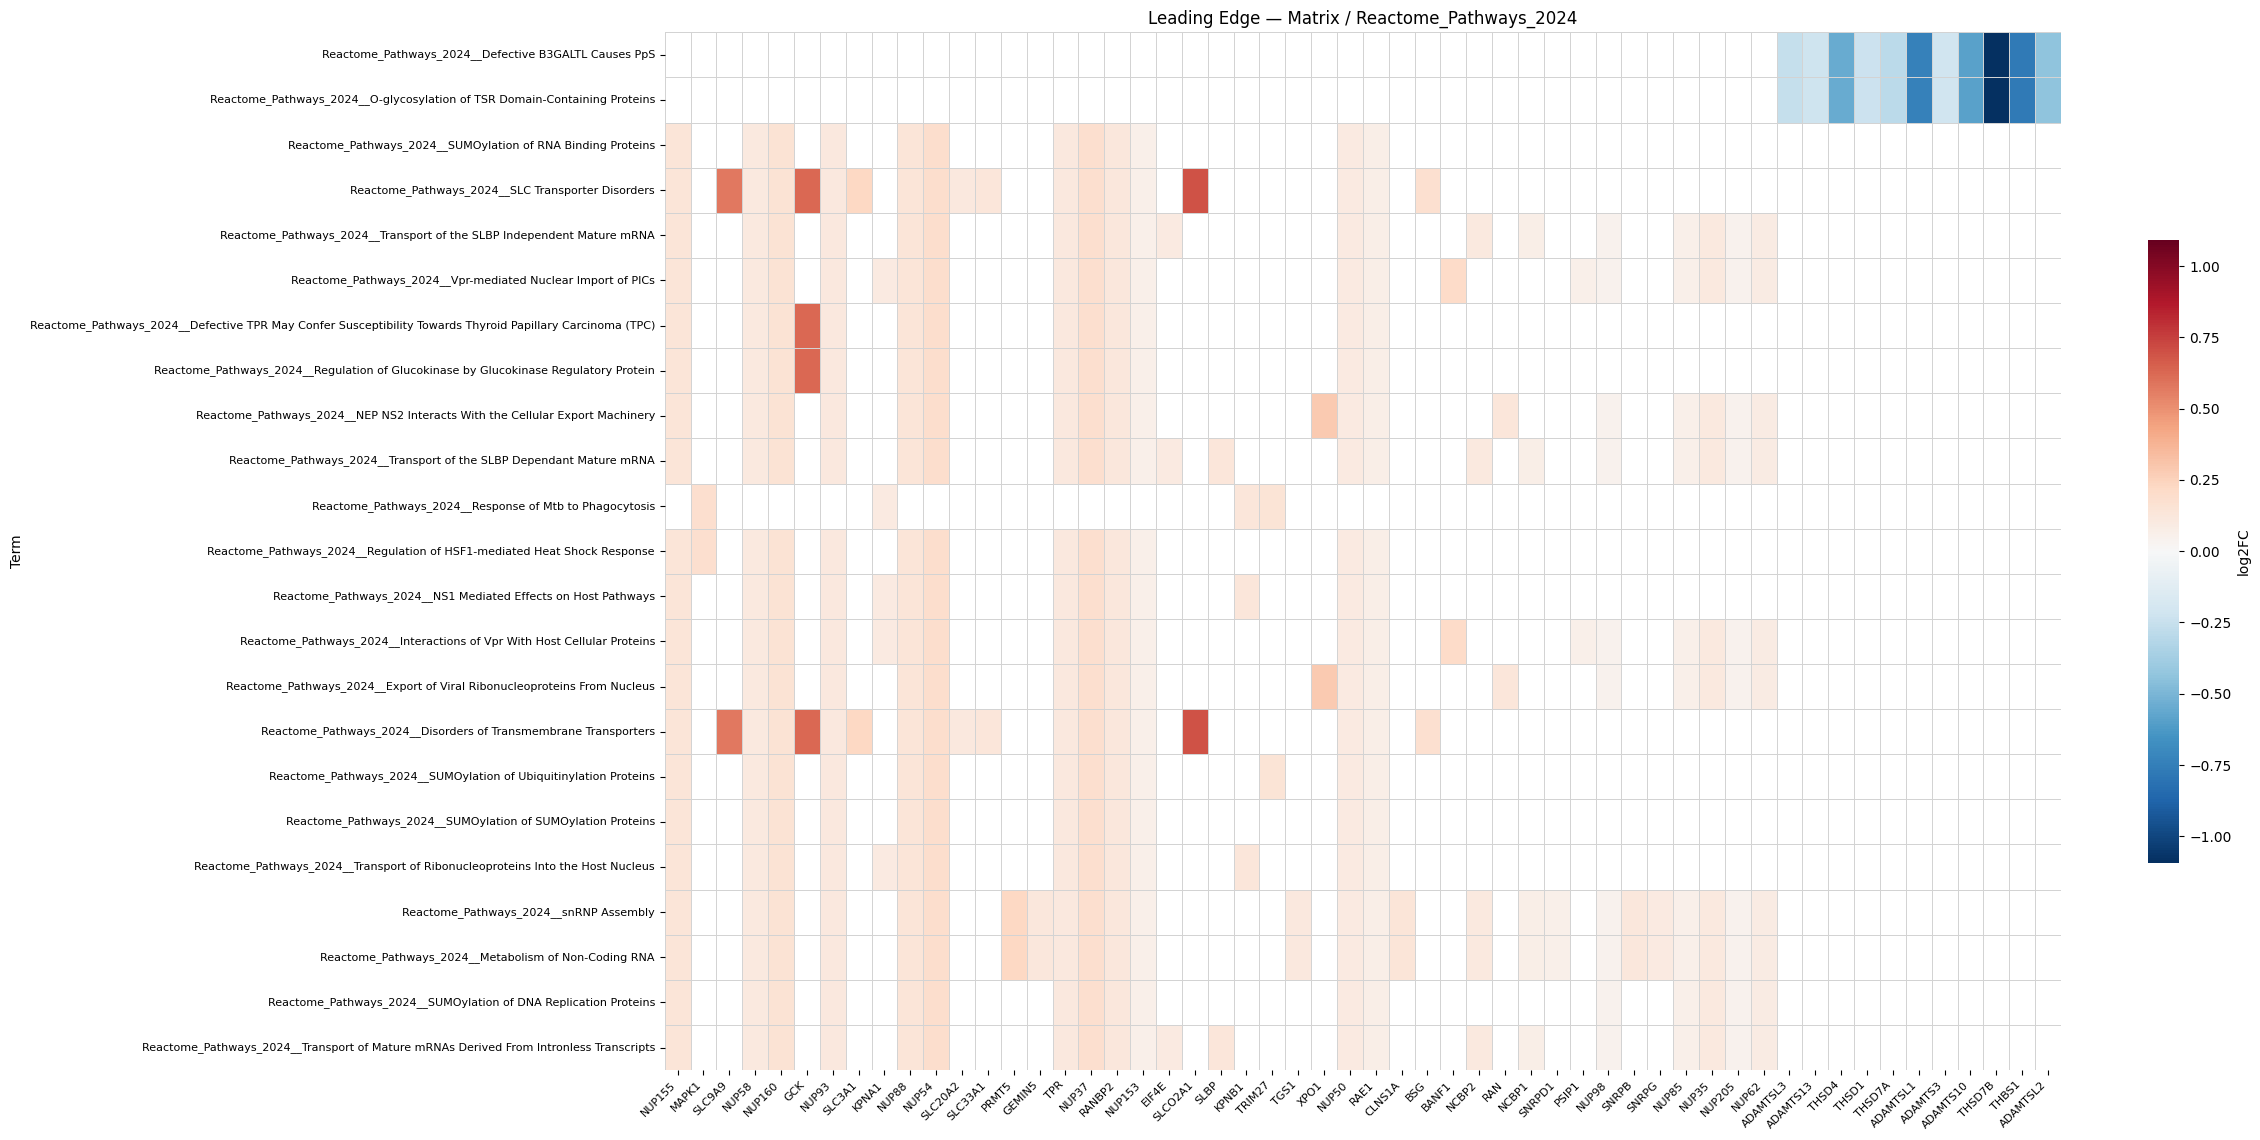

  [collapsed]  23 pathways → 9 clusters


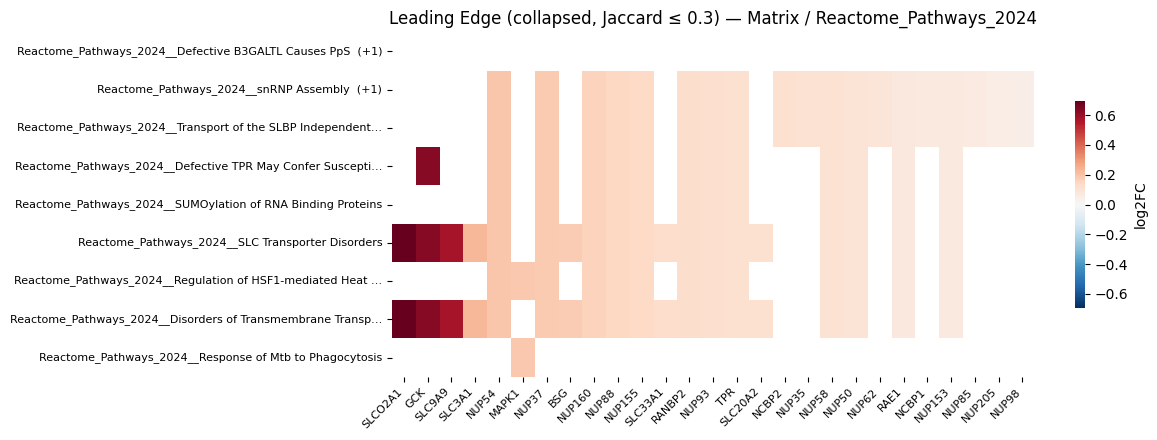


  ──────────────────────────────────────────────────
  GSEA  ▶  GO_Biological_Process_2025
  ──────────────────────────────────────────────────
  [result] 2025 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes


  [plot]   Skipping dotplot — no significant terms

  [leading edge]  GO_Biological_Process_2025
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
  ──────────────────────────────────────────────────
  [result] 33 pathways tested  →  0 significant (FDR ≤ 0.05)


...

  [plot]   Skipping dotplot — no significant terms

  [leading edge]  TRRUST_Transcription_Factors_2019
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  CELL TYPE: Patch


,logFC_(Intercept),logFC_conditionXDP,logFC_age_of_death,logFC_sexM,logFC_pct_counts_mt,logFC_frac_intronic,logFC_cohortCohort_2,logFC_cohortCohort_3,logFC_PC_1,logFC_PC_2,...,p_PC_4,p_PC_5,p_PC_6,p_PC_7,p_PC_8,p_PC_9,p_PC_10,gene_id,gene,z_score
0,-13.297490,0.057210,-0.005992,-0.018441,-0.414015,1.257989,-0.453581,0.006166,-0.006370,-0.018958,...,0.979980,9.423530e-01,0.637507,4.464718e-01,0.646654,2.106191e-01,2.691704e-01,1,ENSG00000238009,0.296839
1,-12.641770,-0.046083,-0.003703,0.060777,-0.170126,0.287935,0.008847,0.192647,-0.009001,-0.003324,...,0.338923,6.712056e-01,0.310058,7.630595e-01,0.188839,8.759372e-01,9.776547e-01,2,ENSG00000241860,-0.358426
2,-13.129381,-0.068010,-0.000126,0.105652,-0.162073,1.577571,0.121464,0.270063,-0.004608,-0.006254,...,0.125278,5.250493e-01,0.581626,4.156803e-01,0.106399,5.236994e-01,6.714154e-01,3,ENSG00000290385,-0.453119
3,-11.203723,-0.084629,0.001167,0.084631,0.005811,-0.643159,-0.097704,0.088342,-0.016695,-0.007865,...,0.152177,2.127951e-01,0.507152,3.999428e-01,0.052036,4.156415e-01,5.433248e-01,4,ENSG00000291215,-0.793845
4,-10.214929,0.060917,-0.000607,-0.045116,0.019450,-2.144166,-0.091449,0.090496,-0.022258,0.000624,...,0.008790,9.353737e-03,0.934465,1.079995e-08,0.863995,5.618889e-26,7.281642e-03,5,LINC01409,0.792549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16819,-11.930053,-0.303638,-0.005746,0.149671,-0.086501,1.656923,-0.287993,-0.016715,-0.000983,-0.006535,...,0.762921,2.733294e-02,0.224504,3.309914e-01,0.165825,2.382793e-02,1.544012e-03,416,ENSG00000276256,-1.481154
16820,-11.536182,0.161781,-0.002994,-0.172221,-0.002925,2.634604,0.010604,-0.071353,-0.011864,0.012125,...,0.988757,3.720974e-01,0.406953,3.392432e-01,0.122369,8.583988e-01,5.922104e-01,417,ENSG00000278384,0.538168
16821,-9.684640,0.083012,-0.000098,-0.123600,-0.055460,0.515835,0.077793,0.190931,-0.024140,-0.012156,...,0.897288,1.431851e-12,0.000031,4.284271e-01,0.000043,1.711483e-05,1.910621e-10,418,ENSG00000273748,0.367649
16822,-12.151837,0.004770,-0.004821,0.083426,-0.033074,-1.735135,0.286640,0.407242,-0.019017,-0.020492,...,0.006431,7.823396e-01,0.230469,1.560198e-01,0.794776,7.092015e-01,3.277836e-01,419,LOC124905564,0.040289


<Axes: xlabel='p_conditionXDP', ylabel='Count'>

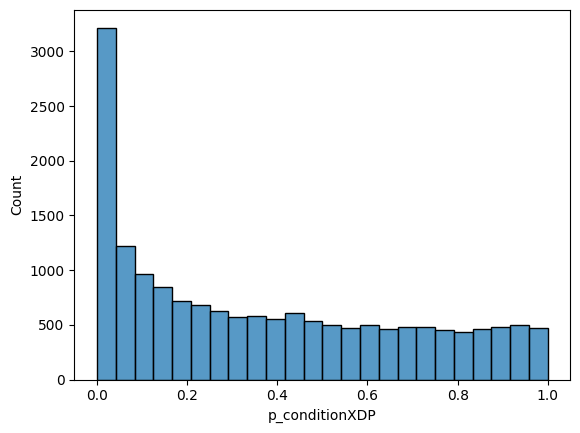

  [filter] Removed 0 genes with extreme intercept logFC (< -20)


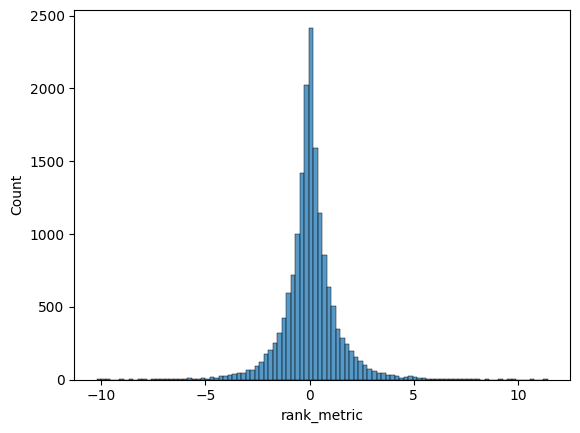

  [rank]   16824 genes in final ranked list (top: GPHN +11.44, bottom: DCHS2 -10.21)


gene
GPHN         11.442965
FNDC3A       10.641774
SETD5         9.903185
SVIL          9.820541
SELENOF       9.596262
               ...    
RTN1         -8.543099
LINC01378    -8.987904
ANKZF1       -9.701202
PFKFB3       -9.812681
DCHS2       -10.212272
Name: rank_metric, Length: 16824, dtype: float64


  ──────────────────────────────────────────────────
  GSEA  ▶  custom
  ──────────────────────────────────────────────────
  [result] 9 pathways tested  →  2 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,PhaseC+_genes,1.946628,0.0,GPHN;USP24;PCNX1;GPATCH2;SEZ6L;MBD5;ARHGAP26;KMT2C;DMTF1;ARIH1;NALCN;KDM5A;PIAS1;REPS1;CDK13;NDFIP1;UTY;RICTOR;ERC1;NSD3;CHM;GLS;UBXN4;MICU3;NEK10;CADPS;LCLAT1;TNRC6C;ARID4B;PRKCI;LINC00632;KIAA0825;PSPC1;CNTNAP2;MAP7;MCF2L2;NUP58;DNM1L;UBR2;UBE2E2;CNTN1;SNHG14;REV3L;ATE1;UBR5;PGAP1;THOC1;KIF3A;JPX;MON2;ATR;ST3GAL5;ZNF609;PAPOLA;DLEU2;PBRM1;SUPT3H;CUL1;MEF2C-AS1;MYCBP2;BRAF;PSIP1;TIA1;CAPN7;BICD1;LINC01473;AKAP13;RTN3;DENND4A;CSMD3;MATR3;PUS7L;ARFGEF3;TRIP12;CCSER1;KMT2E;UPP2;CNOT4;HSPA12A;KIDINS220;FBXO21;USP34;FXR1;RBM5;HNRNPD;NIPBL;RAB11A;GSTA4;ZDHHC20;PPA2;UBN2;SPIN1;HMGN1;INPP4B;BMPR2;INTU;CHL1;NRXN3;DDX5;STOX2;UBR3;SV2B;MIR137HG;FBXW7;MICU1;DYRK1A;STAU2;AAK1;MAP2;LINC00882;STXBP5
1,Gradient_Ventral,1.568948,0.016256,FNDC3A;MEF2A;USP24;MBD5;COL19A1;TMX3;MYO6;NPNT;ZDBF2;GPC6;TUBE1;NALCN;MAN1C1;LAMP5;STAT4;STXBP1;TTC13;SEMA6A;LINC01277;CCDC196;SLC7A2;ZBBX;PRANCR;TARS3;VIPR1;KCTD4;CHM;GLS;PEG10;ARHGAP6;PTPRO;MICU3;ARHGAP12;NKTR;ADCY2;NDN;MBTPS1;GULP1;PRKCI;CPSF6;VASH2;TIAM1;KIAA0825;UBE3A;MTM1;ENSG00000287100;GLDN;USP31;CREG2;ALKAL2;AUH;CFAP43;SEC62;CNTN1;CFLAR;PRKACB;MTRR;ERC2;TSPYL2;SLF1;REV3L;PGAP1;KIF3A;MPDZ;CTNNA2;PRKCA;PPIP5K2;LINC00534;DGKA;TTC28;MYCBP2;GRIA2;ZNF83;ZMAT1;TTLL7;WFS1;VAV3;SUSD4;AKAP13;VSNL1;ETS2;GRHL1;GRK3;HNRNPU;L3MBTL3;JAG1;NAT16;CSMD3;ATP2B4;PRRC2C;LRRK1;GALNTL6;ARFGEF3;MYRIP;UPP2;LUC7L2;RAI2;TUT4;ZNF483;MLXIPL;ENTHD1;LAMC2;KIAA0513;SEMA3E;FXYD6;ARHGAP18;RNF152;ATP8B4;ZFR2;RHBDD2;PPIL4;DNAJC10;SLC25A29;CARHSP1;NRSN1;CADM1;GSTA4;PRDM2;ZNF706;GABRB1;ENSG00000285971;PDYN;ENSG00000288560;HMGN1;COL21A1;CSPP1;INTU;BEX2;TNFAIP8L3;CHL1;DDX5;PAK3;PGRMC1;SFPQ;TOMM20;GIPR;MIR137HG;GTF2F2


/tmp/ipykernel_2794424/3272072167.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0


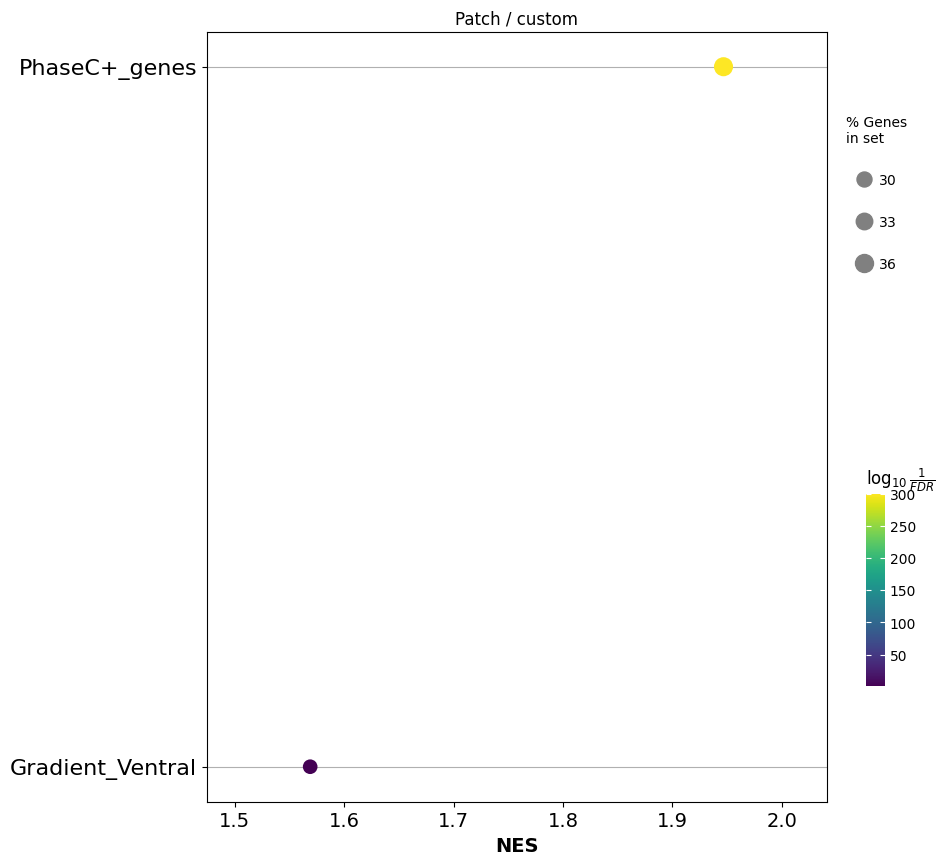


  [leading edge]  custom
  [leading edge]  genes in ≥2 pathways: 23


,gene,n_pathways
0,USP24,2
1,MBD5,2
2,NALCN,2
3,CHM,2
4,GLS,2
5,MICU3,2
6,PRKCI,2
7,KIAA0825,2
8,CNTN1,2
9,REV3L,2


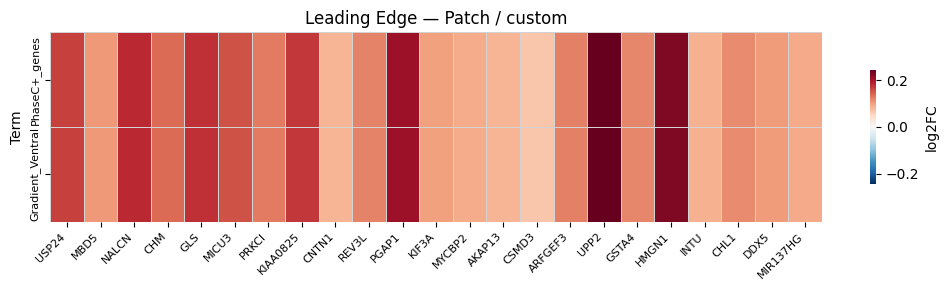

  [collapsed]  2 pathways → 2 clusters


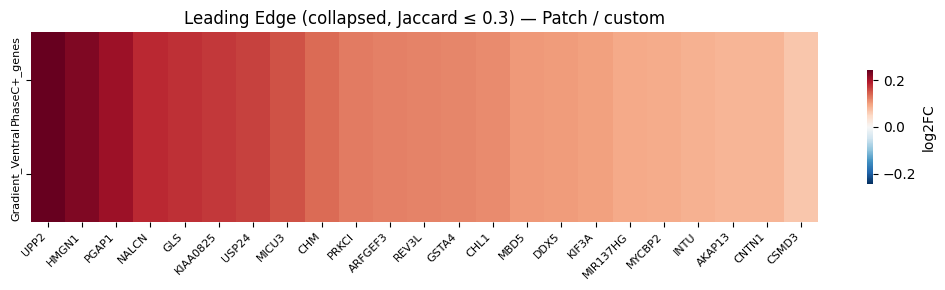


  ──────────────────────────────────────────────────
  GSEA  ▶  MSigDB_Hallmark_2020
  ──────────────────────────────────────────────────
  [result] 50 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,MSigDB_Hallmark_2020__Allograft Rejection,1.820083,0.010257,MAP3K7;HLA-A;INHBA;HDAC9;IFNGR2;IFNGR1;STAT4;RPL39;EIF3A;FLNA;IL16;RPL9;JAK2;RPS3A;IFNAR2;KLRD1;THY1;PSMB10;CD47


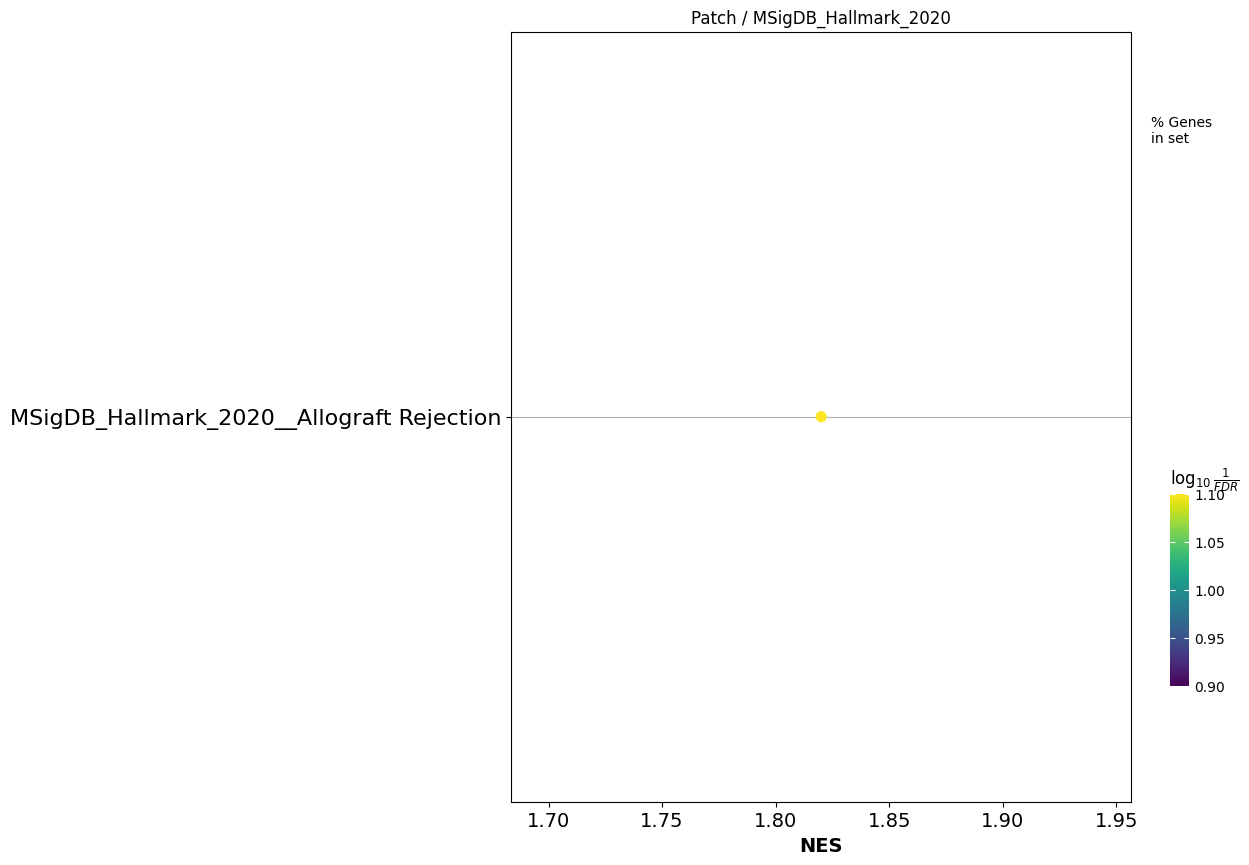


  [leading edge]  MSigDB_Hallmark_2020
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  SynGO_2024
  ──────────────────────────────────────────────────
  [result] 54 pathways tested  →  5 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,2.270167,0.0,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL31;RPS3;RPS28;RPS24;RPL7;RPS21
1,SynGO_2024__Presynaptic Ribosome CC,2.214447,0.0,RPL4;RPL35A;RPL5;RPS6;RPL37;RPL10A;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPL29;RPL38;RPL24;RPL22;RPL17;RPS13;RPL34;RPL23;RPL12;RPS28;RPS24;RPL7
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.18118,0.0,RPL4;RPL35A;RPL5;RPL37;RPL10A;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPL29;RPL38;RPL24;RPL22;RPL17;RPS13;RPL34;RPL23;RPL12;RPS28;RPS24;RPL7
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.168582,0.0,RPL4;RPL35A;RPL5;RPL37;RPL10A;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPL29;RPL38;RPL24;RPL22;RPL17;RPS13;RPL34;RPL23;RPL12;RPS28;RPS24;RPL7
5,SynGO_2024__Synaptic Vesicle Proton Loading (GO:0097401) BP,1.671623,0.03004,ATP6AP2;ATP6V1E1;ATP6V1H


/tmp/ipykernel_2794424/3272072167.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0


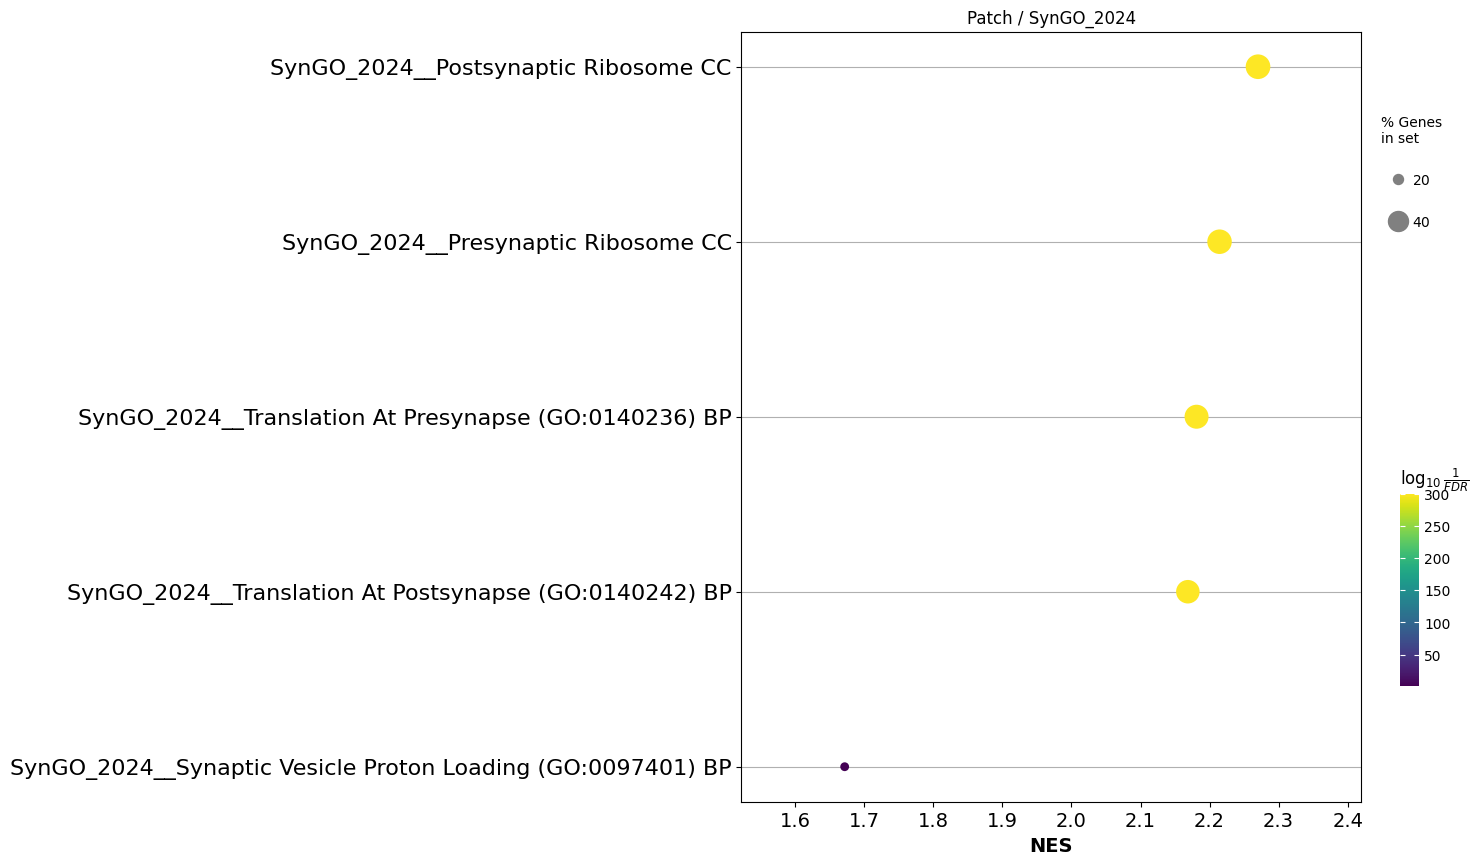


  [leading edge]  SynGO_2024
  [leading edge]  genes in ≥2 pathways: 25


,gene,n_pathways
0,RPL4,4
1,RPL35A,4
2,RPL5,4
3,RPL37,4
4,RPL10A,4
5,RPS27,4
6,RPL15,4
7,RPL26,4
8,RPS15A,4
9,RPL32,4


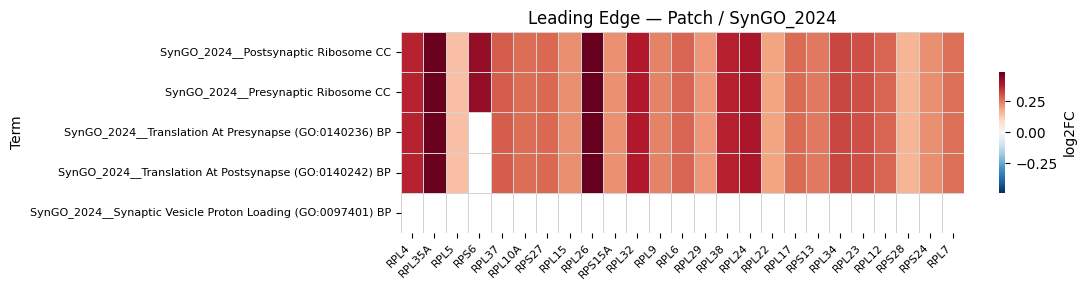

  [collapsed]  5 pathways → 2 clusters
  [collapsed]  No recurring genes after collapsing — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  Reactome_Pathways_2024
  ──────────────────────────────────────────────────
  [result] 1108 pathways tested  →  30 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,Reactome_Pathways_2024__Viral mRNA Translation,2.201001,0.0,RPL4;GRSF1;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;RPS28;RPS24;RPL7
1,Reactome_Pathways_2024__Peptide Chain Elongation,2.200456,0.0,RPL4;EEF1A1;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;RPS28;RPS24;RPL7
2,Reactome_Pathways_2024__SRP-dependent Cotranslational Protein Targeting to Membrane,2.17625,0.0,SSR1;RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;SRP54;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;SSR3;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;SEC61A2;RPS28;RPS24;RPL7;RPS21;SRP72
3,Reactome_Pathways_2024__Eukaryotic Translation Elongation,2.160336,0.0,RPL4;EEF1A1;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;EEF1B2;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;RPS28;RPS24;RPL7
4,Reactome_Pathways_2024__Selenocysteine Synthesis,2.147846,0.0,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;SARS1;RPS28;RPS24;RPL7;RPS21
8,Reactome_Pathways_2024__GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,2.114695,0.000136,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;EIF3A;RPL15;RPL26;EIF4E;RPS15A;RPL32;RPL9;RPL6;EIF3H;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;EIF4B;RPS3;RPS28;RPS24;RPL7;EIF3J;RPS21;EIF4A2
7,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.119858,0.000153,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;EIF3A;RPL15;RPL26;EIF4E;RPS15A;RPL32;RPL9;RPL6;EIF3H;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;EIF4B;RPS3;RPS28;RPS24;RPL7;EIF3J;RPS21;EIF4A2
6,Reactome_Pathways_2024__Formation of a Pool of Free 40S Subunits,2.12937,0.000174,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPL22L1;RPS27;EIF3A;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;EIF3H;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;RPS28;RPS24;RPL7;EIF3J;RPS21
5,Reactome_Pathways_2024__Response of EIF2AK4 (GCN2) to Amino Acid Deficiency,2.14175,0.000203,RPL4;RPL35A;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;EIF2AK4;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;IMPACT;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;RPS28;RPS24;RPL7
13,Reactome_Pathways_2024__Selenoamino Acid Metabolism,2.032151,0.000436,RPL4;IARS1;RPL35A;RPL5;RPS6;RPS7;CTH;RPL37;RPL10A;EPRS1;RPL39;RPS4X;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL24;RPL22;RPS3A;RPS25;RPL17;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;SARS1;RPS28;RPS24;RPL7;RPS21;DARS1


/tmp/ipykernel_2794424/3272072167.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0


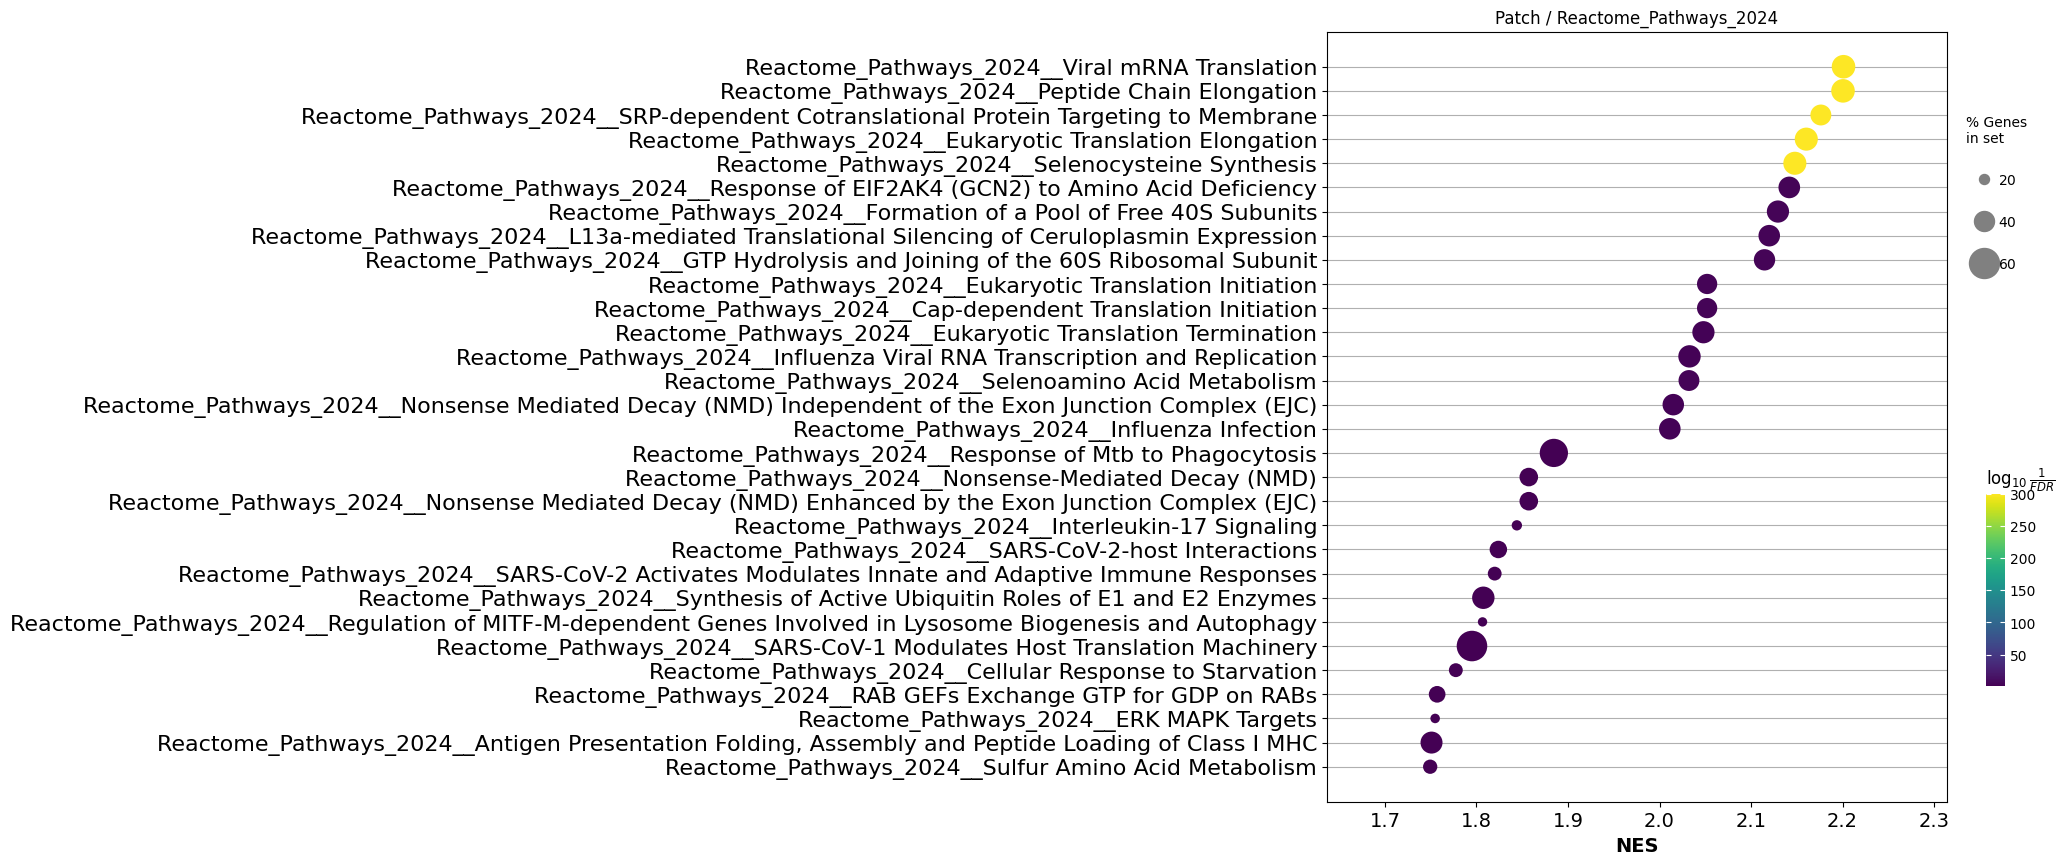


  [leading edge]  Reactome_Pathways_2024
  [leading edge]  genes in ≥2 pathways: 103


,gene,n_pathways
0,RPS6,21
1,RPS7,21
2,RPS4X,21
3,RPS27,21
4,RPS15A,21
...,...,...
98,IFNAR2,2
99,YWHAE,2
100,SEC23A,2
101,ATG14,2


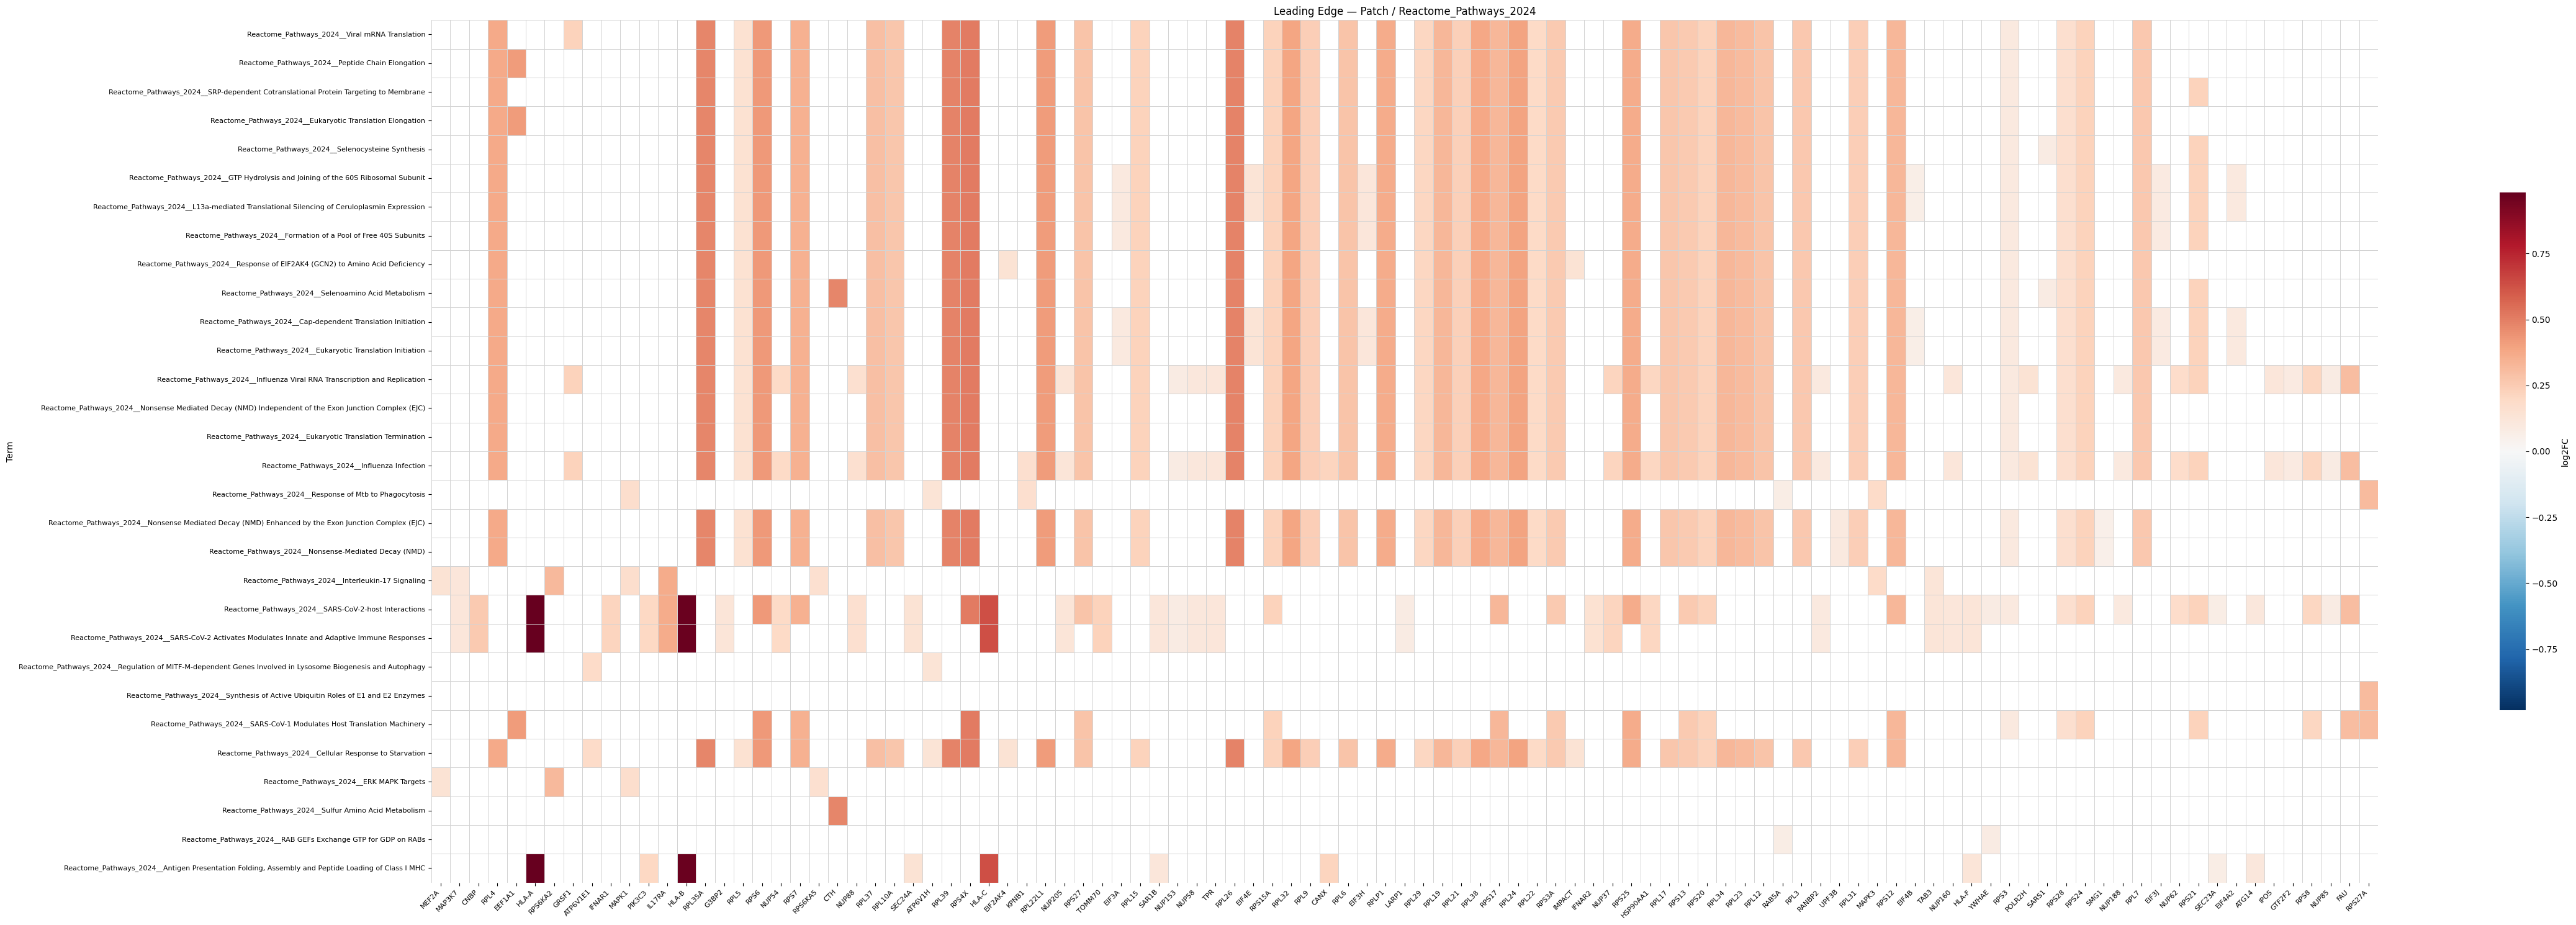

  [collapsed]  30 pathways → 13 clusters


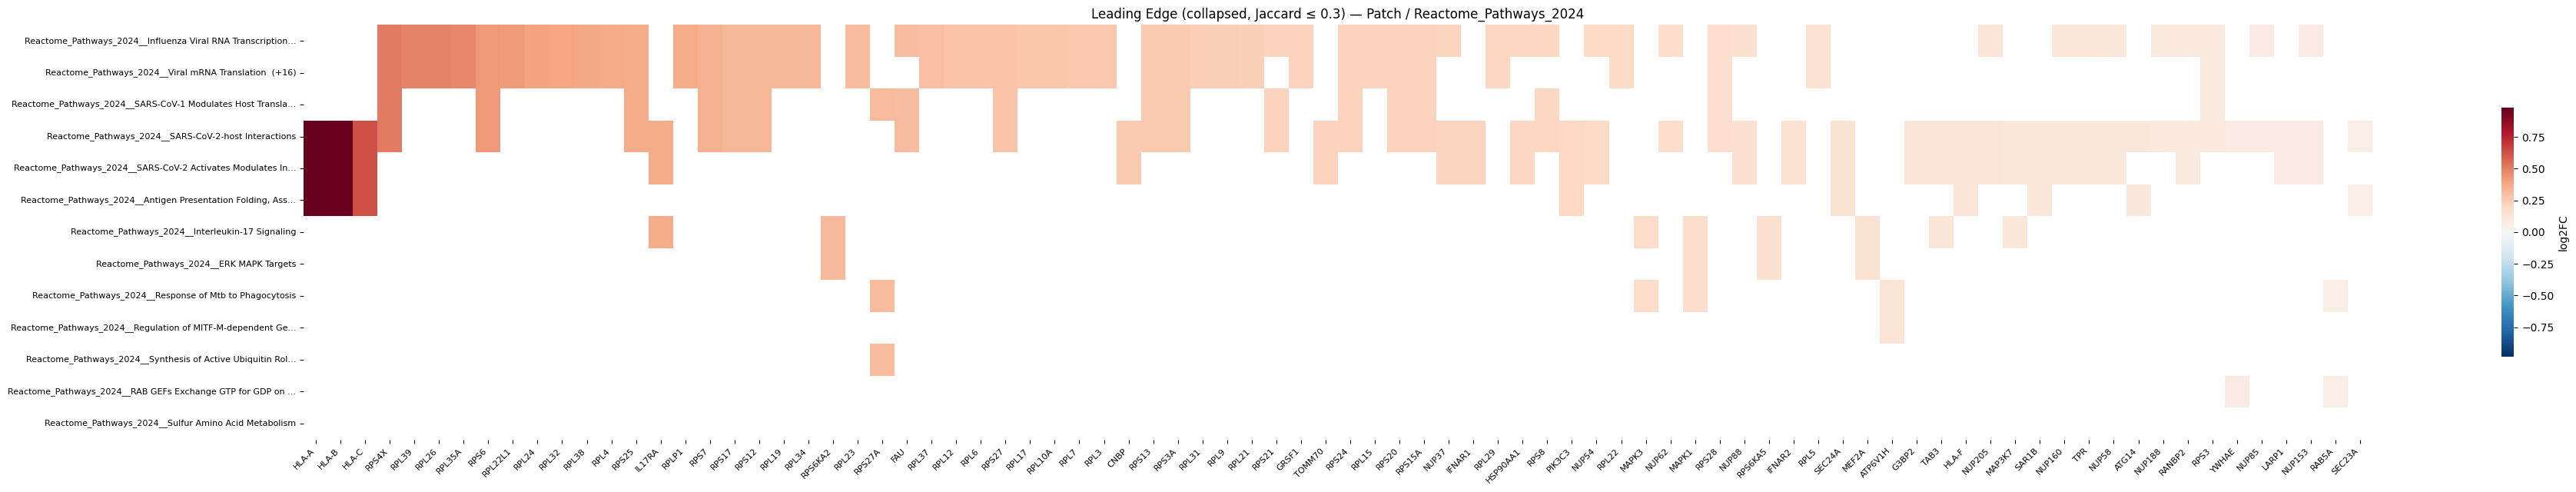


  ──────────────────────────────────────────────────
  GSEA  ▶  GO_Biological_Process_2025
  ──────────────────────────────────────────────────
  [result] 1847 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.153024,0.002343,RPL4;RPL35A;ZC3H15;RPL5;RPS6;RPS7;RPL37;RPL10A;RPL39;RPS4X;RPSA2;RPL22L1;RPS27;RPL15;RPL26;RPS15A;RPL32;RPL9;RPL6;RPLP1;RPL29;RPL19;RPL21;RPL38;RPS17;RPL22;RPS3A;RPS25;RPS13;RPS20;RPL34;RPL23;RPL12;RPL3;RPL31;RPS12;RPS3;SARS1;RPS28;RPS24;RPL7;RPS21;EIF4A2


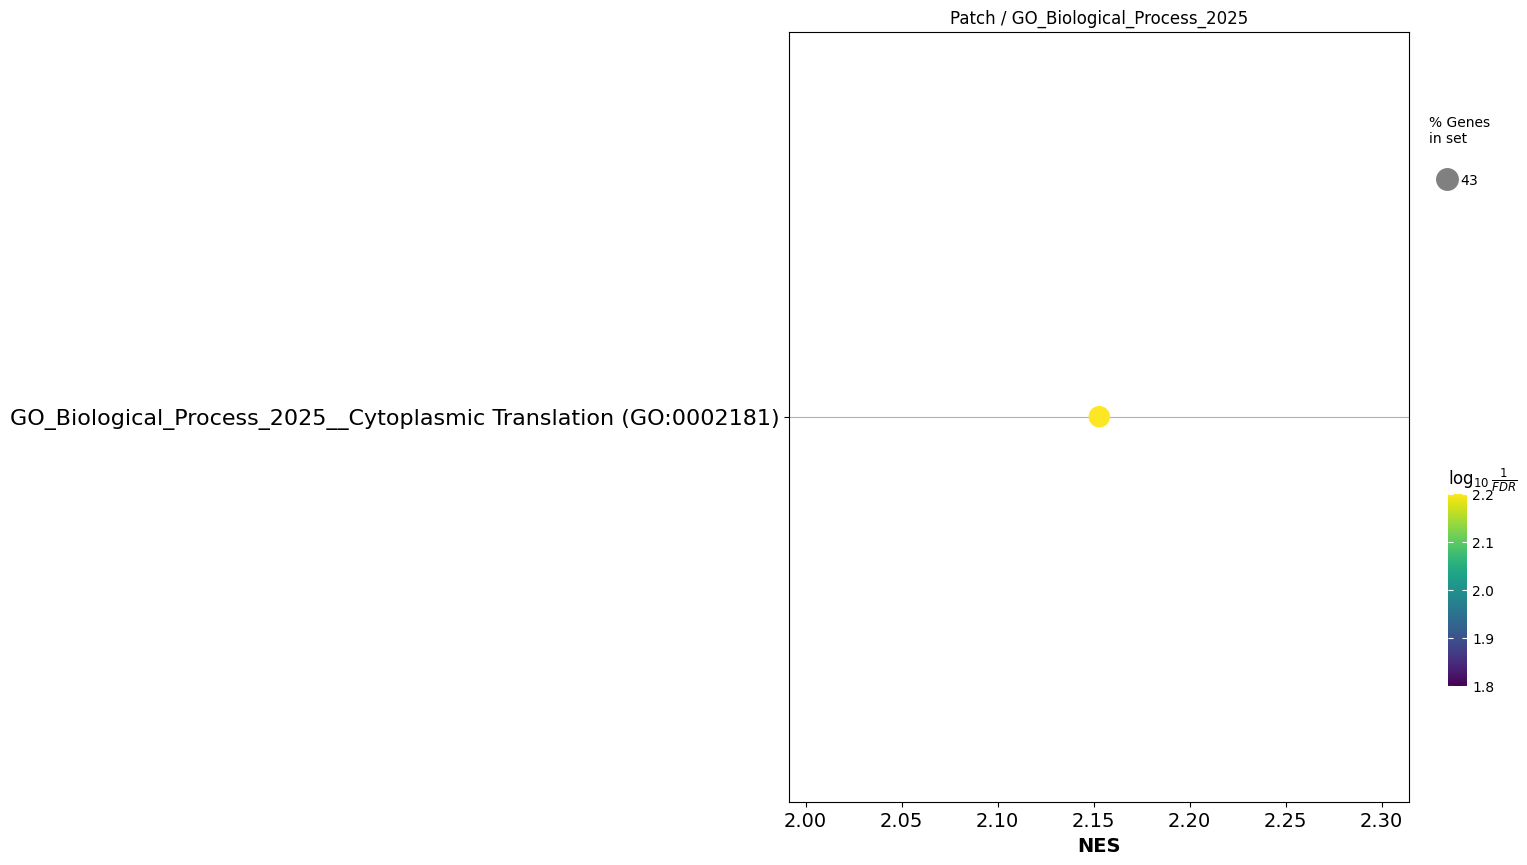


  [leading edge]  GO_Biological_Process_2025
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
  ──────────────────────────────────────────────────
  [result] 34 pathways tested  →  2 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes
0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__KAT2A ENCODE,1.870528,0.002707,RPL4;NACA;RPL5;RPS6;RPS7;RPL37;UBAC2;RPL15;RPL32;RPL9;RPL6;RPL29;RBM26;RPL24;RPL34;HSP90B1;RPL12;KDM5C;ZNFX1;RPL31;PTMA;RPS3;NUP62;SNHG9;EEF1G;RPS8;EGR1;LIAS;CSNK1D;RPL27;RPL18
1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__FOSL2 ENCODE,1.639227,0.022331,PPP2R5B;PSME4;SLC20A1;LINC01011;LINC00862;RBM25;TMEM245;JAK2;ZMYND11;CYFIP1;DPP9;BTBD19;KCTD20;ENO1;TUBB3;KLHL41;SERPINB8;EFNA1;RIN1;DHX32;REPIN1;DSTN;STX3;TCEANC;GNG5


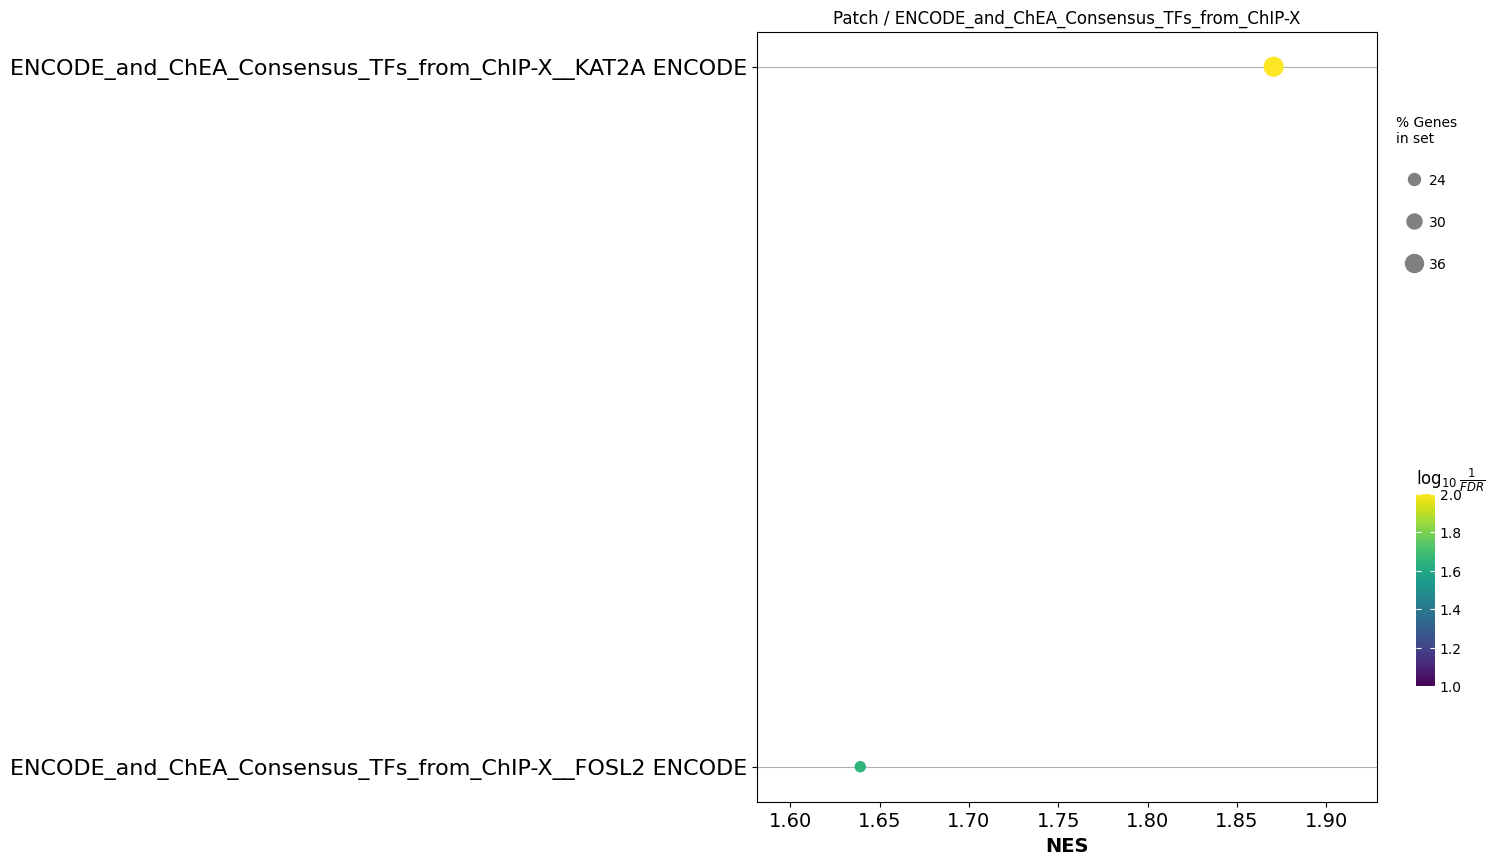


  [leading edge]  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap

  ──────────────────────────────────────────────────
  GSEA  ▶  TRRUST_Transcription_Factors_2019
  ──────────────────────────────────────────────────
  [result] 80 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val,Lead_genes


  [plot]   Skipping dotplot — no significant terms

  [leading edge]  TRRUST_Transcription_Factors_2019
  [leading edge]  genes in ≥2 pathways: 0


,gene,n_pathways


  [leading edge]  No recurring genes — skipping heatmap


In [11]:
import shutil


THR_FDR_GSEA=0.05

THR_FDR_ORA = 0.05   # FDR threshold for significant ORA terms
THR_FDR_DEG = 0.05   # FDR threshold for calling a gene a DEG (input to ORA)
THR_LOGFC   = 0.50   # |logFC| threshold for calling a gene a DEG

for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

    #ct="Astrocyte"  
    print(f"\n{'='*60}\n  CELL TYPE: {ct}\n{'='*60}")

    # file wiht deg results
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka

    if not os.path.exists(save_csv_path):
        print(f"  [ERROR] Missing results file: {save_csv_path}")
        continue

    # Save folder
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "gsea_on_degs")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)   # wipe all existing contents
    os.makedirs(img_dir, exist_ok=True)  # create output folder

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)

    #ATTENTION: beofre chage logfc
    df_nebula["z_score"] = df_nebula[LOGFC_COL] / df_nebula[SE_COL]  # Wald z

    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)  # ln → log2

    display(df_nebula); plt.show()
    display(sns.histplot(df_nebula, x=PVAL_COL)); plt.show()


    #########
    ### GSEA
    ##########

    # sereis for GSE, df for other analyssi
    ranked_series, df_rank = from_deg_df_to_df_rank(df_nebula, GENE_COL=GENE_COL, PVAL_COL=PVAL_COL, LOGFC_COL=LOGFC_COL, REMOVE_GENE_TOO_HIGH_INTERCEPT=REMOVE_GENE_TOO_HIGH_INTERCEPT, REMOVE_RIBO_GENES_FROM_GSEA=REMOVE_RIBO_GENES_FROM_GSEA,
                        score_col=None,)

    print(f"  [rank]   {len(ranked_series)} genes in final ranked list (top: {ranked_series.index[0]} {ranked_series.iloc[0]:+.2f}, bottom: {ranked_series.index[-1]} {ranked_series.iloc[-1]:+.2f})")
    display(ranked_series)

    #each database is corrected only against itself, and a real signal in Hallmark isn't penalized by the 7,000 GO terms
    #The tradeoff is that you can't directly compare FDR values across databases 
    for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:

        try:

            print(f"\n  {'─'*50}")
            print(f"  GSEA  ▶  {db_name}")
            print(f"  {'─'*50}")
            # ES --> enriuchemnt score
            # NES -->romalised ES --> by gene set size
            # ignificance is assessed by randomly permuting the gene order --> creating nulld sitruvtion
            pre_res = gp.prerank(
                rnk=ranked_series,
                gene_sets=gene_sets,
                seed=42,
                permutation_num=1000,
                min_size=min_s, #if fewer than 10 genes in the set are present in your data, skip it.
                max_size=max_s, #if more than 500 genes in the set overlap your data, skip it
                verbose=False,
                threads=30#24
            )

            # df gsea
            df_gsea = pre_res.res2d.copy()
            df_gsea = df_gsea.sort_values("FDR q-val")

            # Selct only signficant pathways
            df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy() # no NES direction filtering, both nge and psoo

            # save full + significant results (mirrors factor GSEA saving)
            df_gsea.to_csv(    f"{img_dir}/{db_name}_gsea_all.csv", index=False)
            df_gsea_sig.to_csv(f"{img_dir}/{db_name}_gsea_sig.csv", index=False)

            print(f"  [result] {len(df_gsea)} pathways tested  →  {len(df_gsea_sig)} significant (FDR ≤ {THR_FDR_GSEA})")

            # 
            with pd.option_context('display.max_colwidth', None):
                display(df_gsea_sig[["Term", "NES", "FDR q-val", "Lead_genes"]])

            # Summary dotplot
            if len(df_gsea_sig) == 0:
                print(f"  [plot]   Skipping dotplot — no significant terms")
            else:

                # Dotplot: size = gene ratio, color = FDR
                try:
                    res2d_plot = df_gsea.copy()
                    res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0
                    dotplot(
                        res2d_plot,
                        column="FDR q-val",      # color axis
                        #title="Hallmark pathways",
                        cmap=plt.cm.viridis,
                        size=6,
                        figsize=(10, 10),
                        cutoff=THR_FDR_GSEA,  # only show terms below this FDR
                        show_ring=False,
                        ofname=None, # image saving apth
                        top_term=len(df_gsea_sig),   # ← show all that pass the cutoff
                    )
                    plt.title(f"{ct} / {db_name}")
                    plt.savefig(f"{img_dir}/{db_name}_dotplot.png", dpi=150, bbox_inches="tight")
                    plt.show()
                    plt.close()
                except Exception as plot_err:
                    print(f"  [plot]   Dotplot failed ({plot_err}), results already saved to CSV")


            #######################
            ### Leading Edge Analysis
            #######################

            print(f"\n  [leading edge]  {db_name}")

            # which specific genes in the gene set are actually driving the enrichment?
            # gene set that appear before the peak of the enrichment score in the ranked list.

            # ── 1. Parse leading edge genes ───────────────────────────────────────────

            # form signficnat apthways
            # leecte teh elading genes (need to be parsed for  df col)
            df_gsea_sig["lead_genes"] = (
                df_gsea_sig["Lead_genes"]
                .str.split(";")
                .apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])
            )
            df_gsea_sig["n_lead"] = df_gsea_sig["lead_genes"].apply(len)

            # # print df (note LEADING GENE already there)
            # with pd.option_context("display.max_colwidth", None):
            #     display(df_gsea_sig[["Term", "NES", "FDR q-val", "Tag %", "n_lead", "Lead_genes"]])

            # ── 2. Genes recurring across ≥2 pathways → highest-confidence hits ───────
            gene_freq = Counter(g for genes in df_gsea_sig["lead_genes"] for g in genes)
            df_gene_freq = pd.DataFrame(gene_freq.most_common(), columns=["gene", "n_pathways"])
            print(f"  [leading edge]  genes in ≥2 pathways: {(df_gene_freq['n_pathways'] > 1).sum()}")
            display(df_gene_freq[df_gene_freq["n_pathways"] > 1])

            # save leading edge frequency table
            df_gene_freq.to_csv(f"{img_dir}/{db_name}_leading_edge_freq.csv", index=False)

            # ── 3. Heatmap: pathways × recurring genes ────────────────────────────────
            # Color  = logFC  →  red = up, blue = down
            # X-axis = genes ordered by DEG rank metric (most up → most down)

            recurring_genes = df_gene_freq[df_gene_freq["n_pathways"] > 1]["gene"].tolist()

            if not recurring_genes:
                print("  [leading edge]  No recurring genes — skipping heatmap")
            else:
                # order genes by rank metric (most up → most down), same order as GSEA list
                gene_order = (
                    df_rank.set_index(GENE_COL)["rank_metric"]
                    .loc[lambda s: s.index.isin(recurring_genes)]
                    .sort_values(ascending=False).index.tolist()
                )

                # logFC if gene in leading edge, NaN (→ grey) otherwise
                matrix = pd.DataFrame(np.nan, index=df_gsea_sig["Term"], columns=gene_order)
                for _, row in df_gsea_sig.iterrows():
                    for gene in set(row["lead_genes"]) & set(gene_order):
                        matrix.loc[row["Term"], gene] = df_rank.set_index(GENE_COL).loc[gene, LOGFC_COL]

                vmax = np.nanmax(np.abs(matrix.values))
                fig, ax = plt.subplots(figsize=(max(8, len(gene_order)*0.45), max(3, len(matrix)*0.5)))
                sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                            linewidths=0.5, linecolor="lightgrey",
                            cbar_kws={"label": "log2FC", "shrink": 0.6}, ax=ax)
                ax.set_title(f"Leading Edge — {ct} / {db_name}")
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
                ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
                plt.tight_layout()
                plt.savefig(f"{img_dir}/{db_name}_leading_edge_heatmap.png", dpi=150, bbox_inches="tight")
                plt.show(); plt.close(fig)


#########################################
                # ── 4. Collapsed heatmap: cluster redundant pathways by leading-edge Jaccard ──
                from scipy.cluster.hierarchy import linkage, fcluster
                from scipy.spatial.distance import squareform

                JACCARD_DIST_CUTOFF = 0.3  # = 0.7 similarity; lower → more aggressive collapsing

                if len(df_gsea_sig) < 2:
                    print("  [collapsed]  <2 pathways — nothing to collapse")
                else:
                    # pairwise Jaccard distance between leading-edge sets
                    lead_sets = [set(g) for g in df_gsea_sig["lead_genes"]]
                    n = len(lead_sets)
                    dist = np.zeros((n, n))
                    for i in range(n):
                        for j in range(i + 1, n):
                            u = len(lead_sets[i] | lead_sets[j])
                            dist[i, j] = dist[j, i] = 1 - len(lead_sets[i] & lead_sets[j]) / u if u else 1.0

                    clusters = fcluster(linkage(squareform(dist), method="average"),
                                        t=JACCARD_DIST_CUTOFF, criterion="distance")
                    df_gsea_sig = df_gsea_sig.assign(cluster=clusters)

                    # representative per cluster = best FDR, then largest |NES|
                    reps = (df_gsea_sig
                            .sort_values(["FDR q-val", "NES"], key=lambda s: s.abs() if s.name == "NES" else s,
                                        ascending=[True, False])
                            .groupby("cluster", as_index=False).first())

                    # member-count annotation (how many pathways each rep absorbed)
                    sizes = df_gsea_sig.groupby("cluster").size()
                    reps["Term"] = reps.apply(lambda r: f"{r['Term']}  (+{sizes[r['cluster']]-1})"
                                            if sizes[r['cluster']] > 1 else r["Term"], axis=1)

                    print(f"  [collapsed]  {len(df_gsea_sig)} pathways → {len(reps)} clusters")
                    #reps.to_csv(f"{img_dir}/{db_name}_gsea_collapsed.csv", index=False)

                    # recurring genes within the collapsed set
                    rep_gene_freq = Counter(g for genes in reps["lead_genes"] for g in genes)
                    rec_genes = [g for g, n in rep_gene_freq.items() if n > 1]

                    if not rec_genes:
                        print("  [collapsed]  No recurring genes after collapsing — skipping heatmap")
                    else:
                        logfc = df_rank.set_index(GENE_COL)[LOGFC_COL]  # precomputed
                        gene_order = logfc.loc[logfc.index.isin(rec_genes)].sort_values(ascending=False).index.tolist()

                        matrix = pd.DataFrame(np.nan, index=reps["Term"], columns=gene_order)
                        for _, row in reps.iterrows():
                            for g in set(row["lead_genes"]) & set(gene_order):
                                matrix.loc[row["Term"], g] = logfc[g]

                        # truncate long Reactome names
                        matrix.index = [t if len(t) < 60 else t[:57] + "…" for t in matrix.index]

                        vmax = np.nanmax(np.abs(matrix.values))
                        fig, ax = plt.subplots(figsize=(max(8, len(gene_order)*0.45),
                                                        max(3, len(matrix)*0.5)))
                        sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                                    linewidths=0, cbar_kws={"label": "log2FC", "shrink": 0.6}, ax=ax)
                        ax.set_title(f"Leading Edge (collapsed, Jaccard ≤ {JACCARD_DIST_CUTOFF}) — {ct} / {db_name}")
                        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
                        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
                        plt.tight_layout()
                        #plt.savefig(f"{img_dir}/{db_name}_leading_edge_heatmap_collapsed.png",
                        #            dpi=150, bbox_inches="tight")
                        plt.show(); plt.close(fig)


#######################################à




        except Exception as e:
            print(f"  [ERROR]  GSEA failed for {ct} / {db_name}: {e}")

    #break

    # #########
    # ### ORA
    # ##########
    # ### ORA — Over-Representation Analysis (fully local)
    # # Hypergeometric test: are my significant DEGs over-represented in a pathway?

    # print(f"\n  {'='*50}")
    # print(f"  ORA  ▶  {ct}")
    # print(f"  {'='*50}")

    # ora_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "ora_on_degs")
    # if os.path.exists(ora_dir): shutil.rmtree(ora_dir)
    # os.makedirs(ora_dir)

    # # background = genes in the ranking (ribo-filtered if applicable)
    # background = ranked_series.index.tolist()

    # # recompute adj p-values on df_rank (already filtered, consistent with background)
    # df_rank["adj_pvalue"] = multipletests(df_rank[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]

    # # restrict DEGs to genes in background (foreground must be subset of background)
    # df_bg    = df_rank[df_rank[GENE_COL].isin(background)]
    # sig_up   = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] >  THR_LOGFC)][GENE_COL].tolist()
    # sig_down = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] < -THR_LOGFC)][GENE_COL].tolist()
    # print(f"  [DEGs]   {len(sig_up)} up  |  {len(sig_down)} down  |  background: {len(background)} genes")

    # for direction, gene_list in [("up", sig_up), ("down", sig_down)]:

    #     if len(gene_list) < 5:
    #         print(f"  [ORA {direction}]  Too few DEGs ({len(gene_list)} < 5) — skipping"); continue

    #     for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:
    #         try:
    #             enr        = gp.enrich(gene_list=gene_list, gene_sets=gs_dict, background=background,
    #                                    outdir=None, no_plot=True, verbose=False)
    #             df_ora     = enr.res2d.sort_values("Adjusted P-value")
    #             df_ora_sig = df_ora[df_ora["Adjusted P-value"] <= THR_FDR_ORA]

    #             df_ora.to_csv(    f"{ora_dir}/ORA_{direction}_{db_name}_all.csv", index=False)
    #             df_ora_sig.to_csv(f"{ora_dir}/ORA_{direction}_{db_name}_sig.csv", index=False)
    #             print(f"  [ORA {direction}]  {db_name}:  {len(df_ora)} tested  →  {len(df_ora_sig)} significant (FDR ≤ {THR_FDR_ORA})")
    #             with pd.option_context("display.max_colwidth", None):
    #                 display(df_ora_sig[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(10))

    #             if df_ora_sig.empty: continue
    #             try:
    #                 dotplot(enr.res2d, column="Adjusted P-value", cutoff=THR_FDR_ORA, top_term=20,
    #                         figsize=(8, max(3, len(df_ora_sig)*0.35)),
    #                         title=f"ORA {direction} — {ct} / {db_name}",
    #                         cmap=plt.cm.viridis, show_ring=False, marker="o")
    #                 plt.savefig(f"{ora_dir}/ORA_{direction}_{db_name}_dotplot.png", dpi=150, bbox_inches="tight")
    #                 plt.show(); plt.close()
    #             except Exception as e:
    #                 print(f"  [plot]   ORA dotplot failed: {e}")

    #         except Exception as e:
    #             print(f"  [ERROR]  ORA {direction} / {db_name} failed: {e}")

            
    #break  # DEBUG: remove to run all cell types

# GSEA on Factors

In [9]:
#Addtionla short path to test

small_curated_pathways = {
    "Oligodendrocyte_WM":                ["OPALIN"],
    "Oligodendrocyte_GM":                ["PLEKHG1"],
    "Oligodendrocyte_Reactive":          ["FRY", "BCAS1", "HSPA1A"],
    "Oligodendrocyte_Cortisol":          ["FKBP5", "TSC22D3", "SGK1"],

    "Astrocyte_WM":                      ["GFAP", "CRYAB", "VIM"],
    "Astrocyte_GM":                      ["SLC1A2", "SLC1A3", "GJA1", "ALDH1L1"],
    "Astrocyte_A1_Reactive":             ["C3", "SERPING1", "SERPINA3", "GBP2", "SRGN", "AMIGO2"],
    "Astrocyte_A2_Antiinflammatory":     ["S100A10", "PTX3", "EMP1", "CD14", "SPHK1"],
    "Astrocyte_Cortisol":                ["FKBP5", "TSC22D3", "SGK1"],

    "Microglia_Homeostatic":             ["CX3CR1", "P2RY12", "TMEM119", "HEXB", "CSF1R"],
    "Microglia_DAM":                     ["GPNMB", "TREM2", "SPP1", "LPL", "CD9", "APOE"],

    "General_Mito":                      ["MT-CO1", "MT-CO2", "MT-ND1", "MT-ND3", "MT-ATP6", "MT-CYB"],
    "General_Housekeeping":              ["GAPDH", "ACTB", "B2M"],
    "General_Cortisol":                  ["FKBP5", "TSC22D3", "SGK1", "PER1", "ZBTB16"],
    "General_Hypoxia":                   ["HIF1A", "VEGFA", "LDHA", "SLC2A1"],
    "General_Stress_HSP":                ["HSPA1A", "HSPA1B", "HSPB1", "HSP90AA1", "DNAJB1"],
    "General_CellCycle":                 ["MKI67", "CENPA", "TOP2A", "PCNA", "CDK1", "MCM2"],
    "General_lncRNA":                    ["MALAT1", "NEAT1", "XIST"],
    "General_ImmediateEarlyGenes":       ["FOS", "JUN", "ARC", "FOSB", "JUNB", "EGR1", "NPAS4"],

    "Oligodendrocyte_Markers":           ["MOG", "OLIG1", "OPALIN", "MBP", "PLP1", "CNP", "LGALS1", "PALM2"],
    "Astrocyte_Markers":                 ["GFAP", "AQP4", "ALDH1L1", "S100B", "SOX9", "SLC1A2"],
    "Microglia_Markers":                 ["C1QA", "C1QB", "CX3CR1", "P2RY12", "TREM2", "TMEM119", "AIF1", "CSF1R", "HEXB"],

    "Striosome_Markers":                 ["OPRM1", "FOXP2", "TSHZ1"],
    "Matrix_Markers":                    ["CALB1", "EBF1"],

}

In [43]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="gseapy")


In [ ]:
# Run only for factors
if TYPE_DEG in ["PCA_nebula", "cNMF_nebula"]:

    THR_FDR_GSEA=0.05  # FDR threshold for significant GSEA terms

    for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

        # if ct != "Matrix_D1":  # DEBUG: run only one cell type for now
        #     continue

        print(f"\n{'='*60}\n  CELL TYPE: {ct}\n{'='*60}")

        # 1. Load the factor × gene matrix
            # ATTENTION NUMBER OF GENES IS THE ONE USED TO CLAUCLTE THE FACOTRS (eg 3000 hvg for pca, 2000 hvg for cnmf)
        if TYPE_DEG == "PCA_nebula":
            matrix_path = f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv"
            if not os.path.exists(matrix_path):
                print(f"  [ERROR] Missing gene_loadings.csv for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(matrix_path, index_col=0)
            factor_cols = df_matrix.columns.tolist()

        elif TYPE_DEG == "cNMF_nebula":
            score_files = glob.glob(f"{SAVE_HEALTHY_PCA_RESULT}/cNMF_run_healthy/*.gene_spectra_score.*.txt")
            if not score_files:
                print(f"  [ERROR] No gene_spectra_score file found for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(score_files[0], sep="\t", index_col=0).T # ATTENTION transpose
            df_matrix.columns = [f"GEP_{i+1}" for i in range(df_matrix.shape[1])]
            factor_cols = df_matrix.columns.tolist()

        # keep only genes that look like HGNC symbols (not ENSG...)
        # needed because ORA will not recosngize genes in that format
        symbol_mask = ~df_matrix.index.str.startswith("ENSG")
        df_matrix = df_matrix[symbol_mask]

        display(df_matrix.head())

        # Output directory
        img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "factors_investigation", "gsea")
        if os.path.exists(img_dir):
            shutil.rmtree(img_dir)
        os.makedirs(img_dir, exist_ok=True)

        #########################
        # Save top and bottom genes per factor
        #########################
        N_GENES = 30
        data = {"rank": list(range(1, N_GENES + 1))}

        for factor in factor_cols:
            series = df_matrix[factor].dropna()
            top_genes = series.sort_values(ascending=False).head(N_GENES).index.tolist()
            bot_genes = series.sort_values(ascending=True).head(N_GENES).index.tolist() #genes with the most negative scores = genes specifically suppressed in this GEP relative to their average
            data[f"{factor}_pos"] = top_genes
            data[f"{factor}_neg"] = bot_genes

        df_genes = pd.DataFrame(data)
        save_path = os.path.join(SAVE_HEALTHY_PCA_RESULT, f"{N_GENES}_top_genes_per_pc.csv")
        df_genes.to_csv(save_path, index=False)
        print(f"  [top genes] Saved top {N_GENES} positive and negative genes per factor to:\n    {save_path}")
        display(df_genes)

        #########################
        # Save argmax-specific genes per factor (genes where this GEP has the highest score)
        #########################

        #"which GEP is this gene most associated with?"
            # For every gene, look across all 12 GEP scores and find the column with the highest value.
        #given that, what are the best genes for each GEP?
            # For each GEP, keep only the genes assigned to it. 
            # sort by score, take top N

        # For each gene, find which GEP has the highest Z-score.
        # A gene is "specific" to GEP_k only if GEP_k is where it scores highest
        # across all GEPs. This prevents non-specific genes (e.g. XIST, ACTB)
        # from appearing in the top list of multiple GEPs simultaneously.
        #
        # Example: if XIST scores [0.8, 0.6, 0.5, 0.0] across GEP_1..4,
        #   top-N would put XIST in the positive list of GEP_1, GEP_2, AND GEP_3.
        #   argmax assigns XIST exclusively to GEP_1 (its maximum), so it only
        #   appears once — revealing the true specific genes of GEP_2 and GEP_3.

        # Step 1: for each gene (row), find the GEP column where the score is highest
        # Result: a Series indexed by gene name, values are GEP names (e.g. "GEP_3")
        argmax_gep = df_matrix.idxmax(axis=1)

        data_specific = {"rank": list(range(1, N_GENES + 1))}

        for factor in factor_cols:

            # Step 2: keep only genes whose argmax GEP is this factor
            # These are the genes that "belong" to this GEP and no other
            specific_gene_mask = argmax_gep == factor
            specific_genes = df_matrix.index[specific_gene_mask]

            # Step 3: among the specific genes, rank by their score in this factor
            # (descending) and take the top N
            top_specific = (
                df_matrix.loc[specific_genes, factor]
                .sort_values(ascending=False)
                .head(N_GENES)
                .index.tolist()
            )

            # Step 4: pad with empty strings if this GEP has fewer than N_GENES
            # specific genes (can happen for weak or broad GEPs)
            top_specific += [""] * (N_GENES - len(top_specific))

            data_specific[factor] = top_specific

        df_specific = pd.DataFrame(data_specific)
        save_path_specific = os.path.join(SAVE_HEALTHY_PCA_RESULT, f"{N_GENES}_specific_genes_per_gep.csv")
        df_specific.to_csv(save_path_specific, index=False)
        print(f"  [specific genes] Saved top {N_GENES} argmax-specific genes per GEP to:\n    {save_path_specific}")
        display(df_specific)

        #########################
        # GO - ORA via percentile threshold
        #########################

        #   For each GEP, select the top 2% of genes by score and run ORA (Enrichr).

        #   gene_spectra_score subtracts each gene's mean score across all GEPs.
        #   After this correction:
        #     - positive score  = gene is MORE expressed in this GEP than its average

        # Why percentile threshold (not z-score)?
        #   gene_spectra_score is mean-centered per gene but NOT std-normalized.
        #   Different genes have different score ranges, so a fixed absolute threshold
        #   is not comparable across genes or GEPs.
        #   A per-GEP percentile (top 2%) selects the same relative fraction of genes
        #   per GEP without distorting cross-GEP score comparisons

        PERCENTILE_THR = 99.5  # top 2% of genes per GEP --> nohard thr
        MIN_GENES_ORA  = 10

        # ORA compares the gene_list against this background, not against all ~20k human genes.
        background_genes = df_matrix.index.tolist()

        for factor in factor_cols:

            gep_scores = df_matrix[factor].dropna()
            thr = gep_scores.quantile(PERCENTILE_THR / 100) #    # Compute the score at the PERCENTILE_THR-th percentile (e.g. 98th).
            gene_list = gep_scores[gep_scores > thr].sort_values(ascending=False).index.tolist() #    # Select genes above the threshold, sorted highest-first.
            print(f"  [{factor}] Number of genes above the threshold:", len(gene_list))
            print(gene_list[:10])  # print top 10 genes for debugging

            # min numebr fo genes
            if len(gene_list) < MIN_GENES_ORA:
                print(f"  [{factor}] {len(gene_list)} genes < {MIN_GENES_ORA} — skipping")
                continue

            print(f"  [{factor}] {len(gene_list)} genes → ORA")

            # Loop over each gene set collection independently.
            for coll_name, _, gs_dict, min_size, max_size in collections_gsea:
                try:
                    enr = gp.enrich(
                        gene_list=gene_list,
                        gene_sets=gs_dict,        # local dict, no API call
                        background=background_genes,
                        outdir=None,
                        verbose=False,
                    )
                    df_res = enr.results.copy()

                    if df_res.empty:
                        print(f"    [{coll_name}] Empty results")
                        continue

                    # Filter gene sets by size (min_size / max_size from collections_gsea tuple).
                    # Very small sets (<4 genes) give unstable p-values;
                    # very large sets (>250) are too generic to be informative.
                    if "Overlap" in df_res.columns:
                        try:
                            gs_sizes = df_res["Overlap"].apply(lambda x: int(x.split("/")[1]))
                            df_res = df_res[gs_sizes.between(min_size, max_size)]
                        except Exception:
                            pass

                    # Keep only statistically significant terms after BH correction.
                    df_sig = df_res[df_res["Adjusted P-value"] < THR_FDR_GSEA].sort_values("Adjusted P-value")

                    if df_sig.empty:
                        print(f"    [{coll_name}] No significant terms")
                        continue

                    df_sig.to_csv(os.path.join(img_dir, f"{factor}_{coll_name}_ORA.csv"), index=False)

                    try:
                        barplot(
                            df_res,
                            column="Adjusted P-value",
                            group="Gene_set",
                            title=f"{ct} – {factor} – {coll_name}",
                            cmap="viridis_r",
                            top_term=10,
                            ofname=os.path.join(img_dir, f"{factor}_{coll_name}_barplot.pdf"),
                        )
                        plt.show()
                        plt.close()
                    except Exception as e:
                        print(f"    [{coll_name}] Plot failed: {e}")

                except Exception as e:
                    print(f"    [{coll_name}] ORA failed: {e}")


        #########################
        # wchih factor correlate with QC
        #########################
        # SEE ALREADY CALCULTED CORR MATRIX

        # #########################
        # GSEA ON FACTORS
        # #########################

        # # 2. Run GSEA prerank for each factor
        # for factor in factor_cols:

        #     print(f"\n  {'─'*50}")
        #     print(f"  FACTOR: {factor}")
        #     print(f"  {'─'*50}")


        #     df_factor = df_matrix[[factor]].rename(columns={factor: "score"}).rename_axis(GENE_COL).reset_index()

        #     # Build ranked list from factor loadings/scores
        #         # attnention: do NOT remove noisy genes
        #         # attention: score alredy rpesnet
        #     ranked_series, df_rank = from_deg_df_to_df_rank(df_factor, GENE_COL=GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col="score", REMOVE_GENE_TOO_HIGH_INTERCEPT=False, REMOVE_RIBO_GENES_FROM_GSEA=False)
        #     display(ranked_series)

        #     factor_dir = os.path.join(img_dir, factor)
        #     os.makedirs(factor_dir, exist_ok=True)

        #     ####
        #     # GSEA ON  BIG PATHWAYS
        #     ###

        #     # Loop over each DB independently (FDR corrected within each DB)
        #     for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:

        #         try:
        #             print(f"\n    {'─'*40}")
        #             print(f"    GSEA  ▶  {db_name}")
        #             print(f"    {'─'*40}")


        #             # PCA scores --> pos and neg --> need std
        #             # cNMF scores --> pos and neg
        #                 # gene_spectra_score (Z-scored): a negative score means the gene is less specific to this GEP relative to others — not that it's absent
        #             score_type_gsea_factors = "std" if TYPE_DEG == "cNMF_nebula" else "std"

        #             pre_res = gp.prerank(
        #                 rnk=ranked_series,
        #                 gene_sets=gene_sets,
        #                 score_type=score_type_gsea_factors, 
        #                 seed=42,
        #                 permutation_num=1000,
        #                 min_size=min_s,
        #                 max_size=max_s,
        #                 verbose=False,
        #                 threads=30,
        #             )

        #             df_gsea = pre_res.res2d.copy()
        #             df_gsea = df_gsea.sort_values("FDR q-val")

        #             df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy()

        #             # Save full + significant results
        #             df_gsea.to_csv(    f"{factor_dir}/{db_name}_gsea_all.csv", index=False)
        #             df_gsea_sig.to_csv(f"{factor_dir}/{db_name}_gsea_sig.csv", index=False)

        #             print(f"    [result] {len(df_gsea)} pathways tested  →  "
        #                   f"{len(df_gsea_sig)} significant (FDR ≤ {THR_FDR_GSEA})")

        #             with pd.option_context("display.max_colwidth", None):
        #                 display(df_gsea_sig[["Term", "NES", "FDR q-val"]])

        #             # Dotplot
        #             if len(df_gsea_sig) == 0:
        #                 print(f"    [plot]   Skipping dotplot — no significant terms")
        #             else:
        #                 try:
        #                     res2d_plot = df_gsea.copy()
        #                     res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)
        #                     dotplot(
        #                         res2d_plot,
        #                         column="FDR q-val",
        #                         cmap=plt.cm.viridis,
        #                         size=6,
        #                         figsize=(10, 5),
        #                         cutoff=THR_FDR_GSEA,
        #                         show_ring=False,
        #                         ofname=None,
        #                     )
        #                     plt.title(f"{ct} / {factor} / {db_name}")
        #                     plt.savefig(f"{factor_dir}/{db_name}_dotplot.png",
        #                                 dpi=150, bbox_inches="tight")
        #                     plt.show()
        #                     plt.close()
        #                 except Exception as plot_err:
        #                     print(f"    [plot]   Dotplot failed ({plot_err}), results already saved to CSV")

        #         except Exception as e:
        #             print(f"    [ERROR] GSEA failed for {factor} / {db_name}: {e}")

            
        #     ####
        #     # GSEA ON SMALL PATHWAYS
        #     ###

        #     factor_results = []

        #     from scipy.stats import mannwhitneyu

        #     for pathway_name, genes in small_curated_pathways.items():

        #         # Subset the genes of the small apthway (only the one that are only present in the ranked_series)
        #         genes_found = [g for g in genes if g in ranked_series.index]
        #         if not genes_found:
        #             continue

        #         n       = len(ranked_series)
        #         ranks   = ranked_series.rank(ascending=False)
        #         in_set  = ranked_series[ranked_series.index.isin(genes_found)] # loading scores of your 2–3 pathway genes, these are the raw scores, not ranks. scipy handles the ranking internally.
        #         out_set = ranked_series[~ranked_series.index.isin(genes_found)]

        #         # *) ranks for median
        #         gene_ranks  = ranks[genes_found]
        #         median_pct  = round(gene_ranks.median() / n * 100, 2)
        #         mean_pct    = round(gene_ranks.mean()   / n * 100, 2)

        #         # Mann-Whitney → AUC + p-value
        #         alternative = 'two-sided' if TYPE_DEG == 'cNMF_nebula' else 'two-sided'
        #         stat, pval = mannwhitneyu(in_set, out_set, alternative=alternative, method='exact')
        #         # are the pathway genes' scores systematically different from the rest of the genome?
        #         #these are the raw scores, not ranks. scipy handles the ranking internally.
        #             #exact --> It takes every possible pair of (one gene from in_set, one gene from out_set) and asks: in how many pairs does the in_set gene score higher?
        #             #greater --> "Is in_set stochastically greater than out_set?"
        #             # stat = the U statistic = number of pairs where in_set wins
        #             #pval = probability of getting a U this large by chance if the genes were randomly placed
        #             #Note that with 'two-sided', the AUC formula needs adjustment: AUC from a two-sided MWU is still stat / (len(in_set) * len(out_set)), but values < 0.5 now indicate enrichment at the negative end.
        #         auc        = round(stat / (len(in_set) * len(out_set)), 3)  # nromalise U
        #             #AUC is just U normalised to [0, 1]:

        #         factor_results.append({
        #             "factor":        factor,
        #             "pathway":       pathway_name,
        #             "n_genes_found": len(genes_found),
        #             "median_pct":    median_pct,
        #             "mean_pct":      mean_pct,
        #             "AUC":           auc,        # ← main effect size, 0.5 = null
        #             "pval_exact":    round(pval, 4),
        #             "genes_found":   ", ".join(genes_found),
        #         })

        #     df_median = pd.DataFrame(factor_results).sort_values("median_pct")

        #     from statsmodels.stats.multitest import multipletests
        #     df_median["padj"] = multipletests(df_median["pval_exact"], method="fdr_bh")[1]

        #     df_median.to_csv(f"{factor_dir}/small_pathways_median_rank.csv", index=False)
        #     display(df_median)

            #break

        #break

1     72702.060116
2     53715.741931
3     59716.537587
4     43641.066809
5     46431.514418
6     24550.758199
7     49581.617418
8     17244.627393
9     35071.457336
10    22491.258458
11    38674.554762
12    12582.048379
Name: MALAT1, dtype: float64

,ENSG00000241860,ENSG00000290385,ENSG00000291215,LINC01409,ENSG00000290784,LINC00115,LINC01128,LINC02593,SAMD11,NOC2L,...,KDM5D,KDM5D-DT,TTTY10,EIF1AY,ENSG00000276256,ENSG00000278384,ENSG00000273748,LOC124905564,ENSG00000278817,ENSG00000277196
1,-0.000263,-0.000217,-0.000322,-0.000077,0.000066,0.000278,-0.000003,-0.000247,0.000069,0.000465,...,0.001842,0.001190,0.000540,0.001069,0.000852,0.000236,-0.000923,-0.000394,2.013675e-05,-0.000784
2,0.000147,0.000108,0.000091,0.000282,0.000138,-0.000033,0.000085,-0.000069,-0.000184,0.000010,...,-0.000463,-0.000155,-0.000368,-0.000064,0.000129,0.000037,0.000468,0.000053,-3.901998e-05,0.000425
3,0.000090,0.000042,0.000008,-0.000198,0.000005,0.000127,0.000103,0.000546,0.000776,-0.000041,...,-0.000026,0.000270,0.000039,-0.000075,-0.000103,-0.000062,-0.000206,0.000015,6.740629e-05,-0.000194
4,-0.000051,-0.000094,0.000158,-0.000045,0.000047,0.000037,0.000372,-0.000170,0.000097,-0.000113,...,0.000222,0.000063,0.000127,0.000133,-0.000213,-0.000008,-0.000275,0.000068,-7.457576e-05,-0.000273
5,-0.000110,0.000042,0.000088,-0.000264,-0.000127,-0.000290,-0.000197,-0.000186,-0.000282,0.000268,...,0.000088,-0.000046,0.000088,-0.000013,-0.000244,-0.000261,-0.000451,-0.000172,-9.373899e-05,-0.000120
6,0.000060,-0.000025,-0.000047,-0.000130,0.000045,0.000039,-0.000119,-0.000179,-0.000316,-0.000134,...,-0.000235,-0.000130,-0.000188,-0.000019,0.000087,-0.000124,-0.000310,-0.000069,-5.441713e-05,-0.000276
7,0.000092,-0.000082,0.000162,-0.000230,-0.000144,-0.000162,0.000622,0.000063,0.000261,0.000119,...,0.000329,-0.000068,0.000232,0.000225,-0.000282,-0.000383,-0.000387,-0.000023,-1.254481e-04,-0.000265
8,0.000089,-0.000104,-0.000052,-0.000062,-0.000041,0.000023,-0.000315,0.000024,-0.000145,-0.000016,...,-0.000369,-0.000215,-0.000436,-0.000140,-0.000121,-0.000019,0.000070,0.000145,-5.049564e-07,-0.000339
9,-0.000081,-0.000081,-0.000015,0.000253,-0.000147,-0.000098,0.000038,-0.000227,-0.000400,0.000066,...,-0.000178,-0.000176,-0.000096,-0.000056,-0.000120,0.000120,0.000270,0.000027,-1.405989e-05,0.000296
10,-0.000066,0.000055,0.000045,0.000254,-0.000085,-0.000284,-0.000191,0.000297,0.000429,-0.000012,...,-0.000479,-0.000347,-0.000296,-0.000359,-0.000311,0.000033,0.000756,0.000236,2.204532e-05,0.000464


1     0.003815
2     0.000793
3     0.000938
4     0.000075
5     0.000339
6    -0.000432
7     0.000675
8    -0.000760
9    -0.000217
10   -0.001016
11   -0.000061
12   -0.000943
Name: MALAT1, dtype: float64

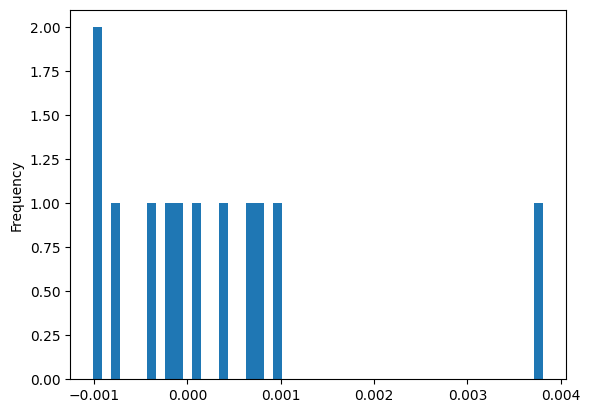

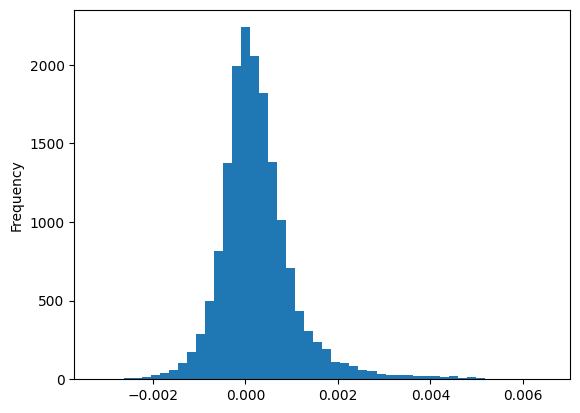

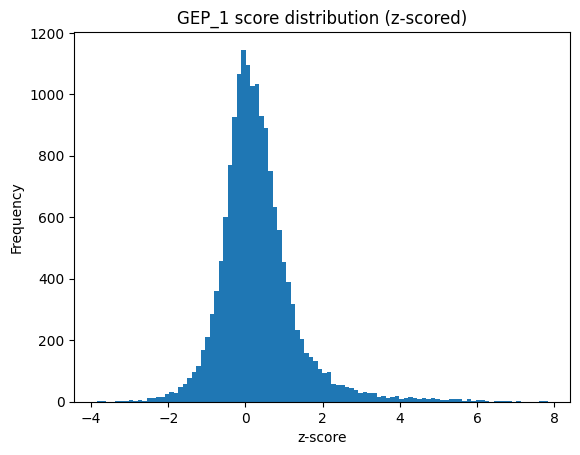

MALAT1 z-score in GEP_1: 4.57
MALAT1 z-score in GEP_2: 4.11
MALAT1 z-score in GEP_3: 3.24
MALAT1 z-score in GEP_4: 0.19
MALAT1 z-score in GEP_5: 0.92
MALAT1 z-score in GEP_6: -2.48
MALAT1 z-score in GEP_7: 1.50
MALAT1 z-score in GEP_8: -2.38
MALAT1 z-score in GEP_9: -0.81
MALAT1 z-score in GEP_10: -3.84
MALAT1 z-score in GEP_11: -0.30
MALAT1 z-score in GEP_12: -5.13


In [ ]:
CHECK_CNMF_DISTRIBUTION = True

if CHECK_CNMF_DISTRIBUTION:
    # score in TPM 
        # highl expressed genes (MALAT1) will domainate and be rpesen tas top onf many GEPs
        # not goof
    df = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.gene_spectra_tpm.k_12.dt_0_05.txt", sep="\t", index_col=0)
    display(df["MALAT1"])

    # spectra score
        # scaled --> ie each gene has been removed the mean (NO std div --> so scores are notcomapre acorss genes)
    df2 = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.gene_spectra_score.k_12.dt_0_05.txt", sep="\t", index_col=0)
    display(df2)
    display(df2["MALAT1"])
    df2["MALAT1"].plot(kind="hist", bins=50); plt.show()
    df2.iloc[0, :].plot(kind="hist", bins=50); plt.show()

    # scorre cspreatc score using std of gene i shtis GEP
        #z > 2 means "this gene is 2 std above the mean in this GEP, AND is already corrected for its baseline expression across all GEPs."
    # row-wise z-score: standardize within each GEP (makes threshold comparable across GEPs)
    # ust dividing by std is sufficient — no need to subtract mean again.

    # ATTENTION: within-GEP std division → good for consistent threshold across GEPs but distorts cross-GEP ranking
    
    row_std = df2.std(axis=1).replace(0, np.nan)
    df2 = df2.divide(row_std, axis=0)  # mean already ~0, just divide by std


    # Distribution of all gene scores within GEP_1 (before and after normalization)
    df2.iloc[0, :].plot(kind="hist", bins=100, title="GEP_1 score distribution (z-scored)")
    plt.xlabel("z-score")
    plt.show()

    # Where does MALAT1 fall in GEP_1?
    for i in df2.index:
        malat1_z = df2.loc[i, "MALAT1"]
        print(f"MALAT1 z-score in GEP_{i}: {malat1_z:.2f}")



# Scatterplot logFC differt methods

In [ ]:
# ── Scatter: logFC(PCA_nebula) vs logFC(baseline_nebula / cNMF_nebula) ───────
# For each regular cell type in the selected tissue, scatter-plot the per-gene
# logFC from two DEG methods so we can see how much the PCA covariates
# move the effect estimates relative to the baseline model (and cNMF if available).

from scipy.stats import pearsonr

TISSUE_SCATTER = TISSUE   # override here if needed, e.g. "Striatum"

BASE_PCA      = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/PCA_nebula"
BASE_BASELINE = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/baseline_nebula"
BASE_CNMF     = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/cNMF_nebula"

def _load_deg(base_folder, ct):
    #\"\"\"Load deg_results.csv for one cell type; returns None if file is missing.\"\"\"
    path = os.path.join(base_folder, ct, "deg_results.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path).dropna(subset=[PVAL_COL, LOGFC_COL])
    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)  # ln → log2

    
    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        df = df[df["logFC_(Intercept)"] >= -20]
    df["_padj"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]
    return df[[GENE_COL, LOGFC_COL, "_padj"]].copy()


def _scatter_comparison(ax, df_x, df_y, label_x, label_y, pval_thr=PVAL_THR, logfc_thr=LOGFC_THR):
    #\"\"\"Scatter logFC(x) vs logFC(y) on ax, coloured by significance.\"\"\"
    merged = df_x.merge(df_y, on=GENE_COL, suffixes=("_x", "_y"))
    if merged.empty:
        ax.text(0.5, 0.5, "no common genes", ha="center", va="center", transform=ax.transAxes)
        return

    sig_x   = merged["_padj_x"] <= pval_thr
    sig_y   = merged["_padj_y"] <= pval_thr
    both    =  sig_x &  sig_y
    only_x  =  sig_x & ~sig_y
    only_y  = ~sig_x &  sig_y
    neither = ~sig_x & ~sig_y

    kw = dict(alpha=0.5, s=8, linewidths=0)
    ax.scatter(merged.loc[neither,  f"{LOGFC_COL}_x"], merged.loc[neither,  f"{LOGFC_COL}_y"], color="lightgrey",  label="not sig",         **kw)
    ax.scatter(merged.loc[only_x,   f"{LOGFC_COL}_x"], merged.loc[only_x,   f"{LOGFC_COL}_y"], color="steelblue",  label=f"sig {label_x}",  **kw)
    ax.scatter(merged.loc[only_y,   f"{LOGFC_COL}_x"], merged.loc[only_y,   f"{LOGFC_COL}_y"], color="darkorange", label=f"sig {label_y}",  **kw)
    ax.scatter(merged.loc[both,     f"{LOGFC_COL}_x"], merged.loc[both,     f"{LOGFC_COL}_y"], color="firebrick",  label="sig both",        **kw)

    # diagonal reference
    lim = max(merged[[f"{LOGFC_COL}_x", f"{LOGFC_COL}_y"]].abs().max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8, ls="--", zorder=0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Pearson r on all genes
    r, p = pearsonr(merged[f"{LOGFC_COL}_x"], merged[f"{LOGFC_COL}_y"])
    ax.set_xlabel(f"logFC  [{label_x}]", fontsize=9)
    ax.set_ylabel(f"logFC  [{label_y}]", fontsize=9)
    ax.text(0.03, 0.97, f"r = {r:.2f}  n = {len(merged)}", transform=ax.transAxes,
            va="top", fontsize=8, color="dimgray")
    ax.legend(fontsize=7, markerscale=2, loc="lower right")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.axvline(0, color="grey", lw=0.5, ls=":")


# ── collect regular cell types from PCA folder ─────────────────────────────
if not os.path.exists(BASE_PCA):
    print(f"ERROR: PCA results not found: {BASE_PCA}")
else:
    cell_types = sorted([
        ct for ct in os.listdir(BASE_PCA)
        if os.path.isdir(os.path.join(BASE_PCA, ct))
        and ct not in ("_summary",)
        and "_by_" not in ct
    ])

    has_cnmf  = os.path.exists(BASE_CNMF)
    n_cols    = 2 if has_cnmf else 1
    n_rows    = len(cell_types)
    fig_h     = max(3.5 * n_rows, 4)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, fig_h),
                             squeeze=False)

    for row, ct in enumerate(cell_types):
        df_pca = _load_deg(BASE_PCA, ct)

        # ── col 0: PCA vs Baseline ──────────────────────────────────────────
        ax0 = axes[row, 0]
        ax0.set_title(f"{ct}  |  PCA vs Baseline", fontsize=9)
        df_base = _load_deg(BASE_BASELINE, ct)
        if df_pca is None or df_base is None:
            ax0.text(0.5, 0.5, "missing results", ha="center", va="center", transform=ax0.transAxes)
        else:
            _scatter_comparison(ax0, df_pca, df_base, "PCA", "Baseline")

        # ── col 1: PCA vs cNMF (optional) ───────────────────────────────────
        if has_cnmf:
            ax1 = axes[row, 1]
            ax1.set_title(f"{ct}  |  PCA vs cNMF", fontsize=9)
            df_cnmf = _load_deg(BASE_CNMF, ct)
            if df_pca is None or df_cnmf is None:
                ax1.text(0.5, 0.5, "missing results", ha="center", va="center", transform=ax1.transAxes)
            else:
                _scatter_comparison(ax1, df_pca, df_cnmf, "PCA", "cNMF")

    fig.suptitle(f"logFC comparison across DEG methods  |  {TISSUE_SCATTER}", fontsize=12, y=1.002)
    plt.tight_layout()
    plt.savefig(
        f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/logFC_method_scatter.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


# ---

In [120]:
import pandas as pd

# 1. Load the data (Fixing the Patch Hallmark typo)
matrix_gsea_reactome = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv")
patch_gsea_reactome = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv")

matrix_gsea_hallmark = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/gsea_on_degs/MSigDB_Hallmark_2020_gsea_all.csv")
patch_gsea_hallmark = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch/gsea_on_degs/MSigDB_Hallmark_2020_gsea_all.csv") # Fixed path

# 2. Add an origin identifier column to every dataset
matrix_gsea_reactome['Cell_Type'] = 'Matrix'
patch_gsea_reactome['Cell_Type'] = 'Patch'
matrix_gsea_hallmark['Cell_Type'] = 'Matrix'
patch_gsea_hallmark['Cell_Type'] = 'Patch'

# 3. Combine them vertically into a single master frame
df_combined = pd.concat([
    matrix_gsea_reactome, 
    patch_gsea_reactome, 
    matrix_gsea_hallmark, 
    patch_gsea_hallmark
], ignore_index=True)

# 4. Reshape the table using pivot to place Matrix and Patch side-by-side
# (Change 'Lead_genes' to whatever your column name is, e.g., 'Genes' or 'Combined_Genes')
df_gsea = df_combined.pivot(index='Term', columns='Cell_Type', values='Lead_genes')

# 5. Clean up columns and index names
df_gsea = df_gsea.rename_axis(None, axis=1).reset_index()
df_gsea = df_gsea.rename(columns={'Matrix': 'Lead_genes_Matrix', 'Patch': 'Lead_genes_Patch'})
df_gsea

,Term,Lead_genes_Matrix,Lead_genes_Patch
0,MSigDB_Hallmark_2020__Adipogenesis,IFNGR1;RIOK3;NDUFA5;GPHN;CD302;G3BP2;BCL2L13;P...,GPHN;IFNGR1;BCL2L13;G3BP2;PHYH;NDUFA5;LIFR;RIO...
1,MSigDB_Hallmark_2020__Allograft Rejection,IFNGR1;MAP3K7;JAK2;HLA-A;STAT4;HDAC9;DYRK3;EIF...,MAP3K7;HLA-A;INHBA;HDAC9;IFNGR2;IFNGR1;STAT4;R...
2,MSigDB_Hallmark_2020__Androgen Response,INPP4B;FKBP5;CCND1;SAT1;DNAJB9;ITGAV;NCOA4;LIF...,ITGAV;PIAS1;LIFR;B4GALT1;ZBTB10;HERC3;MAP7;CCN...
3,MSigDB_Hallmark_2020__Angiogenesis,ITGAV;SLCO2A1;FGFR1;PTK2,ITGAV;JAG1;FGFR1
4,MSigDB_Hallmark_2020__Apical Junction,DLG1;ADAM23;PIK3CB;VCL;JAM3;NLGN2;B4GALT1;LAMC...,PIK3CB;DLG1;ADAM23;SLIT2;B4GALT1;TJP1;ADAM15;V...
...,...,...,...
1204,Reactome_Pathways_2024__tRNA Modification in t...,PUS1;EPRS1;TYW5;ADAT2;NSUN2;DUS2;TRIT1;TRMT5;A...,EPRS1;ADAT2;PUS1;TYW5;NSUN2;PUS7;TRMT9B;TRMT10...
1205,Reactome_Pathways_2024__tRNA Processing,NUP155;NUP58;NUP160;NUP93;DDX1;NUP88;NUP54;TSE...,NUP54;NUP88;EPRS1;NUP205;RPP38;NUP153;NUP58;TP...
1206,Reactome_Pathways_2024__tRNA Processing in the...,MT-ND3;MT-ATP8;MT-ATP6;MT-CO2;MT-CO3;MT-ND1;MT...,ELAC2;MT-ND3;MT-CO2;MT-ATP8;MT-CO3;MT-ND1;MT-N...
1207,Reactome_Pathways_2024__tRNA Processing in the...,NUP155;NUP58;NUP160;NUP93;DDX1;NUP88;NUP54;TSE...,NUP54;NUP88;NUP205;RPP38;NUP153;NUP58;TPR;POP1...


,Name_Matrix,Term,ES_Matrix,NES_Matrix,NOM p-val_Matrix,FDR q-val_Matrix,FWER p-val_Matrix,Tag %_Matrix,Gene %_Matrix,Lead_genes_Matrix,Name_Patch,ES_Patch,NES_Patch,NOM p-val_Patch,FDR q-val_Patch,FWER p-val_Patch,Tag %_Patch,Gene %_Patch,Lead_genes_Patch,Cell_Type
0,prerank,Reactome_Pathways_2024__Defective B3GALTL Caus...,-0.746501,-2.134384,0.000000,0.000842,0.001,11/28,9.77%,ADAMTSL2;THBS1;THSD7B;ADAMTS10;ADAMTS3;ADAMTSL...,prerank,-0.524411,-1.412218,0.082452,1.000000,1.000,9/22,20.77%,THSD7B;ADAMTS10;ADAMTSL2;ADAMTS13;ADAMTS3;THSD...,NaN
1,prerank,Reactome_Pathways_2024__O-glycosylation of TSR...,-0.734852,-2.110016,0.000000,0.001264,0.003,11/29,9.77%,ADAMTSL2;THBS1;THSD7B;ADAMTS10;ADAMTS3;ADAMTSL...,prerank,-0.512225,-1.393624,0.096436,1.000000,1.000,3/23,1.00%,THSD7B;ADAMTS10;ADAMTSL2,NaN
2,prerank,Reactome_Pathways_2024__SUMOylation of RNA Bin...,0.611572,1.883282,0.000000,0.019301,0.107,16/47,9.28%,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;HNRNPC;T...,prerank,0.442143,1.344704,0.071429,0.364685,1.000,14/45,13.96%,NUP54;NUP88;NUP205;NUP153;NUP58;TPR;NOP58;RNF2...,NaN
3,prerank,Reactome_Pathways_2024__SLC Transporter Disorders,0.572733,1.873889,0.001724,0.020078,0.122,19/68,10.63%,NUP155;SLC9A9;NUP58;NUP160;GCK;NUP93;SLC3A1;NU...,prerank,0.482368,1.553280,0.005357,0.189741,0.990,22/61,18.07%,NUP54;NUP88;SLC3A1;NUP205;BSG;SLC11A2;GCK;NUP1...,NaN
4,prerank,Reactome_Pathways_2024__Transport of the SLBP ...,0.654168,1.886759,0.000000,0.020304,0.102,20/35,19.10%,NUP155;NUP58;NUP160;NUP93;NUP88;NUP54;TPR;NUP3...,prerank,0.498786,1.421415,0.047445,0.317449,1.000,15/35,18.07%,NUP54;NUP88;NUP205;NUP153;NUP58;TPR;EIF4E;NUP3...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,prerank,MSigDB_Hallmark_2020__p53 Pathway,0.207814,0.771375,0.975904,1.000000,1.000,54/160,27.45%,HDAC3;ACVR1B;SAT1;CGRRF1;DNTTIP2;ABCC5;CEBPA;P...,prerank,0.228573,0.822287,0.869863,0.860785,1.000,28/138,18.49%,PLK3;ISCU;TM7SF3;ACVR1B;POLH;SAT1;PITPNC1;TP63...,Patch
1150,prerank,MSigDB_Hallmark_2020__Inflammatory Response,0.243649,0.838271,0.783972,1.000000,1.000,11/95,12.64%,CHST2;IFNAR1;ACVR1B;SLC31A1;ITGB8;PTGER2;EIF2A...,prerank,0.372157,1.233061,0.141379,0.431169,0.948,14/77,13.90%,INHBA;IFNAR1;IFNGR2;SLC7A2;ITGB8;CHST2;SLC11A2...,Patch
1151,prerank,MSigDB_Hallmark_2020__Xenobiotic Metabolism,0.202954,0.738676,0.973899,1.000000,1.000,42/135,27.45%,SSR3;SAR1B;MT2A;MARCHF6;ACP1;AKR1C2;ATOH8;SLC3...,prerank,-0.326390,-1.212812,0.094527,0.539694,0.922,17/120,8.24%,ACOX3;PTGDS;ELOVL5;HACL1;PTS;RAP1GAP;DHPS;SLC6...,Patch
1152,prerank,MSigDB_Hallmark_2020__Complement,-0.220293,-0.823985,0.879397,1.000000,1.000,38/132,24.76%,RABIF;L3MBTL4;DYRK2;LYN;PPP4C;LRP1;PRCP;OLR1;C...,prerank,-0.211370,-0.777267,0.950562,1.000000,1.000,27/115,21.63%,RABIF;PHEX;KCNIP3;GPD2;ADAM9;C1S;HPCAL4;L3MBTL...,Patch


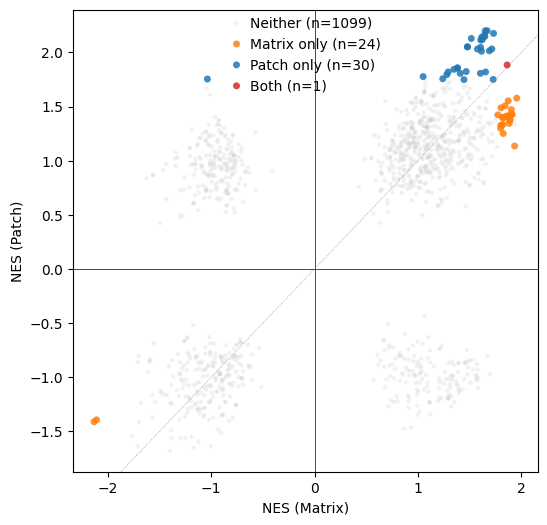

In [127]:
matrix_gsea_reactome = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv")
patch_gsea_reactome = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv")
matrix_gsea_hallmark = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/gsea_on_degs/MSigDB_Hallmark_2020_gsea_all.csv")
matrix_gsea_hallmark = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix/gsea_on_degs/MSigDB_Hallmark_2020_gsea_all.csv")
    
matrix_all = pd.concat([matrix_gsea_reactome, matrix_gsea_hallmark], ignore_index=True)
patch_all  = pd.concat([patch_gsea_reactome,  patch_gsea_hallmark],  ignore_index=True)

df_gsea = pd.merge(matrix_all, patch_all, on="Term", suffixes=("_Matrix", "_Patch"))

display(df_gsea)

def _parse(s):
    return set(g.strip() for g in s.split(";")) if isinstance(s, str) and s else set()
df_gsea["lead_intersection"] = [
    sorted(_parse(m) & _parse(p))
    for m, p in zip(df_gsea["Lead_genes_Matrix"], df_gsea["Lead_genes_Patch"])
]
df_gsea["n_intersection"] = df_gsea["lead_intersection"].str.len()


import numpy as np
import matplotlib.pyplot as plt

sig_M = df_gsea["FDR q-val_Matrix"] < 0.05
sig_P = df_gsea["FDR q-val_Patch"]  < 0.05
df_gsea["sig_class"] = np.select(
    [sig_M & sig_P, sig_M & ~sig_P, ~sig_M & sig_P],
    ["Both", "Matrix only", "Patch only"], default="Neither",
)

palette = {"Neither": "lightgrey", "Matrix only": "tab:orange",
           "Patch only": "tab:blue", "Both": "tab:red"}

fig, ax = plt.subplots(figsize=(6, 6))
for cat in ["Neither", "Matrix only", "Patch only", "Both"]:
    sub = df_gsea[df_gsea["sig_class"] == cat]
    ax.scatter(sub["NES_Matrix"], sub["NES_Patch"],
               c=palette[cat], s=10 if cat == "Neither" else 25,
               alpha=0.3 if cat == "Neither" else 0.85,
               edgecolor="none", label=f"{cat} (n={len(sub)})")

ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.axline((0, 0), slope=1, color="grey", lw=0.5, ls=":")
ax.set_xlabel("NES (Matrix)"); ax.set_ylabel("NES (Patch)")
ax.legend(frameon=False)
plt.show()

In [ ]:
df_gsea[df_gsea["sig_class"] == "Both"][["Term", "Lead_genes_Matrix", "Lead_genes_Patch", "lead_intersection"]]
df_gsea[df_gsea["sig_class"] == "Patch only"][["Term", "Lead_genes_Matrix", "Lead_genes_Patch", "lead_intersection"]]

,Term,Lead_genes_Matrix,Lead_genes_Patch,lead_intersection
10,Reactome_Pathways_2024__Response of Mtb to Pha...,MAPK1;KPNA1;RAB5A;KPNB1;TRIM27;ATP6V1H;ENO1;PG...,MAPK1;ATP6V1H;KPNB1;HGS;RAB5A;PGK1;MAPK3;ENO1;...,"[ATP6V1H, ENO1, HGS, KPNA1, KPNB1, MAPK1, PGK1..."


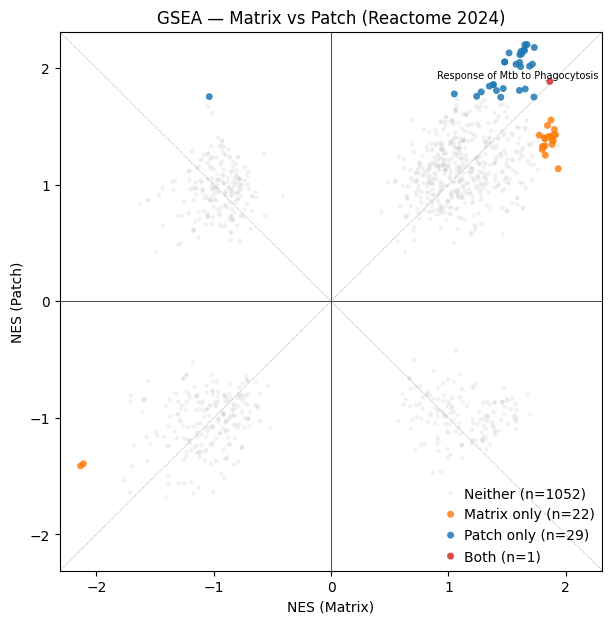

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

palette = {"Neither": "lightgrey", "Matrix only": "tab:orange",
           "Patch only":  "tab:blue",  "Both":        "tab:red"}

fig, ax = plt.subplots(figsize=(7, 7))
for cat in ["Neither", "Matrix only", "Patch only", "Both"]:  # draw "Both" last
    sub = df_gsea[df_gsea["sig_class"] == cat]
    ax.scatter(sub["NES_Matrix"], sub["NES_Patch"],
               c=palette[cat],
               s=10 if cat == "Neither" else 25,
               alpha=0.3 if cat == "Neither" else 0.85,
               edgecolor="none",
               label=f"{cat} (n={len(sub)})")

# reference lines
ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
lim = np.nanmax(np.abs(df_gsea[["NES_Matrix", "NES_Patch"]].values)) * 1.05
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axline((0, 0), slope=1,  color="grey", lw=0.5, ls=":")   # y = x (concordant)
ax.axline((0, 0), slope=-1, color="grey", lw=0.5, ls=":")   # y = -x (anti)

# label top discordant + top concordant pathways
both = df_gsea[df_gsea["sig_class"] == "Both"].copy()
both["concord"]   = both["NES_Matrix"] * both["NES_Patch"]               # same sign → positive
both["discord_d"] = (both["NES_Matrix"] - both["NES_Patch"]).abs()       # distance from diagonal

to_label = pd.concat([
    both.nlargest(5,   "concord"),     # most concordant
    both.nsmallest(5,  "concord"),     # most anti-concordant
    both.nlargest(5,   "discord_d"),   # furthest from y=x
]).drop_duplicates("Term")

texts = [ax.text(r["NES_Matrix"], r["NES_Patch"],
                 r["Term"].replace("Reactome_Pathways_2024__", "")[:40],
                 fontsize=7) for _, r in to_label.iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))

ax.set_xlabel("NES (Matrix)"); ax.set_ylabel("NES (Patch)")
ax.set_title("GSEA — Matrix vs Patch (Reactome 2024)")
ax.legend(frameon=False, loc="best")

# ---

In [131]:
_all_results

[('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Matrix',
  'Matrix'),
 ('/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Patch',
  'Patch')]

In [153]:
df_list = []
for ct in df_da["cell_type"].unique():
    if not os.path.exists(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/{TYPE_DEG}/{ct}/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv"):
        continue
    gsea_reactome = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/{TYPE_DEG}/{ct}/gsea_on_degs/Reactome_Pathways_2024_gsea_all.csv")
    gsea_hallmark = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/{TYPE_DEG}/{ct}/gsea_on_degs/MSigDB_Hallmark_2020_gsea_all.csv")
    df_ct = pd.concat([gsea_reactome, gsea_hallmark], ignore_index=True)
    df_ct["Cell_Type"] = ct
    df_list.append(df_ct)

df_long = pd.concat(df_list, ignore_index=True)

# Wide format: one row per pathway, one column per (metric, cell type)
df_wide = df_long.pivot_table(index="Term", columns="Cell_Type",
                              values=["NES", "FDR q-val"])
df_wide.columns = [f"{m}__{ct}" for m, ct in df_wide.columns]
df_wide = df_wide.reset_index()
display(df_wide)

,Term,FDR q-val__Astrocyte,FDR q-val__Ependymal,FDR q-val__Matrix,FDR q-val__Microglia,FDR q-val__OPC,FDR q-val__Oligodendrocyte,FDR q-val__Patch,FDR q-val__eMSN_D1D2,FDR q-val__eMSN_NUDAP,...,NES__Astrocyte,NES__Ependymal,NES__Matrix,NES__Microglia,NES__OPC,NES__Oligodendrocyte,NES__Patch,NES__eMSN_D1D2,NES__eMSN_NUDAP,NES__eMSN_StrioMat
0,MSigDB_Hallmark_2020__Adipogenesis,0.147533,0.169364,0.400125,0.689003,0.922228,0.307517,0.444032,1.000000,0.786392,...,1.417595,1.370687,1.233580,1.059672,0.863895,1.158522,1.113213,0.742173,1.032827,1.101150
1,MSigDB_Hallmark_2020__Allograft Rejection,0.252837,0.258705,0.280287,0.768501,0.132992,0.000964,0.010257,1.000000,0.956896,...,1.252507,1.282416,1.292952,0.998576,1.498075,1.859209,1.820083,1.106008,0.890943,1.218057
2,MSigDB_Hallmark_2020__Androgen Response,0.169351,0.176501,0.391264,0.772952,0.651041,0.020482,0.493179,1.000000,0.845139,...,1.418760,1.357386,1.221665,1.307690,1.131802,1.637962,1.121258,0.814668,1.080702,0.889661
3,MSigDB_Hallmark_2020__Angiogenesis,0.252484,0.984319,0.991543,0.758162,0.342507,0.088266,0.676657,0.991685,0.925029,...,1.275679,0.604446,0.640504,0.912253,1.396848,1.453438,0.947293,0.714769,1.268111,0.779939
4,MSigDB_Hallmark_2020__Apical Junction,0.406494,0.328393,1.000000,0.847899,0.989036,0.917708,0.454799,1.000000,0.896520,...,1.117150,1.218650,0.779395,-0.831732,0.889734,-0.842521,1.069671,1.177109,0.955950,1.346895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,Reactome_Pathways_2024__tRNA Modification in t...,0.939182,0.887578,0.976241,0.977636,1.000000,0.818420,0.800404,0.995885,1.000000,...,0.787377,1.411933,0.726408,0.771904,1.238550,0.915698,0.910626,0.988842,1.235726,0.748048
1934,Reactome_Pathways_2024__tRNA Processing,0.929018,0.952600,0.100414,0.961462,0.985512,0.817089,0.468916,1.000000,1.000000,...,0.841044,1.281832,1.637110,-0.809806,1.099978,0.920824,1.241499,0.896393,0.976798,1.323554
1935,Reactome_Pathways_2024__tRNA Processing in the...,0.650987,NaN,0.609128,0.858624,1.000000,0.708497,0.973731,NaN,NaN,...,1.216445,NaN,1.087040,1.076675,0.451488,1.099589,0.717250,NaN,NaN,NaN
1936,Reactome_Pathways_2024__tRNA Processing in the...,1.000000,0.926843,0.053016,0.881923,0.972082,0.926679,0.370808,1.000000,1.000000,...,0.611269,1.048863,1.938166,-1.046048,0.833029,0.739086,1.336670,0.652947,0.797371,1.478250


In [149]:
df_da = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/ct_for_deg/crumblr_results.csv")
df_da

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient
0,0.222444,-1.166324,0.779713,4.395956e-01,5.810564e-01,-6.703352,-TAFA1,conditionXDP
1,0.489449,2.512049,3.179290,2.655766e-03,1.195095e-02,-2.132873,Astrocyte,conditionXDP
2,-0.115306,-1.617089,-0.604102,5.487755e-01,5.810564e-01,-6.696745,COP,conditionXDP
3,0.189262,-1.178732,0.964636,3.398250e-01,5.560772e-01,-6.409240,Endothelial_BBB,conditionXDP
4,1.038821,-0.795403,3.449348,1.222128e-03,7.332770e-03,-1.623144,Ependymal,conditionXDP
5,0.367658,-2.316411,1.783643,8.115045e-02,1.825885e-01,-5.193599,Fibroblasts,conditionXDP
6,0.178418,-2.127732,0.680652,4.995403e-01,5.810564e-01,-6.766365,Lymphocyte,conditionXDP
7,0.428159,-1.067647,3.014704,4.195892e-03,1.510521e-02,-2.658223,Macrophages,conditionXDP
8,-1.368188,2.068004,-6.962456,1.094344e-08,1.969819e-07,9.708527,Matrix,conditionXDP
9,-0.171726,1.452964,-1.085643,2.833542e-01,5.100376e-01,-6.129327,Microglia,conditionXDP


In [147]:
for pathway in df_wide["Term"].unique():

    display(df_wide[df_wide["Term"] == pathway])

    break

,Term,FDR q-val__Matrix,FDR q-val__Patch,NES__Matrix,NES__Patch
0,MSigDB_Hallmark_2020__Adipogenesis,0.400125,0.444032,1.23358,1.113213


In [ ]:
from scipy.stats import pearsonr, spearmanr

# 1) DA logFC indexed by cell type (assumes the DA dataframe is `df_da`)
da = df_da.set_index("cell_type")["logFC"]

# 2) Identify NES columns and their cell-type labels
nes_cols = [c for c in df_wide.columns if c.startswith("NES__")]
cts      = pd.Index([c.replace("NES__", "") for c in nes_cols])

# 3) Intersect with cell types in the DA table
common = cts.intersection(da.index)
print(f"Using {len(common)} cell types: {list(common)}")
da_vec = da.loc[common].values

# 4) Per-pathway correlation
def _corr(row):
    nes = np.array([row[f"NES__{ct}"] for ct in common], dtype=float)
    m   = ~np.isnan(nes)
    if m.sum() < 3:
        return pd.Series(dict(n=m.sum(), r=np.nan, p_pearson=np.nan,
                              rho=np.nan, p_spearman=np.nan))
    r,  pp = pearsonr(nes[m], da_vec[m])
    rh, ps = spearmanr(nes[m], da_vec[m])
    return pd.Series(dict(n=m.sum(), r=r, p_pearson=pp, rho=rh, p_spearman=ps))

df_corr = df_wide.apply(_corr, axis=1).assign(Term=df_wide["Term"].values)
df_corr = df_corr[["Term", "n", "r", "p_pearson", "rho", "p_spearman"]]
df_corr = df_corr.sort_values("p_pearson")
display(df_corr.head(30))


Using 10 cell types: ['Astrocyte', 'Ependymal', 'Matrix', 'Microglia', 'OPC', 'Oligodendrocyte', 'Patch', 'eMSN_D1D2', 'eMSN_NUDAP', 'eMSN_StrioMat']


,Term,n,r,p_pearson,rho,p_spearman
10,MSigDB_Hallmark_2020__Complement,10.0,0.867312,0.001152,0.733333,0.015801
918,Reactome_Pathways_2024__Metabolism of Folate a...,8.0,-0.911740,0.001607,-0.785714,0.020815
363,Reactome_Pathways_2024__Cytosolic Iron-Sulfur ...,7.0,0.937561,0.001809,0.714286,0.071344
1535,Reactome_Pathways_2024__Selenoamino Acid Metab...,10.0,-0.843132,0.002182,-0.878788,0.000814
139,Reactome_Pathways_2024__Aflatoxin Activation a...,4.0,-0.997365,0.002635,-1.000000,0.000000
1526,Reactome_Pathways_2024__SUMOylation of RNA Bin...,10.0,-0.832620,0.002791,-0.624242,0.053718
518,Reactome_Pathways_2024__Erythropoietin Activat...,7.0,-0.921792,0.003149,-0.428571,0.337368
1762,Reactome_Pathways_2024__Telomere Maintenance,10.0,0.821788,0.003537,0.624242,0.053718
1606,Reactome_Pathways_2024__Signaling by LTK in Ca...,7.0,-0.917905,0.003547,-0.571429,0.180202
1520,Reactome_Pathways_2024__SUMOylation of Chromat...,10.0,-0.818267,0.003808,-0.612121,0.059972


<Axes: xlabel='rho', ylabel='Count'>

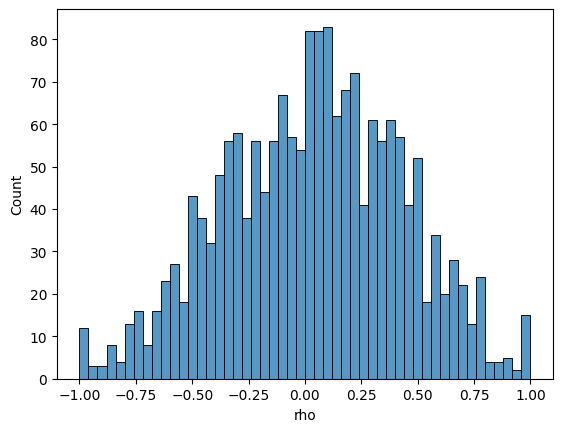

In [156]:
sns.histplot(df_corr["rho"], bins=50)